In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
jjm_df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Jal Jeevan.xlsx")

In [ ]:
jjm_df.columns

Index(['District Name', 'No. of block', 'No. of panchayats', 'No. of villages',
       'Reported_No. of Har Ghar Jal Blocks',
       'Certified_No. of Har Ghar Jal Blocks',
       'Reported_No. of Har Ghar Jal Panchayat',
       'Certified_No. of Har Ghar Jal Panchayat',
       'Reported_No. of Har Ghar Jal Village',
       'Certified_No. of Har Ghar Jal Village'],
      dtype='object')

In [ ]:
# Standardising column names

jjm_df = jjm_df.rename(columns={
    'District Name': 'district_name',
    'No. of block': 'num_blocks',
    'No. of panchayats': 'num_panchayats',
    'No. of villages': 'num_villages',

    'Reported_No. of Har Ghar Jal Blocks': 'reported_hgj_blocks',
    'Certified_No. of Har Ghar Jal Blocks': 'certified_hgj_blocks',

    'Reported_No. of Har Ghar Jal Panchayat': 'reported_hgj_panchayats',
    'Certified_No. of Har Ghar Jal Panchayat': 'certified_hgj_panchayats',

    'Reported_No. of Har Ghar Jal Village': 'reported_hgj_villages',
    'Certified_No. of Har Ghar Jal Village': 'certified_hgj_villages'
})

COVERAGE RATIOS (how much of blocks / panchayats / villages in a district have become "Har Ghar Jal")

These are the core WATER ACCESS indicators we will later use in the Water/Infrastructure sub-index (W-Index).
============================================================

Helper function to safely divide and avoid division-by-zero

In [ ]:

def safe_div(numerator, denominator):
    return np.where(
        denominator > 0,
        numerator / denominator,
        np.nan
    )

**COVERAGE RATIOS**

How much of blocks / panchayats / villages in a district have become Har Ghar Jal (reported and certified).

These will later go into the WATER / INFRA sub-index.

In [ ]:
# ----- BLOCK-LEVEL COVERAGE -----
# proportion of blocks reported as Har Ghar Jal

jjm_df['block_coverage_reported'] = safe_div(
    jjm_df['reported_hgj_blocks'], jjm_df['num_blocks']
)

# proportion of blocks certified as Har Ghar Jal

jjm_df['block_coverage_certified'] = safe_div(
    jjm_df['certified_hgj_blocks'], jjm_df['num_blocks']
)

In [ ]:
# ----- PANCHAYAT-LEVEL COVERAGE -----
jjm_df['panchayat_coverage_reported'] = safe_div(
    jjm_df['reported_hgj_panchayats'], jjm_df['num_panchayats']
)

jjm_df['panchayat_coverage_certified'] = safe_div(
    jjm_df['certified_hgj_panchayats'], jjm_df['num_panchayats']
)

In [ ]:
# ----- VILLAGE-LEVEL COVERAGE -----
jjm_df['village_coverage_reported'] = safe_div(
    jjm_df['reported_hgj_villages'], jjm_df['num_villages']
)

jjm_df['village_coverage_certified'] = safe_div(
    jjm_df['certified_hgj_villages'], jjm_df['num_villages']
)

**GOVERNANCE / VERIFICATION RATIOS**

How much of the reported coverage is actually certified.

In [ ]:
jjm_df['block_verification_ratio'] = safe_div(
    jjm_df['certified_hgj_blocks'], jjm_df['reported_hgj_blocks']
)

jjm_df['panchayat_verification_ratio'] = safe_div(
    jjm_df['certified_hgj_panchayats'], jjm_df['reported_hgj_panchayats']
)

jjm_df['village_verification_ratio'] = safe_div(
    jjm_df['certified_hgj_villages'], jjm_df['reported_hgj_villages']
)

**AGGREGATED WATER ACCESS & VERIFICATION SCORES**

Combine block/panchayat/village into district-level means.
These are the main variables we will normalize later:
- certified_water_coverage_mean → Water Access Score
- water_verification_mean → Governance Score (water)

In [ ]:
# Average reported coverage across all three levels
jjm_df['reported_water_coverage_mean'] = jjm_df[
    ['block_coverage_reported',
     'panchayat_coverage_reported',
     'village_coverage_reported']
].mean(axis=1)

# Average certified coverage across all three levels
jjm_df['certified_water_coverage_mean'] = jjm_df[
    ['block_coverage_certified',
     'panchayat_coverage_certified',
     'village_coverage_certified']
].mean(axis=1)

# Average verification ratio across levels
jjm_df['water_verification_mean'] = jjm_df[
    ['block_verification_ratio',
     'panchayat_verification_ratio',
     'village_verification_ratio']
].mean(axis=1)

In [ ]:
jjm_df[['district_name',
        'reported_water_coverage_mean',
        'certified_water_coverage_mean',
        'water_verification_mean']].head()

,district_name,reported_water_coverage_mean,certified_water_coverage_mean,water_verification_mean
0,ALLURI SITHARAMA RAJU,0.076084,0.000000,0.000000
1,ANAKAPALLI,0.023221,0.003025,0.127789
2,ANANTHAPURAMU,0.122435,0.040134,0.323610
3,ANNAMAYYA,0.186861,0.100002,0.549860
4,BAPATLA,0.045607,0.017616,0.431548


**JJM COMPOSITE WATER SCORE (W-Index)**


In [ ]:
# NORMALIZATION (MIN-MAX SCALING)
def min_max(series):
    return (series - series.min()) / (series.max() - series.min())

# Normalize certified coverage
jjm_df['certified_coverage_norm'] = min_max(jjm_df['certified_water_coverage_mean'])

# Normalize verification quality
jjm_df['verification_norm'] = min_max(jjm_df['water_verification_mean'])

**W-INDEX (COMPOSITE WATER ACCESS SCORE)**

Weighted combination:
- 70% weight for certified coverage
- 30% weight for verification score

Justification: access coverage is more important than verification.

In [ ]:
jjm_df['W_Index'] = (
    0.7 * jjm_df['certified_coverage_norm'] +
    0.3 * jjm_df['verification_norm']
)

In [ ]:
# RANK DISTRICTS BASED ON W-INDEX

jjm_df['W_Rank'] = jjm_df['W_Index'].rank(method='dense', ascending=False)

In [ ]:
jjm_df[['district_name',
        'certified_water_coverage_mean',
        'water_verification_mean',
        'certified_coverage_norm',
        'verification_norm',
        'W_Index',
        'W_Rank'
       ]].head()

,district_name,certified_water_coverage_mean,water_verification_mean,certified_coverage_norm,verification_norm,W_Index,W_Rank
0,ALLURI SITHARAMA RAJU,0.000000,0.000000,0.000000,0.000000,0.000000,537.0
1,ANAKAPALLI,0.003025,0.127789,0.001872,0.121704,0.037821,438.0
2,ANANTHAPURAMU,0.040134,0.323610,0.024833,0.308200,0.109843,303.0
3,ANNAMAYYA,0.100002,0.549860,0.061876,0.523676,0.200416,185.0
4,BAPATLA,0.017616,0.431548,0.010900,0.410998,0.130929,269.0


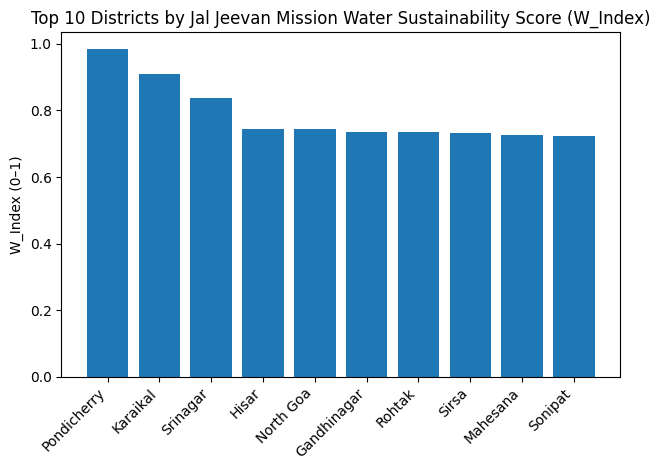

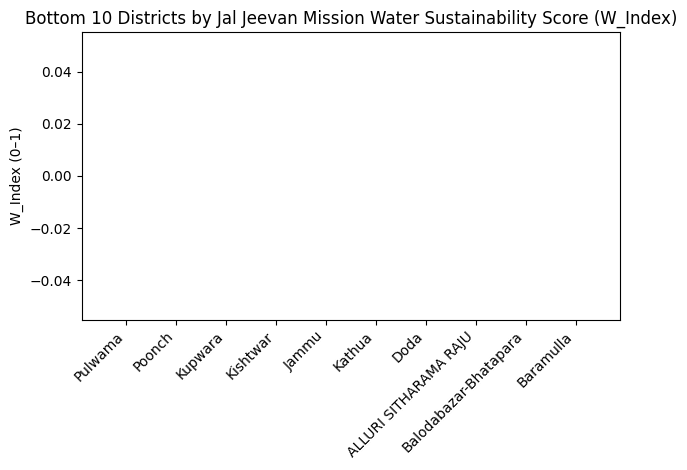

In [ ]:
# W_Index and take top 10
top10_jjm = jjm_df.sort_values('W_Index', ascending=False).head(10)

plt.figure()
plt.bar(top10_jjm['district_name'], top10_jjm['W_Index'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('W_Index (0–1)')
plt.title('Top 10 Districts by Jal Jeevan Mission Water Sustainability Score (W_Index)')
plt.tight_layout()
plt.show()

# Bottom 10 Districts
bottom10_jjm = jjm_df.sort_values('W_Index', ascending=True).head(10)

plt.figure()
plt.bar(bottom10_jjm['district_name'], bottom10_jjm['W_Index'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('W_Index (0–1)')
plt.title('Bottom 10 Districts by Jal Jeevan Mission Water Sustainability Score (W_Index)')
plt.tight_layout()
plt.show()


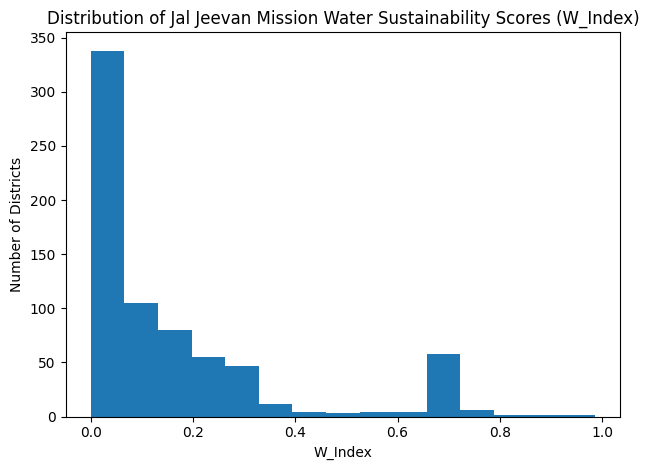

In [ ]:
#W_Index (Overall Performance Spread)
plt.figure()
plt.hist(jjm_df['W_Index'], bins=15)
plt.xlabel('W_Index')
plt.ylabel('Number of Districts')
plt.title('Distribution of Jal Jeevan Mission Water Sustainability Scores (W_Index)')
plt.tight_layout()
plt.show()

# ***District Wise School Data***

In [ ]:
school_df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/District-wise Schools Data.xlsx")

In [ ]:
school_df = school_df.rename(columns={
    'DISTRICT_NAME': 'district_name',
    'SCHOOLS_WITH_LIBRARY_FACILITY': 'schools_with_library',
    'SCHOOLS_WITHOUT_LIBRARY_FACILITY': 'schools_without_library',
    'SCHOOLS_WITH_HANDWASH_FACILITY': 'schools_with_handwash',
    'SCHOOLS_WITHOUT_HANDWASH_FACILITY': 'schools_without_handwash',
    'SCHOOLS_WITH_DRINKING_WATER_FACILITY': 'schools_with_drinking',
    'SCHOOLS_WITHOUT_DRINKING_WATER_FACILITY': 'schools_without_drinking',
    'SCHOOLS_WITH_ELECTRICITY_FACILITY': 'schools_with_electricity',
    'SCHOOLS_WITHOUT_ELECTRICITY_FACILITY': 'schools_without_electricity',
    'SCHOOLS_NOT_FUNCTIONAL_ELECTRICITY_FACILITY': 'schools_electricity_not_functional',
    'SCHOOLS_WITH_PLAYGROUND_FACILITY': 'schools_with_playground',
    'SCHOOLS_WITHOUT_PLAYGROUND_FACILITY': 'schools_without_playground',
    'SCHOOLS_WITH_RAMPS_FACILITY': 'schools_with_ramps',
    'SCHOOLS_WITHOUT_RAMPS_FACILITY': 'schools_without_ramps',
    'SCHOOLS_WITH_ECO_CLUB_FACILITY': 'schools_with_eco_club',
    'SCHOOLS_WITHOUT_ECO_CLUB_FACILITY': 'schools_without_eco_club',
    'SCHOOLS_WITH_YOUTH_CLUB_FACILITY': 'schools_with_youth_club',
    'SCHOOLS_WITHOUT_YOUTH_CLUB_FACILITY': 'schools_without_youth_club',
    'SCHOOLS_WITH_ICT_LAB': 'schools_with_ict',
    'SCHOOLS_WITHOUT_ICT_LAB': 'schools_without_ict',
    'ICT_LAB_NOT_APPLICABLE': 'ict_not_applicable',
    'SCHOOLS_WITH_DIGITAL_LIBRARY': 'schools_with_digilib',
    'SCHOOLS_WITHOUT_DIGITAL_LIBRARY': 'schools_without_digilib',
    'DIGITAL_LIBRARY_NOT_APPLICABLE': 'digilib_not_applicable',
    'SCHOOLS_WITH_COMPUTER_FACILITY': 'schools_with_computer',
    'SCHOOLS_WITHOUT_COMPUTER_FACILITY': 'schools_without_computer',
    'SCHOOLS_WITH_INTERNET_FACILITY': 'schools_with_internet',
    'SCHOOLS_WITHOUT_INTERNET_FACILITY': 'schools_without_internet',
    'TOTAL_SCHOOLS_WITH_SCIENCE_LAB': 'schools_with_science_lab',
    'TOTAL_SCHOOLS_WITHOUT_SCIENCE_LAB': 'schools_without_science_lab',
    'SCIENCE_LAB_NOT_APPLICABLE': 'science_lab_not_applicable',
    'TOTAL_TEACHERS': 'total_teachers',
    'TOTAL_FEMALE_TEACHERS': 'total_female_teachers',
    'TOTAL_BOYS': 'total_boys',
    'TOTAL_GIRLS': 'total_girls',
    'TOTAL_COED_SCHOOL': 'total_coed_schools',
    'TOTAL_BOYS_SCHOOL': 'total_boys_schools',
    'TOTAL_GIRLS_SCHOOL': 'total_girls_schools'
})

In [ ]:
def safe_div(num, den):
    num = num.astype(float)
    den = den.astype(float)
    return np.where(den > 0, num / den, np.nan)

**FACILITY COVERAGE RATIOS (0-1)**

HIGHER = BETTER

For each facility, we computed coverage =
schools_with_facility / (with + without [+ not_applicable if relevant])

In [ ]:
# Library coverage
library_den = school_df['schools_with_library'] + school_df['schools_without_library']
school_df['library_coverage'] = safe_div(school_df['schools_with_library'], library_den)

# Handwash coverage
handwash_den = school_df['schools_with_handwash'] + school_df['schools_without_handwash']
school_df['handwash_coverage'] = safe_div(school_df['schools_with_handwash'], handwash_den)

# Drinking water coverage
drink_den = school_df['schools_with_drinking'] + school_df['schools_without_drinking']
school_df['drinking_water_coverage'] = safe_div(school_df['schools_with_drinking'], drink_den)

# Electricity coverage (including not functional in denominator)
elec_den = (
    school_df['schools_with_electricity'] +
    school_df['schools_without_electricity'] +
    school_df['schools_electricity_not_functional']
)
school_df['electricity_coverage'] = safe_div(school_df['schools_with_electricity'], elec_den)

# Playground coverage
play_den = school_df['schools_with_playground'] + school_df['schools_without_playground']
school_df['playground_coverage'] = safe_div(school_df['schools_with_playground'], play_den)

# Ramps (CWSN accessibility) coverage
ramps_den = school_df['schools_with_ramps'] + school_df['schools_without_ramps']
school_df['ramps_coverage'] = safe_div(school_df['schools_with_ramps'], ramps_den)

# Eco club coverage
eco_den = school_df['schools_with_eco_club'] + school_df['schools_without_eco_club']
school_df['eco_club_coverage'] = safe_div(school_df['schools_with_eco_club'], eco_den)

# Youth club coverage
youth_den = school_df['schools_with_youth_club'] + school_df['schools_without_youth_club']
school_df['youth_club_coverage'] = safe_div(school_df['schools_with_youth_club'], youth_den)

# ICT lab coverage (ignore 'not applicable' in denominator here)
ict_den = school_df['schools_with_ict'] + school_df['schools_without_ict']
school_df['ict_coverage'] = safe_div(school_df['schools_with_ict'], ict_den)

# Digital library coverage
digilib_den = school_df['schools_with_digilib'] + school_df['schools_without_digilib']
school_df['digilib_coverage'] = safe_div(school_df['schools_with_digilib'], digilib_den)

# Computer facility coverage
comp_den = school_df['schools_with_computer'] + school_df['schools_without_computer']
school_df['computer_coverage'] = safe_div(school_df['schools_with_computer'], comp_den)

# Internet coverage
internet_den = school_df['schools_with_internet'] + school_df['schools_without_internet']
school_df['internet_coverage'] = safe_div(school_df['schools_with_internet'], internet_den)

# Science lab coverage
scilab_den = (
    school_df['schools_with_science_lab'] +
    school_df['schools_without_science_lab']
)
school_df['science_lab_coverage'] = safe_div(school_df['schools_with_science_lab'], scilab_den)

In [ ]:
# Total students
school_df['total_students'] = school_df['total_boys'] + school_df['total_girls']

# Student–teacher ratio (higher = worse, will invert later)
school_df['student_teacher_ratio'] = safe_div(
    school_df['total_students'], school_df['total_teachers']
)

# Share of female teachers (higher = better)
school_df['female_teacher_share'] = safe_div(
    school_df['total_female_teachers'], school_df['total_teachers']
)

# Share of co-ed schools (as a simple inclusiveness proxy)
coed_den = (
    school_df['total_coed_schools'] +
    school_df['total_boys_schools'] +
    school_df['total_girls_schools']
)
school_df['coed_share'] = safe_div(
    school_df['total_coed_schools'], coed_den
)


**NORMALIZATION (MIN-MAX) FOR USE IN EDUCATION INDEX**

- For coverage & share variables: higher is better → direct min-max
- For student_teacher_ratio: lower is better → inverted min-max

In [ ]:
def min_max(series):
    series = series.astype(float)
    return (series - series.min()) / (series.max() - series.min())


In [ ]:
# List of "good when high" metrics
good_metrics = [
    'library_coverage',
    'handwash_coverage',
    'drinking_water_coverage',
    'electricity_coverage',
    'playground_coverage',
    'ramps_coverage',
    'eco_club_coverage',
    'youth_club_coverage',
    'ict_coverage',
    'digilib_coverage',
    'computer_coverage',
    'internet_coverage',
    'science_lab_coverage',
    'female_teacher_share',
    'coed_share'
]

In [ ]:
for col in good_metrics:
    norm_col = col + '_norm'
    school_df[norm_col] = min_max(school_df[col])

# For student–teacher ratio (lower is better)
str_norm_raw = min_max(school_df['student_teacher_ratio'])
school_df['student_teacher_ratio_norm'] = 1 - str_norm_raw
# (Now higher = better: more favourable student–teacher ratio)

EDUCATION / SCHOOL INFRASTRUCTURE INDEX (**Edu_Index**)
- infra_subscore: average of facility coverages
- human_subscore: female teachers, coed share, student–teacher ratio
- Edu_Index: weighted combo (60% infra, 40% human)

In [ ]:
infra_norm_cols = [
    'library_coverage_norm',
    'handwash_coverage_norm',
    'drinking_water_coverage_norm',
    'electricity_coverage_norm',
    'playground_coverage_norm',
    'ramps_coverage_norm',
    'eco_club_coverage_norm',
    'youth_club_coverage_norm',
    'ict_coverage_norm',
    'digilib_coverage_norm',
    'computer_coverage_norm',
    'internet_coverage_norm',
    'science_lab_coverage_norm'
]

human_norm_cols = [
    'female_teacher_share_norm',
    'coed_share_norm',
    'student_teacher_ratio_norm'
]

school_df['Edu_infra_subscore'] = school_df[infra_norm_cols].mean(axis=1)
school_df['Edu_human_subscore'] = school_df[human_norm_cols].mean(axis=1)

school_df['Edu_Index'] = (
    0.6 * school_df['Edu_infra_subscore'] +
    0.4 * school_df['Edu_human_subscore']
)

# Rank districts by Edu_Index (1 = best)
school_df['Edu_Rank'] = school_df['Edu_Index'].rank(method='dense', ascending=False)

# Quick preview
school_df[['district_name',
           'Edu_infra_subscore',
           'Edu_human_subscore',
           'Edu_Index',
           'Edu_Rank']].head()

,district_name,Edu_infra_subscore,Edu_human_subscore,Edu_Index,Edu_Rank
0,ANDAMANS,0.877289,0.814591,0.852210,39.0
1,MIDDLE AND NORTH ANDAMANS,0.884615,0.853033,0.871982,14.0
2,NICOBARS,0.756410,0.874622,0.803695,136.0
3,ANAKAPALLI,0.881319,0.685153,0.802852,138.0
4,ANANTAPUR,0.817521,0.634754,0.744414,359.0


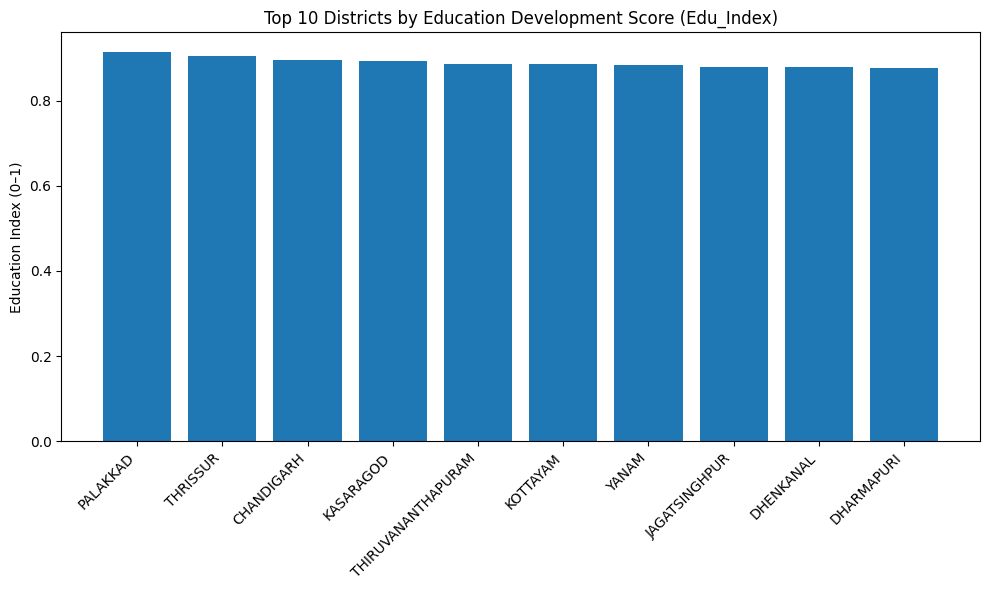

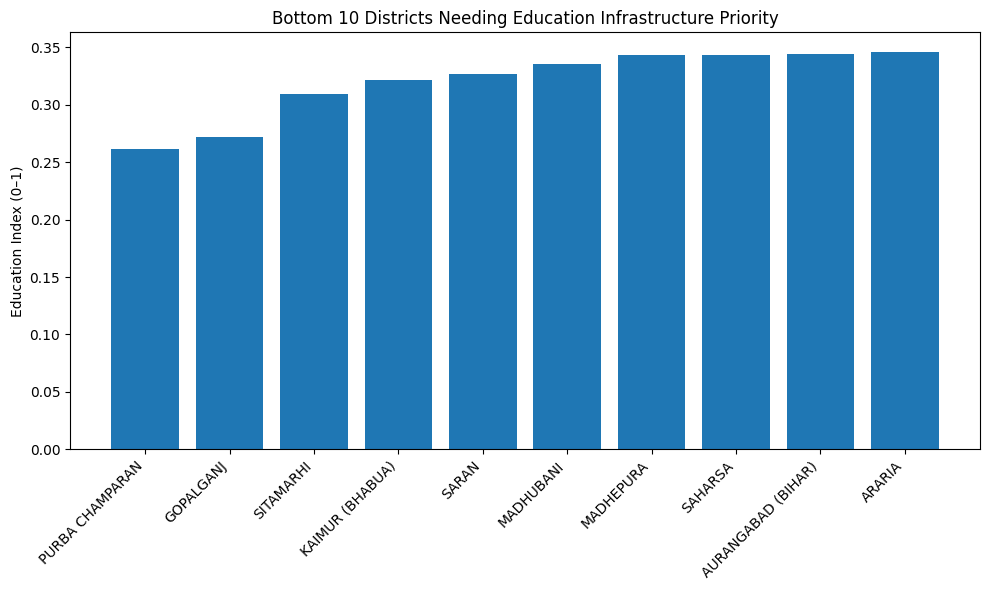

In [ ]:
# Top 10 districts by education index
top10_edu = school_df.sort_values('Edu_Index', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_edu['district_name'], top10_edu['Edu_Index'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Education Index (0–1)')
plt.title('Top 10 Districts by Education Development Score (Edu_Index)')
plt.tight_layout()
plt.show()

# Bottom 10 Districts – Priority Intervention
bottom10_edu = school_df.sort_values('Edu_Index', ascending=True).head(10)

plt.figure(figsize=(10,6))
plt.bar(bottom10_edu['district_name'], bottom10_edu['Edu_Index'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Education Index (0–1)')
plt.title('Bottom 10 Districts Needing Education Infrastructure Priority')
plt.tight_layout()
plt.show()

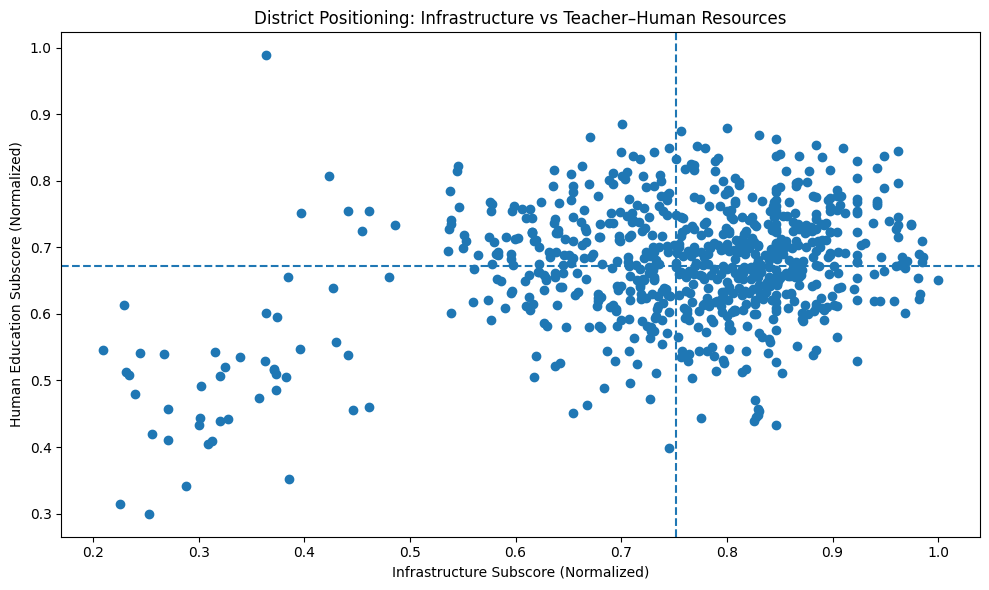

In [ ]:
# Infrastructure vs Teacher Quality – Quadrant Analysis
plt.figure(figsize=(10,6))
plt.scatter(school_df['Edu_infra_subscore'], school_df['Edu_human_subscore'])

plt.xlabel('Infrastructure Subscore (Normalized)')
plt.ylabel('Human Education Subscore (Normalized)')
plt.title('District Positioning: Infrastructure vs Teacher–Human Resources')

# Add quadrant reference lines
plt.axvline(school_df['Edu_infra_subscore'].mean(), linestyle='--')
plt.axhline(school_df['Edu_human_subscore'].mean(), linestyle='--')

plt.tight_layout()
plt.show()

# ***MGNREGA***

In [ ]:
mgnre_df = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/MGNREGA.xlsx")

In [ ]:
mgnre_df = mgnre_df.rename(columns={
    'District Name': 'district_name',
    'Total Households Worked': 'households_worked',
    'Persondays Of Central Liability So Far': 'total_persondays',
    'Women Persondays': 'women_persondays',
    'SC Persondays': 'sc_persondays',
    'ST Persondays': 'st_persondays',
    'Total Individuals Worked': 'individuals_worked',
    'Total No Of HHs Completed 100 Days Of Wage Employment': 'households_100days',
    'Average Wage Rate Per Day Per Person': 'wage_rate',
    'Average Days Of Employment Provided Per Household': 'avg_days_per_household',
    'Number Of Completed Works': 'completed_works',
    'Total No Of Works Takenup': 'total_works',
    'Percentage Payments Gererated Within 15 Days': 'payment_15days'
})


In [ ]:
def safe_div(num, den):
    num = num.astype(float)
    den = den.astype(float)
    return np.where(den > 0, num / den, np.nan)


**DERIVED LIVELIHOOD METRICS**

In [ ]:
# Employment persondays generated per household
mgnre_df['employment_per_household'] = safe_div(
    mgnre_df['total_persondays'], mgnre_df['households_worked']
)

# Share of employment going to women
mgnre_df['women_participation_share'] = safe_div(
    mgnre_df['women_persondays'], mgnre_df['total_persondays']
)

# Share going to SC population
mgnre_df['sc_share'] = safe_div(
    mgnre_df['sc_persondays'], mgnre_df['total_persondays']
)

# Share going to ST population
mgnre_df['st_share'] = safe_div(
    mgnre_df['st_persondays'], mgnre_df['total_persondays']
)

# % households achieving 100 days employment
mgnre_df['hh_100days_share'] = safe_div(
    mgnre_df['households_100days'], mgnre_df['households_worked']
)

# Work completion ratio (efficiency)
mgnre_df['work_completion_ratio'] = safe_div(
    mgnre_df['completed_works'], mgnre_df['total_works']
)

# Wage normalization will be done later
# Governance – payments efficiency
mgnre_df['payment_efficiency'] = mgnre_df['payment_15days'] / 100.0

**Normalization (Min-Max)**

In [ ]:
def min_max(series):
    series = series.astype(float)
    return (series - series.min()) / (series.max() - series.min())

# For variables where high = good
good_cols = [
    'employment_per_household',
    'women_participation_share',
    'sc_share',
    'st_share',
    'hh_100days_share',
    'work_completion_ratio',
    'wage_rate',
    'payment_efficiency'
]

for col in good_cols:
    mgnre_df[col + '_norm'] = min_max(mgnre_df[col])

**LIVELIHOOD & ECONOMIC RESILIENCE INDEX (L_Index)**

Components:
- livelihood (employment + households + wages)
- inclusion (women + SC + ST)
- governance (payment efficiency + work completion)

In [ ]:
mgnre_df['L_Index'] = (
    0.40 * mgnre_df['employment_per_household_norm'] +
    0.10 * mgnre_df['hh_100days_share_norm'] +
    0.10 * mgnre_df['wage_rate_norm'] +
    0.15 * mgnre_df['women_participation_share_norm'] +
    0.10 * mgnre_df['sc_share_norm'] +
    0.05 * mgnre_df['st_share_norm'] +
    0.10 * mgnre_df['payment_efficiency_norm'] +
    0.10 * mgnre_df['work_completion_ratio_norm']
)

# Rank
mgnre_df['L_Rank'] = mgnre_df['L_Index'].rank(method='dense', ascending=False)

# Preview result
mgnre_df[['district_name', 'L_Index', 'L_Rank']].head()

,district_name,L_Index,L_Rank
0,NORTH AND MIDDLE ANDAMAN,0.209102,260.0
1,NICOBARS,0.106876,326.0
2,NORTH AND MIDDLE ANDAMAN,0.134541,314.0
3,SOUTH ANDAMAN,0.113807,322.0
4,NORTH AND MIDDLE ANDAMAN,0.150271,309.0


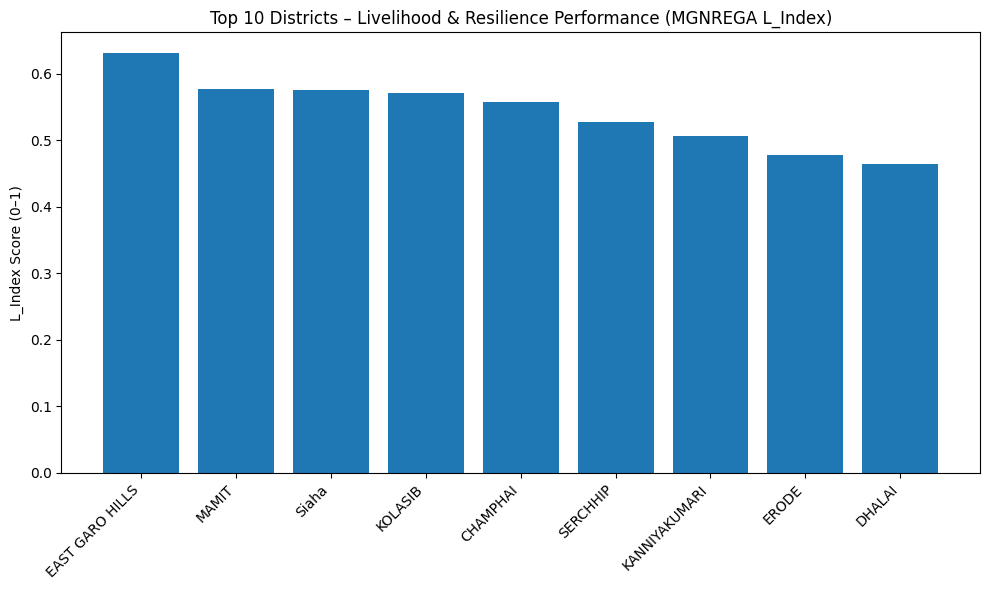

In [ ]:
# Top 10 Districts by Livelihood Resilience
top10_L = mgnre_df.sort_values('L_Index', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_L['district_name'], top10_L['L_Index'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Districts – Livelihood & Resilience Performance (MGNREGA L_Index)')
plt.ylabel('L_Index Score (0–1)')
plt.tight_layout()
plt.show()

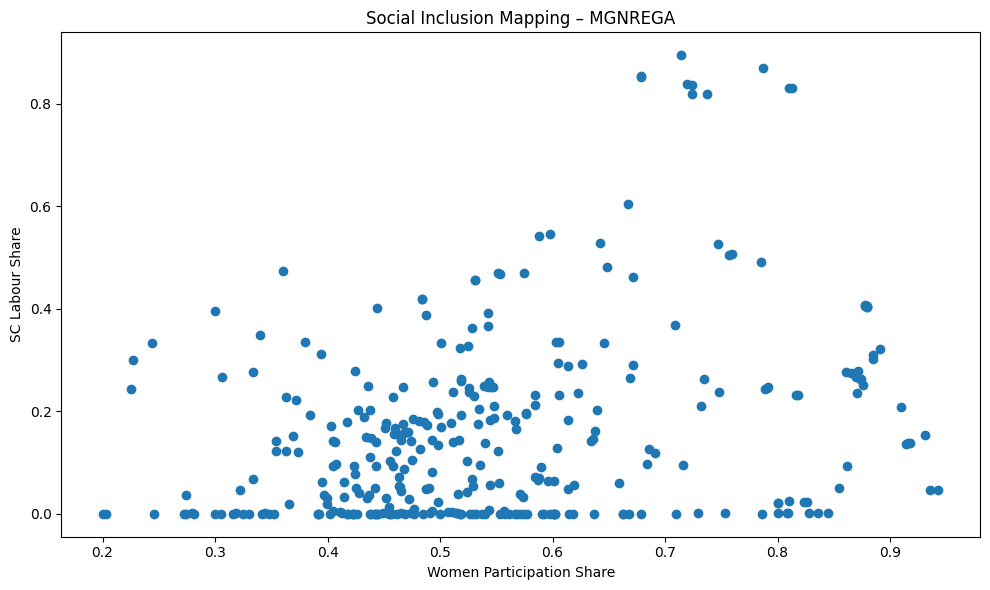

In [ ]:
# Women Participation vs SC/ST Share
plt.figure(figsize=(10,6))
plt.scatter(mgnre_df['women_participation_share'], mgnre_df['sc_share'])
plt.xlabel('Women Participation Share')
plt.ylabel('SC Labour Share')
plt.title('Social Inclusion Mapping – MGNREGA')
plt.tight_layout()
plt.show()

# ***MSME Numbers***

In [ ]:
msme_df=pd.read_excel("/content/drive/MyDrive/Colab Notebooks/MSME Numbers.xlsx")

In [ ]:
msme_df = msme_df.rename(columns={
    'District Name': 'district_name',
    'Total Udyog Aadhaar': 'total_msme',
    'Micro': 'micro_units',
    'Small': 'small_units',
    'Medium': 'medium_units'
})


def safe_div(num, den):
    num = num.astype(float)
    den = den.astype(float)
    return np.where(den > 0, num / den, np.nan)

In [ ]:
# Ensure relevant columns are numeric, coercing errors to NaN
msme_df['micro_units'] = pd.to_numeric(msme_df['micro_units'], errors='coerce')
msme_df['small_units'] = pd.to_numeric(msme_df['small_units'], errors='coerce')
msme_df['medium_units'] = pd.to_numeric(msme_df['medium_units'], errors='coerce')
msme_df['total_msme'] = pd.to_numeric(msme_df['total_msme'], errors='coerce')

# Share of enterprise type in a district
msme_df['micro_share'] = safe_div(msme_df['micro_units'], msme_df['total_msme'])
msme_df['small_share'] = safe_div(msme_df['small_units'], msme_df['total_msme'])
msme_df['medium_share'] = safe_div(msme_df['medium_units'], msme_df['total_msme'])

In [ ]:
# NORMALIZATION (MIN-MAX SCALING)
# ============================================================

def min_max(series):
    return (series - series.min()) / (series.max() - series.min())

norm_cols = [
    'total_msme',      # enterprise base size
    'micro_share',     # inclusiveness & rural entrepreneurship
    'small_share',     # industrial upgrading potential
    'medium_share'     # high value industrial depth
]

for col in norm_cols:
    msme_df[col + '_norm'] = min_max(msme_df[col])

**MSME ECONOMIC RESILIENCE INDEX (MSME_Index)**

Aggregation logic:
- total enterprise presence is most important (0.50)
- enterprise composition 50% equally (micro / small / medium)


In [ ]:


msme_df['MSME_Index'] = (
    0.50 * msme_df['total_msme_norm'] +
    0.20 * msme_df['micro_share_norm'] +
    0.15 * msme_df['small_share_norm'] +
    0.15 * msme_df['medium_share_norm']
)

# Ranking
msme_df['MSME_Rank'] = msme_df['MSME_Index'].rank(method='dense', ascending=False)

# Preview
msme_df[['district_name', 'MSME_Index', 'MSME_Rank']].head()

,district_name,MSME_Index,MSME_Rank
0,NIKOBARS,0.189229,677.0
1,NORTH AND MIDDLE ANDAMAN,0.196533,619.0
2,SOUTH ANDAMANS,0.209675,345.0
3,ANANTHAPUR,0.214363,262.0
4,CHITOOR,0.226611,146.0


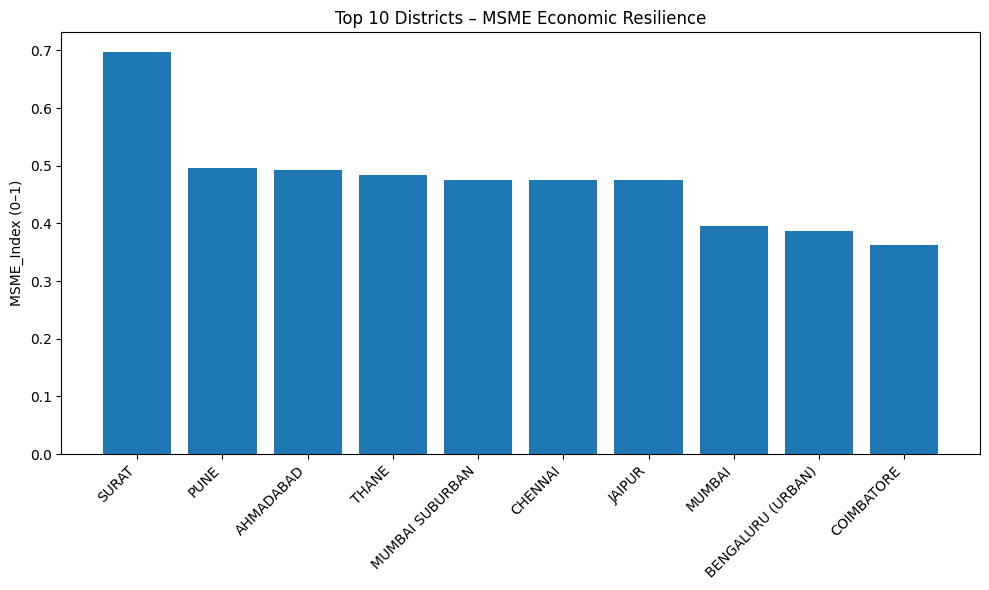

In [ ]:
#Top 10 Districts by MSME Index
top10_msme = msme_df.sort_values('MSME_Index', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_msme['district_name'], top10_msme['MSME_Index'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Districts – MSME Economic Resilience')
plt.ylabel('MSME_Index (0–1)')
plt.tight_layout()
plt.show()

# ***PMKSY KPIs***

In [ ]:
kpi_df=pd.read_excel("/content/drive/MyDrive/Colab Notebooks/District-wise KPIs.xlsx")

In [ ]:
kpi_df = kpi_df.rename(columns={
    'dist_name': 'district_name',
    'area_soilmoisture_activities_achie': 'soil_moisture',
    'area_afforestation_horticulture_achie': 'afforestation',
    'water_created_renovated_achie': 'water_created',
    'farmer_benefitted_achie': 'farmer_benefitted',
    'protective_irrigation_achie': 'protective_irrigation',
    'mandays_generated_achie': 'mandays_generated',
    'degraded_rainfed': 'degraded_land'
})

In [ ]:
def min_max(series):
    return (series - series.min()) / (series.max() - series.min())

In [ ]:
positive_cols = [
    'soil_moisture',
    'afforestation',
    'water_created',
    'farmer_benefitted',
    'protective_irrigation',
    'mandays_generated'
]

for col in positive_cols:
    kpi_df[col + '_norm'] = min_max(kpi_df[col])

In [ ]:
# NORMALIZE NEGATIVE INDICATOR (lower = better)
kpi_df['degraded_land_norm'] = 1 - min_max(kpi_df['degraded_land'])



In [ ]:

# COMPOSITE ENVIRONMENT INDEX (E_Index)
# Weighted by climate resilience importance:
# soil, water, degraded land carry more weight


kpi_df['E_Index'] = (
    0.20 * kpi_df['soil_moisture_norm'] +
    0.20 * kpi_df['water_created_norm'] +
    0.15 * kpi_df['afforestation_norm'] +
    0.15 * kpi_df['protective_irrigation_norm'] +
    0.10 * kpi_df['farmer_benefitted_norm'] +
    0.10 * kpi_df['mandays_generated_norm'] +
    0.10 * kpi_df['degraded_land_norm']
)

kpi_df['E_Rank'] = kpi_df['E_Index'].rank(method='dense', ascending=False)

# Preview
kpi_df[['district_name', 'E_Index', 'E_Rank']].head()

,district_name,E_Index,E_Rank
0,Alluri Sitharama Raju,0.102821,430.0
1,Anakapalli,0.105955,383.0
2,ANANTAPUR,0.133357,132.0
3,Annamayya,0.176170,41.0
4,CHITTOOR,0.141723,104.0


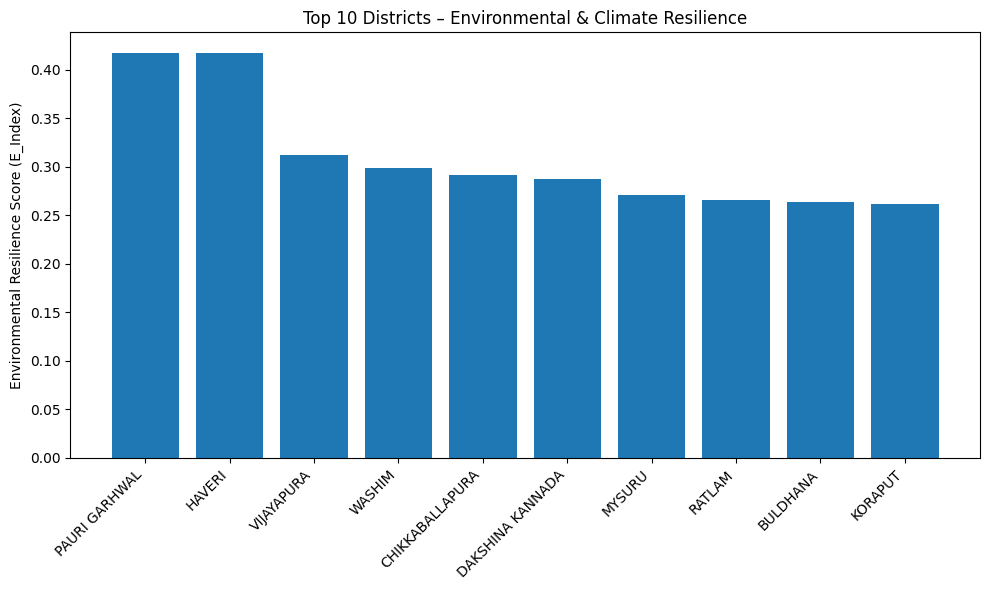

In [ ]:
# Top 10 Districts Environmental Resilience
top10_env = kpi_df.sort_values('E_Index', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_env['district_name'], top10_env['E_Index'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Environmental Resilience Score (E_Index)')
plt.title('Top 10 Districts – Environmental & Climate Resilience')
plt.tight_layout()
plt.show()

# ***IMR Data***

In [ ]:
imr_df=pd.read_excel("/content/drive/MyDrive/Colab Notebooks/Census Data.xlsx")

In [ ]:
imr_df = imr_df.rename(columns={
    'Districts': 'district_name',
    'IMR_Total': 'imr_total',
    'U5_Total': 'u5_total',
    'IMR_Male': 'imr_male',
    'U5_Male': 'u5_male',
    'IMR_Female': 'imr_female',
    'U5_Female': 'u5_female'
})

In [ ]:
def min_max(series):
    return (series - series.min()) / (series.max() - series.min())


In [ ]:
 # NORMALIZATION & INVERSION
# Negative indicators → invert after normalization
# Higher = better health outcome


imr_df['imr_norm'] = 1 - min_max(imr_df['imr_total'])
imr_df['u5_norm'] = 1 - min_max(imr_df['u5_total'])

In [ ]:
# Gender specific normalized values
imr_df['imr_gender_gap'] = imr_df['imr_female'] - imr_df['imr_male']
imr_df['imr_gender_gap_norm'] = min_max(abs(imr_df['imr_gender_gap']))  # smaller inequality = better
imr_df['imr_gender_gap_norm_inverted'] = 1 - imr_df['imr_gender_gap_norm']


**HEALTH INDEX (H_Index)**

Weighted combination:
- U5 mortality more important than IMR
- Gender Inequality is small component

In [ ]:
imr_df['H_Index'] = (
    0.45 * imr_df['u5_norm'] +
    0.45 * imr_df['imr_norm'] +
    0.10 * imr_df['imr_gender_gap_norm_inverted']
)

# Ranking
imr_df['H_Rank'] = imr_df['H_Index'].rank(method='dense', ascending=False)

# Preview
imr_df[['district_name', 'H_Index', 'H_Rank']].head()

,district_name,H_Index,H_Rank
0,West Tripura,0.736550,136.0
1,South Tripura,0.641106,250.0
2,Dhalai,0.532406,356.0
3,North Tripura,0.544606,349.0
4,Uttrakshi,0.703326,173.0


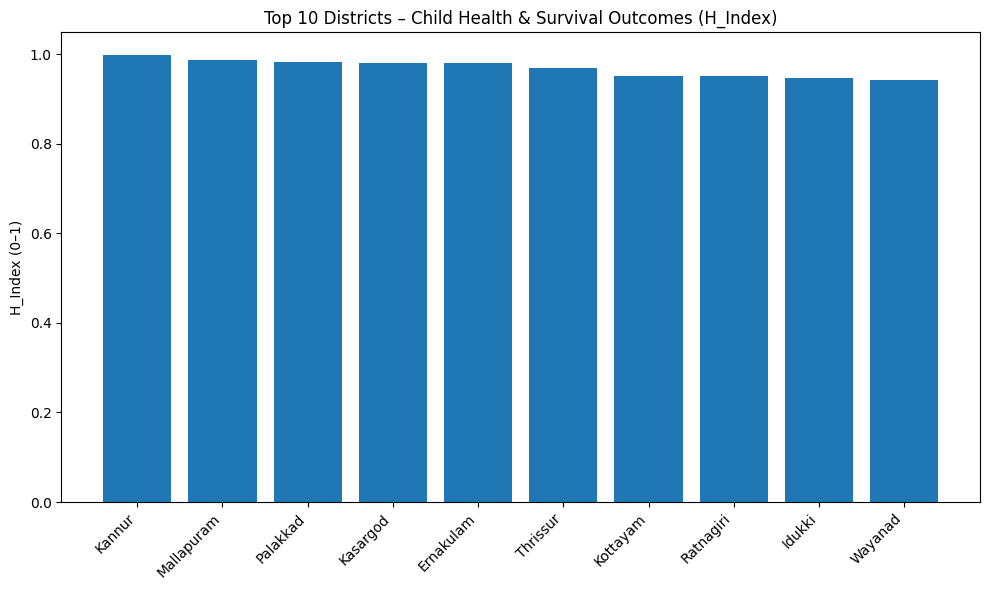

In [ ]:
# Top 10 Healthy Districts
top10_h = imr_df.sort_values('H_Index', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_h['district_name'], top10_h['H_Index'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('H_Index (0–1)')
plt.title('Top 10 Districts – Child Health & Survival Outcomes (H_Index)')
plt.tight_layout()
plt.show()

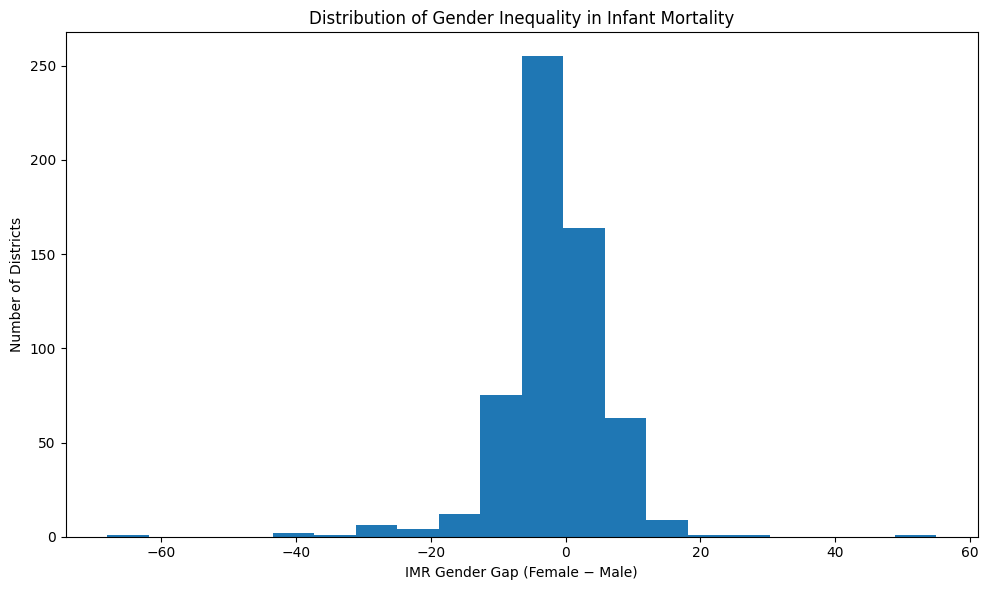

In [ ]:
# Gender Gap in IMR
plt.figure(figsize=(10,6))
plt.hist(imr_df['imr_gender_gap'], bins=20)
plt.xlabel('IMR Gender Gap (Female − Male)')
plt.ylabel('Number of Districts')
plt.title('Distribution of Gender Inequality in Infant Mortality')
plt.tight_layout()
plt.show()

# ***Census Data***

In [ ]:
census_df=pd.read_excel("/content/drive/MyDrive/Colab Notebooks/2011-IndiaStateDist-0000.xlsx")

In [ ]:
census_df = census_df.rename(columns={
    'District Name': 'district_name',
    'TOT_P': 'total_population',
    'TOT_WORK_P': 'total_workers',
    'TOT_WORK_F': 'female_workers',
    'TOT_WORK_M': 'male_workers',
    'MARGWORK_P': 'marginal_workers',
    'MARGWORK_0_3_P': 'marginal_0_3',
    'MARGWORK_3_6_P': 'marginal_3_6',
    'MARG_AL_P': 'marginal_agri',
    'MARG_CL_P': 'marginal_cultivators',
    'NON_WORK_P': 'non_workers',
    'P_SC': 'sc_population',
    'P_ST': 'st_population'
})

In [ ]:
def safe_div(num, den):
    num = num.astype(float)
    den = den.astype(float)
    return np.where(den > 0, num / den, np.nan)

In [ ]:
# % marginal workers among total workers
census_df['marginal_share'] = safe_div(
    census_df['marginal_workers'], census_df['total_workers']
)

# % workers with <3 months employment (acute vulnerability)
census_df['marginal_0_3_share'] = safe_div(
    census_df['marginal_0_3'], census_df['marginal_workers']
)

# % workers with 3–6 months
census_df['marginal_3_6_share'] = safe_div(
    census_df['marginal_3_6'], census_df['marginal_workers']
)

# Agriculture dependence among marginal workforce
census_df['agriculture_dependence'] = safe_div(
    census_df['marginal_agri'] + census_df['marginal_cultivators'],
    census_df['marginal_workers']
)

# Dependency burden / unemployment pressure
census_df['non_worker_share'] = safe_div(
    census_df['non_workers'], census_df['total_population']
)

# SC/ST vulnerability share
census_df['scst_share'] = safe_div(
    census_df['sc_population'] + census_df['st_population'],
    census_df['total_population']
)

# Female labour participation ratio
census_df['female_work_participation'] = safe_div(
    census_df['female_workers'], census_df['total_workers']
)

# Gender labour gap (negative indicator)
census_df['gender_gap'] = census_df['male_workers'] - census_df['female_workers']

In [ ]:
def min_max(series):
    return (series - series.min()) / (series.max() - series.min())

# Negative indicators (higher -> worse)
negative_cols = [
    'marginal_share',
    'marginal_0_3_share',
    'non_worker_share',
    'agriculture_dependence',
    'gender_gap'
]

# invert after normalization
for col in negative_cols:
    census_df[col + '_norm'] = 1 - min_max(census_df[col])

# Positive indicators (higher -> better)
positive_cols = [
    'female_work_participation',
    'scst_share'
]

for col in positive_cols:
    census_df[col + '_norm'] = min_max(census_df[col])

# ***Vulnerability Index***

In [ ]:
census_df['V_Index'] = (
    0.30 * census_df['marginal_share_norm'] +
    0.15 * census_df['marginal_0_3_share_norm'] +
    0.15 * census_df['agriculture_dependence_norm'] +
    0.20 * census_df['non_worker_share_norm'] +
    0.10 * census_df['female_work_participation_norm'] +
    0.10 * census_df['scst_share_norm']
)

census_df['V_Rank'] = census_df['V_Index'].rank(method='dense', ascending=False)


In [ ]:

# Preview
census_df[['district_name', 'V_Index', 'V_Rank']].head()

,district_name,V_Index,V_Rank
0,Kupwara,0.265825,640.0
1,Badgam,0.346130,608.0
2,Leh(Ladakh),0.671211,21.0
3,Kargil,0.442330,494.0
4,Punch,0.300484,631.0


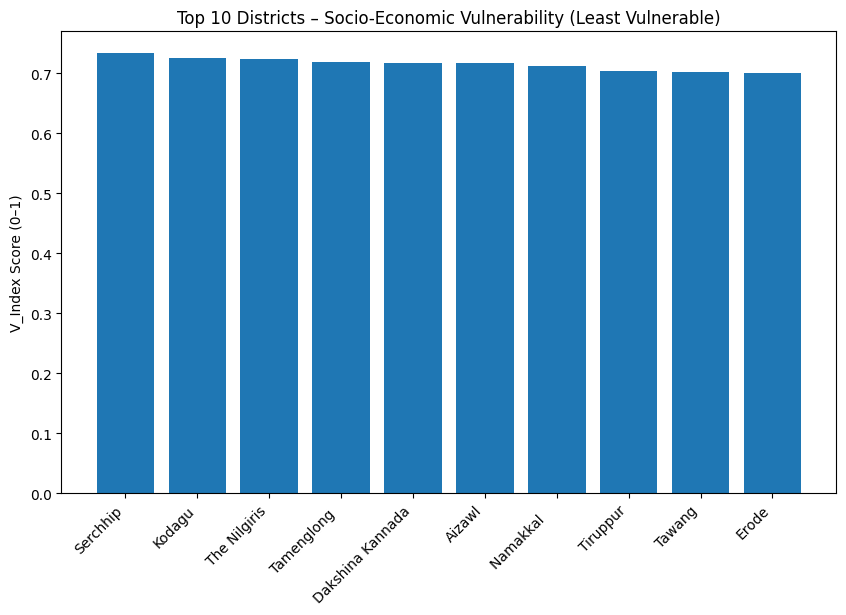

In [ ]:
# V_Index Top 10 Districts (Least vulnerable)
top10_v = census_df.sort_values('V_Index', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_v['district_name'], top10_v['V_Index'])
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Districts – Socio-Economic Vulnerability (Least Vulnerable)')
plt.ylabel('V_Index Score (0–1)')
plt.show()

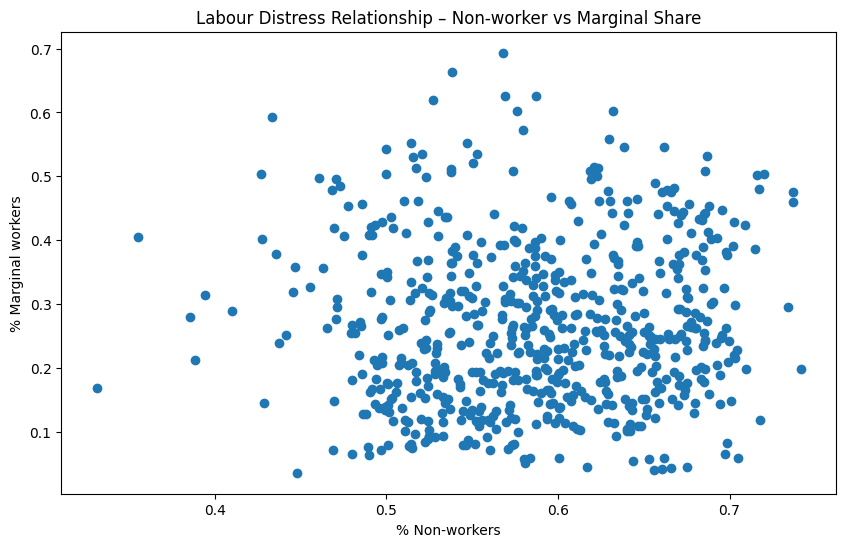

In [ ]:
# Scatter — Non-Workers vs Marginal Workers Share
plt.figure(figsize=(10,6))
plt.scatter(census_df['non_worker_share'], census_df['marginal_share'])
plt.xlabel('% Non-workers')
plt.ylabel('% Marginal workers')
plt.title('Labour Distress Relationship – Non-worker vs Marginal Share')
plt.show()

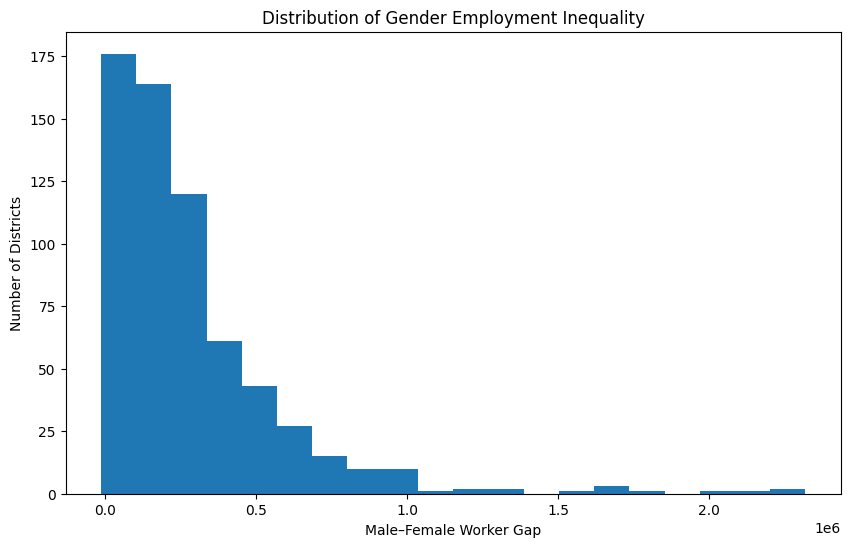

In [ ]:
# Gender Gap in Labour Force
plt.figure(figsize=(10,6))
plt.hist(census_df['gender_gap'], bins=20)
plt.xlabel('Male–Female Worker Gap')
plt.ylabel('Number of Districts')
plt.title('Distribution of Gender Employment Inequality')
plt.show()

# ***PGI Index***

In [ ]:
pgi_df=pd.read_excel("/content/drive/MyDrive/Colab Notebooks/District PGI.xlsx")

In [ ]:
pgi_df = pgi_df.rename(columns={
    'District': 'district_name',
    'Overall': 'overall_score',
    'Outcome': 'outcome_score',
    'Effective Classroom Transaction (ECT)': 'ect_score',
    'Infrastructure, Facilities, Student Entitlements (IF & SE)': 'infra_score',
    'School safety and Child Protection (SS & CP)': 'safety_score',
    'Digital Learning (DL)': 'digital_score',
    'Governance Processes (GP)': 'governance_score'
})

In [ ]:
def min_max(series):
    return (series - series.min()) / (series.max() - series.min())

In [ ]:
norm_cols = [
    'overall_score',
    'outcome_score',
    'ect_score',
    'infra_score',
    'safety_score',
    'digital_score',
    'governance_score'
]

# Apply normalization
for col in norm_cols:
    pgi_df[col + '_norm'] = min_max(pgi_df[col])

# **Composite Index for Governance & Institutional Quality (G_Index)**
- Weights based on policy importance

In [ ]:
pgi_df['G_Index'] = (
    0.25 * pgi_df['overall_score_norm'] +
    0.15 * pgi_df['outcome_score_norm'] +
    0.15 * pgi_df['infra_score_norm'] +
    0.15 * pgi_df['digital_score_norm'] +
    0.15 * pgi_df['governance_score_norm'] +
    0.10 * pgi_df['safety_score_norm'] +
    0.05 * pgi_df['ect_score_norm']
)

# Ranking (higher = better governance institutional performance)
pgi_df['G_Rank'] = pgi_df['G_Index'].rank(method='dense', ascending=False)

# Preview result
pgi_df[['district_name', 'G_Index', 'G_Rank']].head()

,district_name,G_Index,G_Rank
0,South Andamans,0.632483,159.0
1,Middle And North Andamans,0.583325,200.0
2,Nicobars,0.533995,261.0
3,Guntur,0.726257,73.0
4,Visakhapatnam,0.733452,61.0


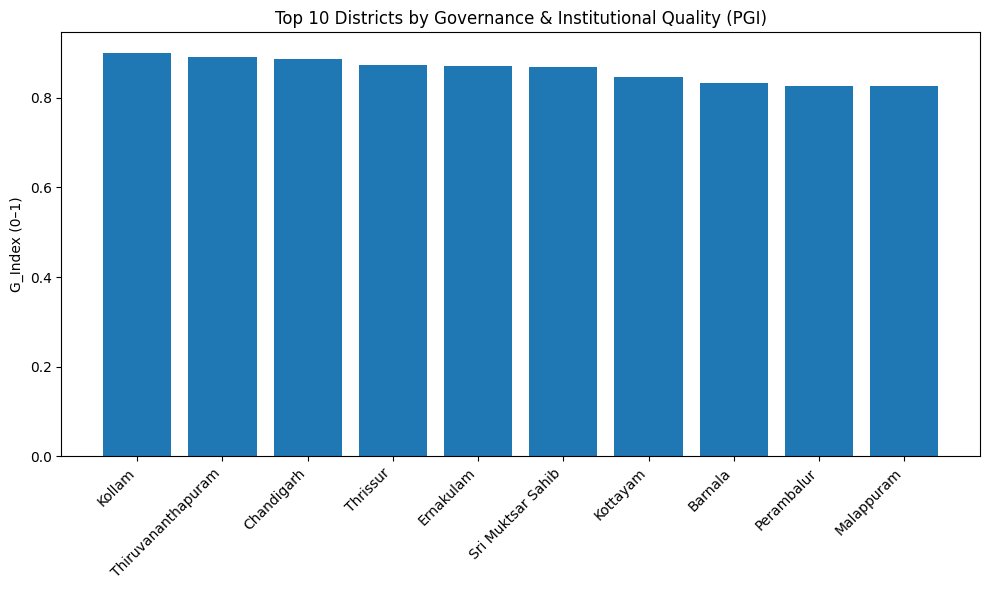

In [ ]:
# Top 10 Districts by Governance / PGI Index
top10_g = pgi_df.sort_values('G_Index', ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10_g['district_name'], top10_g['G_Index'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('G_Index (0–1)')
plt.title('Top 10 Districts by Governance & Institutional Quality (PGI)')
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px

radar_df = pgi_df[['district_name', 'outcome_score_norm','ect_score_norm','infra_score_norm','safety_score_norm','digital_score_norm','governance_score_norm']]

fig = px.line_polar(radar_df.head(5),
                    r=['outcome_score_norm','ect_score_norm','infra_score_norm','safety_score_norm','digital_score_norm','governance_score_norm'],
                    theta=['Outcome','ECT','Infra','Safety','Digital','Governance'],
                    line_close=True)
fig.show()


# ***MASTER MERGING OF ALL INDICES + FINAL COMPOSITE INDEX***

In [ ]:
dfs = [kpi_df, school_df, mgnre_df, msme_df, imr_df, census_df, pgi_df]

for df in dfs:
    df['district_name'] = df['district_name'].str.strip().str.title()


In [ ]:
master_df = kpi_df[['district_name', 'E_Index']].copy()

master_df = master_df.merge(school_df[['district_name', 'Edu_Index']], on='district_name', how='outer')
master_df = master_df.merge(mgnre_df[['district_name', 'L_Index']], on='district_name', how='outer')
master_df = master_df.merge(msme_df[['district_name', 'MSME_Index']], on='district_name', how='outer')
master_df = master_df.merge(imr_df[['district_name', 'H_Index']], on='district_name', how='outer')
master_df = master_df.merge(census_df[['district_name', 'V_Index']], on='district_name', how='outer')
master_df = master_df.merge(pgi_df[['district_name', 'G_Index']], on='district_name', how='outer')


In [ ]:
# Filling missing values with Median of that column
index_cols = ['E_Index', 'Edu_Index', 'L_Index', 'MSME_Index', 'H_Index', 'V_Index', 'G_Index']

for col in index_cols:
    median_val = master_df[col].median()
    master_df[col] = master_df[col].fillna(median_val)


In [ ]:
# Re-normalize all sub-indices to 0–1 range after filling missing values
def min_max(series):
    return (series - series.min()) / (series.max() - series.min())

for col in index_cols:
    master_df[col + '_norm'] = min_max(master_df[col])

## ***PCA-BASED WEIGHT GENERATION FOR SUB-INDICES***

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [ ]:
# Select only normalized sub-indices
pca_features = master_df[['E_Index_norm', 'Edu_Index_norm', 'L_Index_norm',
                          'MSME_Index_norm', 'H_Index_norm', 'V_Index_norm', 'G_Index_norm']]

# Standardize data (PCA works on standardized variance)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(pca_features)

# Run PCA
pca = PCA(n_components=1)   # Only first principal component needed
pca.fit(scaled_features)

# Extract component loadings
loadings = pca.components_[0]

# Convert loadings to absolute values and normalize to weights
pca_weights = np.abs(loadings) / np.sum(np.abs(loadings))

# Create a dictionary of PCA weights
weight_dict = dict(zip(pca_features.columns, pca_weights))

print("\n📌 PCA-derived Weights:")
for key, value in weight_dict.items():
    print(f"{key}: {value:.4f}")


📌 PCA-derived Weights:
E_Index_norm: 0.0278
Edu_Index_norm: 0.2562
L_Index_norm: 0.0181
MSME_Index_norm: 0.0475
H_Index_norm: 0.1830
V_Index_norm: 0.1958
G_Index_norm: 0.2716


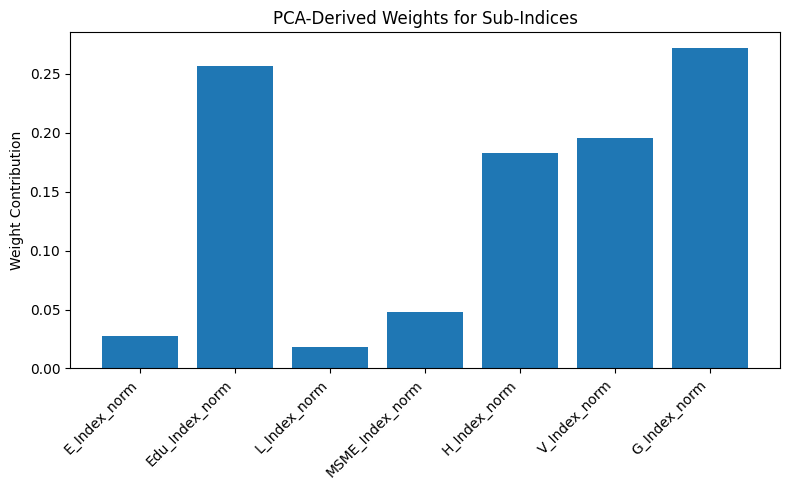

In [ ]:
plt.figure(figsize=(8,5))
plt.bar(weight_dict.keys(), weight_dict.values())
plt.xticks(rotation=45, ha='right')
plt.title('PCA-Derived Weights for Sub-Indices')
plt.ylabel('Weight Contribution')
plt.tight_layout()
plt.show()

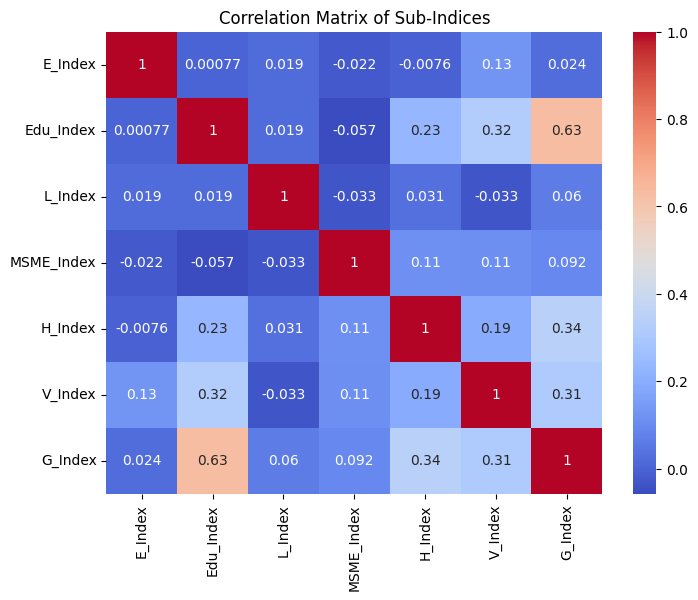

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(master_df[['E_Index','Edu_Index','L_Index','MSME_Index','H_Index','V_Index','G_Index']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Sub-Indices')
plt.show()

In [ ]:
master_df[['E_Index','Edu_Index','L_Index','MSME_Index','H_Index','V_Index','G_Index']].describe()

,E_Index,Edu_Index,L_Index,MSME_Index,H_Index,V_Index,G_Index
count,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000
mean,0.122437,0.730399,0.293897,0.213531,0.650571,0.512988,0.459075
std,0.024373,0.082411,0.047339,0.030164,0.105690,0.070930,0.139760
min,0.013434,0.261270,0.088919,0.150000,0.094118,0.265825,0.094271
25%,0.118522,0.718242,0.293800,0.204507,0.646988,0.500197,0.402818
50%,0.118522,0.740802,0.293800,0.207858,0.659601,0.515292,0.456924
75%,0.118522,0.761914,0.293800,0.211555,0.667367,0.529051,0.494948
max,0.417883,0.914598,0.630828,0.696506,0.998529,0.733215,0.901074


In [ ]:
# APPLY PCA WEIGHTS TO CALCULATE PCA-BASED COMPOSITE INDEX

master_df['DSRI_PCA_Index'] = (
    pca_weights[0] * master_df['E_Index_norm'] +
    pca_weights[1] * master_df['Edu_Index_norm'] +
    pca_weights[2] * master_df['L_Index_norm'] +
    pca_weights[3] * master_df['MSME_Index_norm'] +
    pca_weights[4] * master_df['H_Index_norm'] +
    pca_weights[5] * master_df['V_Index_norm'] +
    pca_weights[6] * master_df['G_Index_norm']
)

# Ranking using PCA-weighted index
master_df['DSRI_PCA_Rank'] = master_df['DSRI_PCA_Index'].rank(method='dense', ascending=False)

# Preview
master_df[['district_name', 'DSRI_PCA_Index', 'DSRI_PCA_Rank']].head()

,district_name,DSRI_PCA_Index,DSRI_PCA_Rank
0,Adilabad,0.501079,1024.0
1,Agar Malwa,0.504853,1002.0
2,Agra,0.481217,1097.0
3,Ahilyanagar,0.601929,295.0
4,Ahmadabad,0.618732,230.0


# ***Top 20 and Bottom 20 Districts by Composite Index***

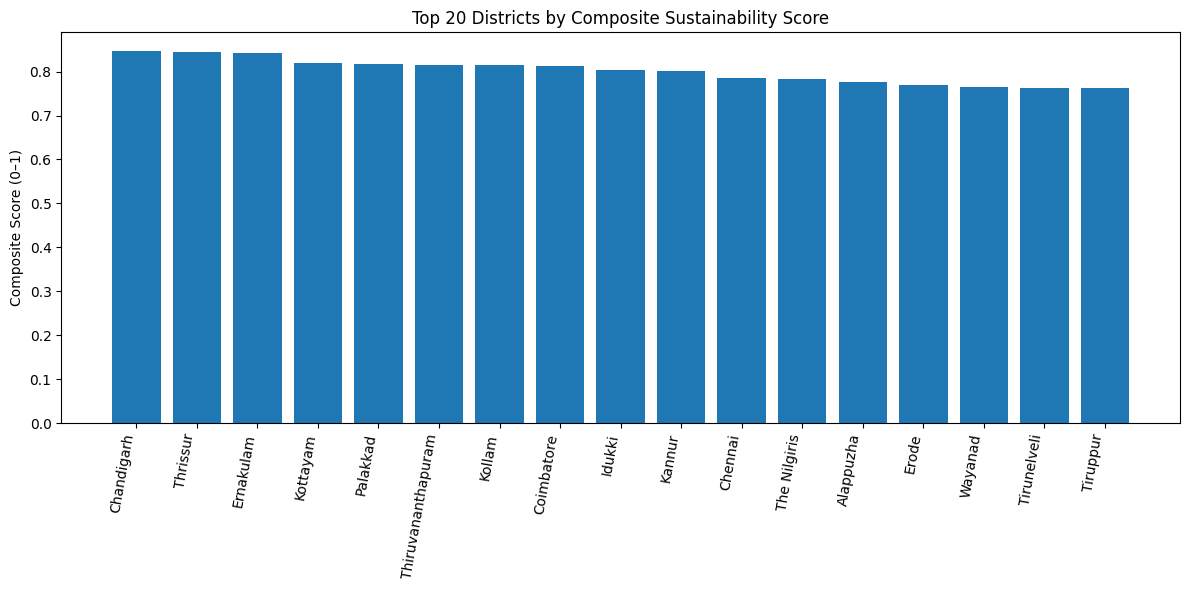

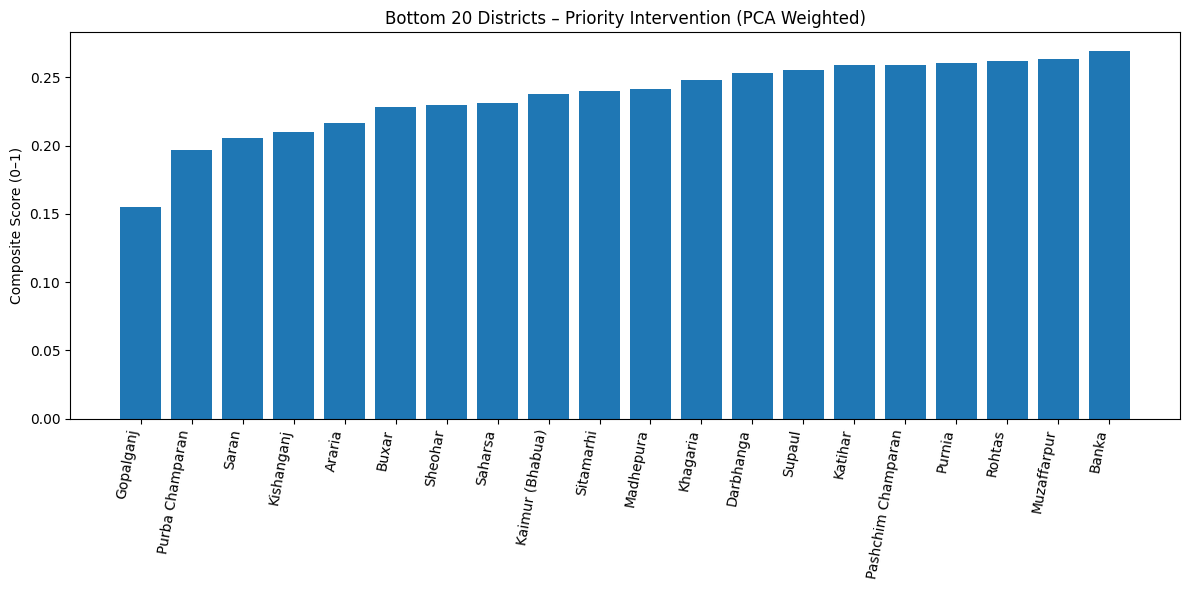

In [ ]:
top20 = master_df.sort_values('DSRI_PCA_Index', ascending=False).head(20)
plt.figure(figsize=(12,6))
plt.bar(top20['district_name'], top20['DSRI_PCA_Index'])
plt.xticks(rotation=80, ha='right')
plt.title('Top 20 Districts by Composite Sustainability Score')
plt.ylabel('Composite Score (0–1)')
plt.tight_layout()
plt.show()


bottom20 = master_df.sort_values('DSRI_PCA_Index', ascending=True).head(20)

plt.figure(figsize=(12,6))
plt.bar(bottom20['district_name'], bottom20['DSRI_PCA_Index'])
plt.xticks(rotation=80, ha='right')
plt.title('Bottom 20 Districts – Priority Intervention (PCA Weighted)')
plt.ylabel('Composite Score (0–1)')
plt.tight_layout()
plt.show()

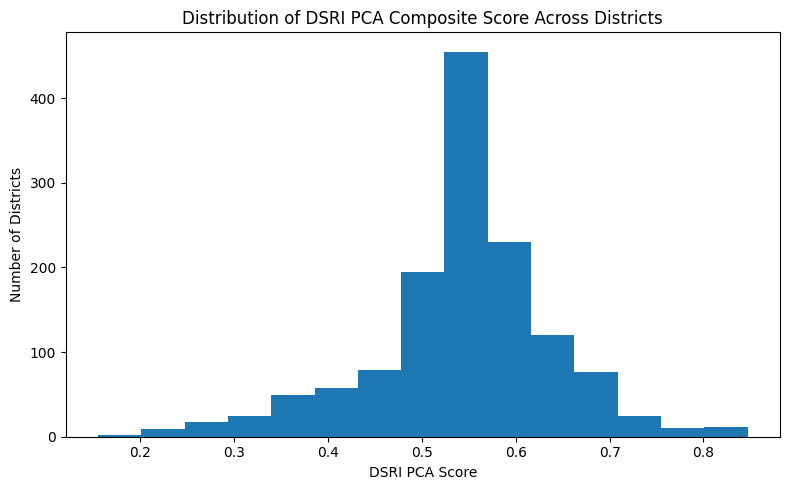

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(master_df['DSRI_PCA_Index'], bins=15)
plt.title('Distribution of DSRI PCA Composite Score Across Districts')
plt.xlabel('DSRI PCA Score')
plt.ylabel('Number of Districts')
plt.tight_layout()
plt.show()

# ***INDIAN ECONOMY / POLICY PRIORITY BASED WEIGHTING***

In [ ]:
# Weight distribution aligned to Indian macroeconomic and policy priorities
weight_policy = {
    'E_Index_norm': 0.20,
    'Edu_Index_norm': 0.15,
    'L_Index_norm': 0.20,
    'MSME_Index_norm': 0.10,
    'H_Index_norm': 0.15,
    'V_Index_norm': 0.10,
    'G_Index_norm': 0.10
}

# Applying weights → Composite score (DSRI policy priority version)
master_df['DSRI_Policy_Index'] = (
    weight_policy['E_Index_norm']   * master_df['E_Index_norm'] +
    weight_policy['Edu_Index_norm'] * master_df['Edu_Index_norm'] +
    weight_policy['L_Index_norm']   * master_df['L_Index_norm'] +
    weight_policy['MSME_Index_norm']* master_df['MSME_Index_norm'] +
    weight_policy['H_Index_norm']   * master_df['H_Index_norm'] +
    weight_policy['V_Index_norm']   * master_df['V_Index_norm'] +
    weight_policy['G_Index_norm']   * master_df['G_Index_norm']
)

# Ranking column for policy-based index
master_df['DSRI_Policy_Rank'] = master_df['DSRI_Policy_Index'].rank(method='dense', ascending=False)

# Preview result
master_df[['district_name','DSRI_Policy_Index','DSRI_Policy_Rank']].head()

,district_name,DSRI_Policy_Index,DSRI_Policy_Rank
0,Adilabad,0.415524,990.0
1,Agar Malwa,0.422481,933.0
2,Agra,0.421076,942.0
3,Ahilyanagar,0.460183,433.0
4,Ahmadabad,0.539111,49.0


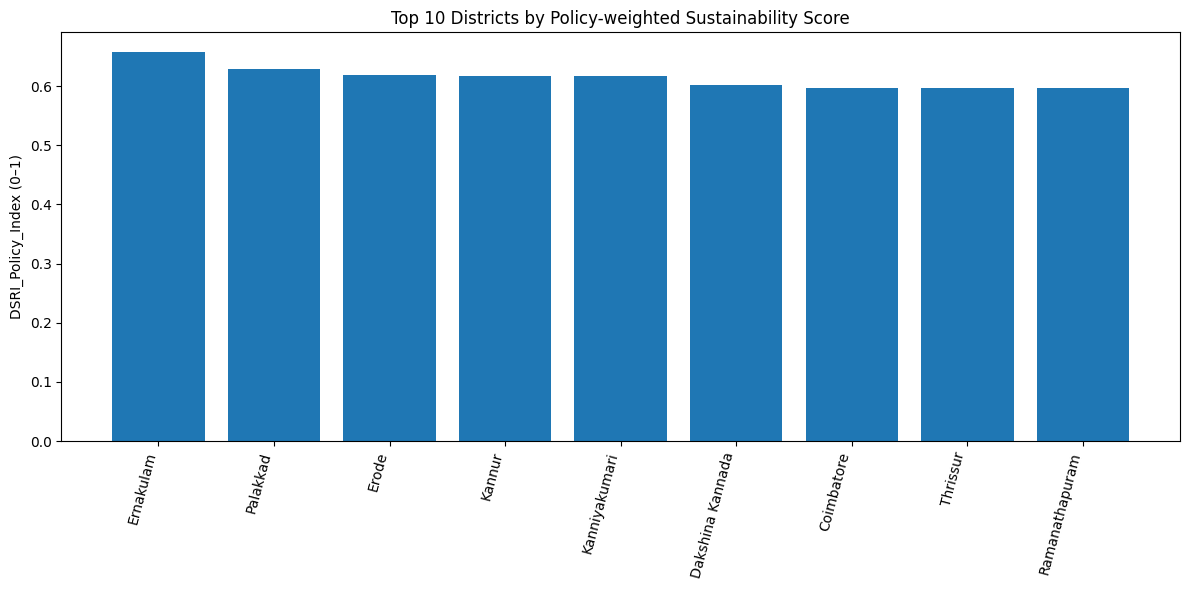

In [ ]:
# Top 10 districts by Policy-weighted DSRI

top10_policy = master_df.sort_values('DSRI_Policy_Index', ascending=False).head(10)
plt.figure(figsize=(12,6))
plt.bar(top10_policy['district_name'], top10_policy['DSRI_Policy_Index'])
plt.xticks(rotation=75, ha='right')
plt.ylabel('DSRI_Policy_Index (0–1)')
plt.title('Top 10 Districts by Policy-weighted Sustainability Score')
plt.tight_layout()
plt.show()

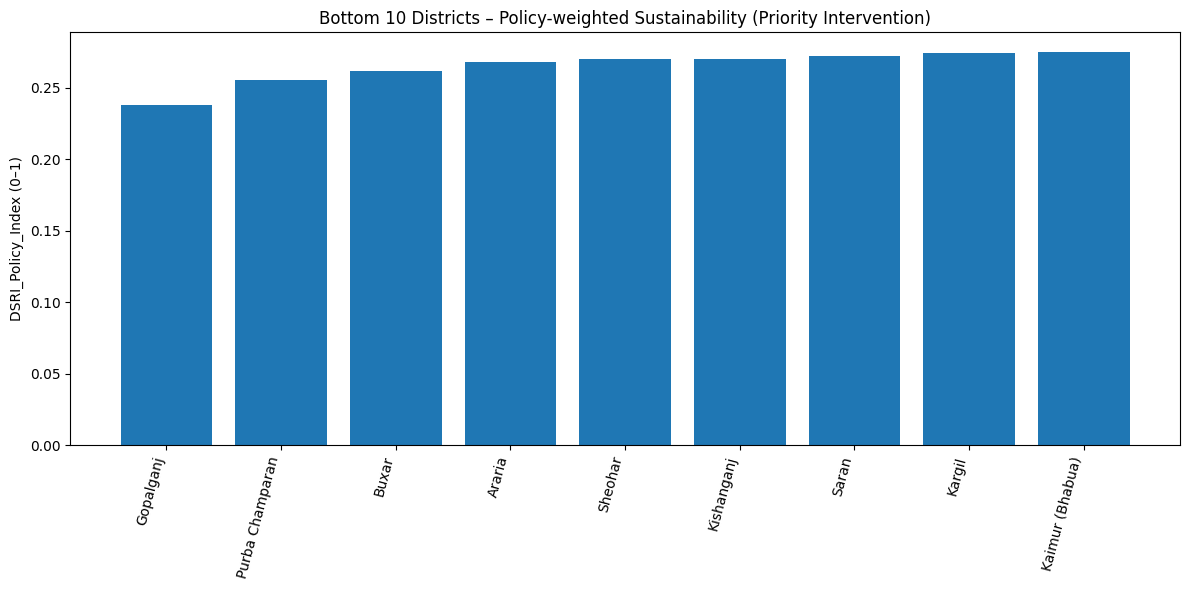

,district_name,E_Index,Edu_Index,L_Index,MSME_Index,H_Index,V_Index,G_Index,E_Index_norm,Edu_Index_norm,L_Index_norm,MSME_Index_norm,H_Index_norm,V_Index_norm,G_Index_norm,DSRI_PCA_Index,DSRI_PCA_Rank,DSRI_Policy_Index,DSRI_Policy_Rank
409,Gopalganj,0.118522,0.271781,0.293800,0.213627,0.615235,0.276209,0.157698,0.259829,0.016087,0.378073,0.116426,0.576195,0.022216,0.078616,0.154865,1344.0,0.238149,1344.0
1004,Purba Champaran,0.118522,0.261270,0.293800,0.207858,0.582241,0.385704,0.179540,0.259829,0.000000,0.378073,0.105869,0.539714,0.256485,0.105688,0.196791,1343.0,0.255342,1343.0
210,Buxar,0.092079,0.347243,0.293800,0.214332,0.591271,0.351468,0.214715,0.194451,0.131592,0.378073,0.117715,0.549698,0.183237,0.149286,0.228570,1339.0,0.261722,1342.0
46,Araria,0.118522,0.345756,0.268416,0.281798,0.519586,0.415721,0.124059,0.259829,0.129317,0.331231,0.241165,0.470436,0.320709,0.036922,0.216729,1340.0,0.268054,1341.0
1130,Sheohar,0.118522,0.372197,0.293800,0.208753,0.513703,0.371940,0.205282,0.259829,0.169788,0.378073,0.107506,0.463932,0.227037,0.137594,0.229396,1338.0,0.269852,1340.0


In [ ]:
# Bottom 10 districts by Policy-weighted DSRI
bottom10_policy = master_df.sort_values('DSRI_Policy_Index', ascending=True).head(10)

plt.figure(figsize=(12,6))
plt.bar(bottom10_policy['district_name'], bottom10_policy['DSRI_Policy_Index'])
plt.xticks(rotation=75, ha='right')
plt.ylabel('DSRI_Policy_Index (0–1)')
plt.title('Bottom 10 Districts – Policy-weighted Sustainability (Priority Intervention)')
plt.tight_layout()
plt.show()

bottom10_policy.head()

In [ ]:
bottom10_policy.head()

,district_name,E_Index,Edu_Index,L_Index,MSME_Index,H_Index,V_Index,G_Index,E_Index_norm,Edu_Index_norm,L_Index_norm,MSME_Index_norm,H_Index_norm,V_Index_norm,G_Index_norm,DSRI_PCA_Index,DSRI_PCA_Rank,DSRI_Policy_Index,DSRI_Policy_Rank
409,Gopalganj,0.118522,0.271781,0.293800,0.213627,0.615235,0.276209,0.157698,0.259829,0.016087,0.378073,0.116426,0.576195,0.022216,0.078616,0.154865,1344.0,0.238149,1344.0
1004,Purba Champaran,0.118522,0.261270,0.293800,0.207858,0.582241,0.385704,0.179540,0.259829,0.000000,0.378073,0.105869,0.539714,0.256485,0.105688,0.196791,1343.0,0.255342,1343.0
210,Buxar,0.092079,0.347243,0.293800,0.214332,0.591271,0.351468,0.214715,0.194451,0.131592,0.378073,0.117715,0.549698,0.183237,0.149286,0.228570,1339.0,0.261722,1342.0
46,Araria,0.118522,0.345756,0.268416,0.281798,0.519586,0.415721,0.124059,0.259829,0.129317,0.331231,0.241165,0.470436,0.320709,0.036922,0.216729,1340.0,0.268054,1341.0
1130,Sheohar,0.118522,0.372197,0.293800,0.208753,0.513703,0.371940,0.205282,0.259829,0.169788,0.378073,0.107506,0.463932,0.227037,0.137594,0.229396,1338.0,0.269852,1340.0


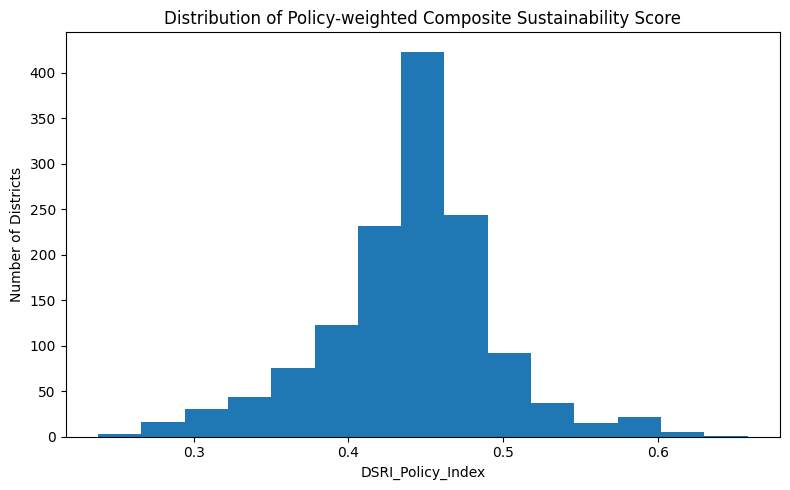

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(master_df['DSRI_Policy_Index'], bins=15)
plt.xlabel('DSRI_Policy_Index')
plt.ylabel('Number of Districts')
plt.title('Distribution of Policy-weighted Composite Sustainability Score')
plt.tight_layout()
plt.show()

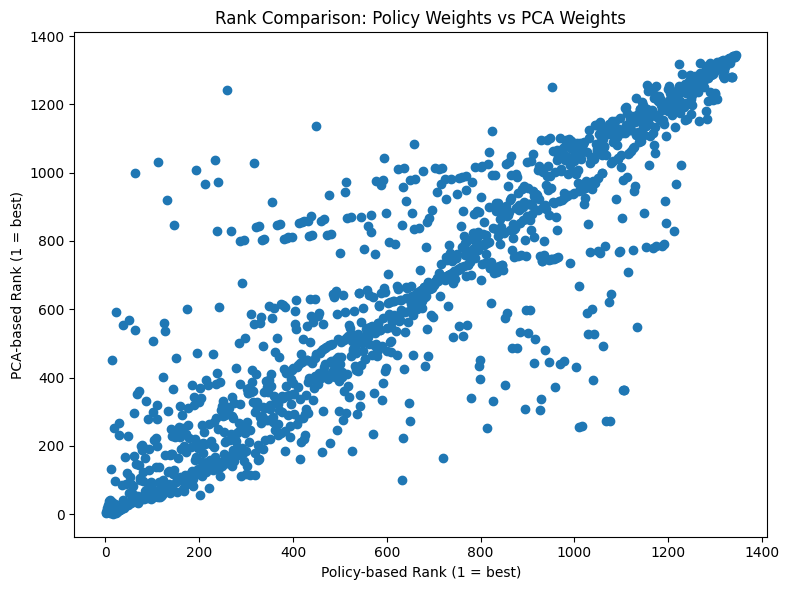

In [ ]:
#Scatter – Policy Rank vs PCA Rank

compare_df = master_df[['district_name', 'DSRI_Policy_Rank', 'DSRI_PCA_Rank']].copy()

plt.figure(figsize=(8,6))
plt.scatter(compare_df['DSRI_Policy_Rank'], compare_df['DSRI_PCA_Rank'])
plt.xlabel('Policy-based Rank (1 = best)')
plt.ylabel('PCA-based Rank (1 = best)')
plt.title('Rank Comparison: Policy Weights vs PCA Weights')
plt.tight_layout()
plt.show()

In [ ]:
# 5 representative districts: 2 top, 2 middle, 1 bottom, to compare Weights of Methods

sorted_policy = master_df.sort_values('DSRI_Policy_Index', ascending=False).reset_index(drop=True)

top2 = sorted_policy.head(2)
mid2 = sorted_policy.iloc[[len(sorted_policy)//2 - 1, len(sorted_policy)//2]]
bottom1 = sorted_policy.tail(1)

sample5 = pd.concat([top2, mid2, bottom1], ignore_index=True)



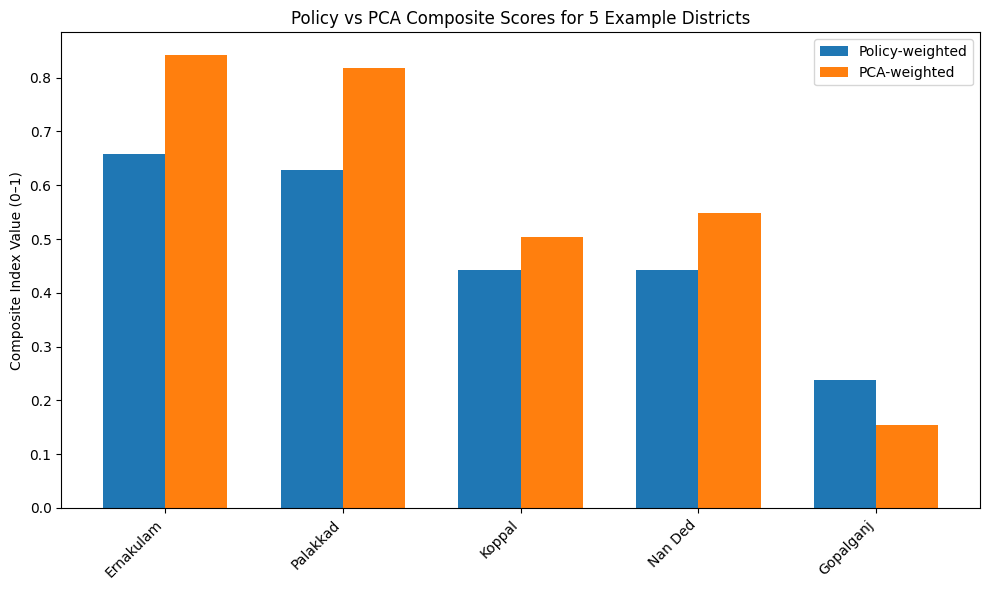

In [ ]:
# Bar comparison: Policy vs PCA index for these 5
x = np.arange(len(sample5))  # 5 positions
width = 0.35

plt.figure(figsize=(10,6))
plt.bar(x - width/2, sample5['DSRI_Policy_Index'], width, label='Policy-weighted')
plt.bar(x + width/2, sample5['DSRI_PCA_Index'], width, label='PCA-weighted')

plt.xticks(x, sample5['district_name'], rotation=45, ha='right')
plt.ylabel('Composite Index Value (0–1)')
plt.title('Policy vs PCA Composite Scores for 5 Example Districts')
plt.legend()
plt.tight_layout()
plt.show()

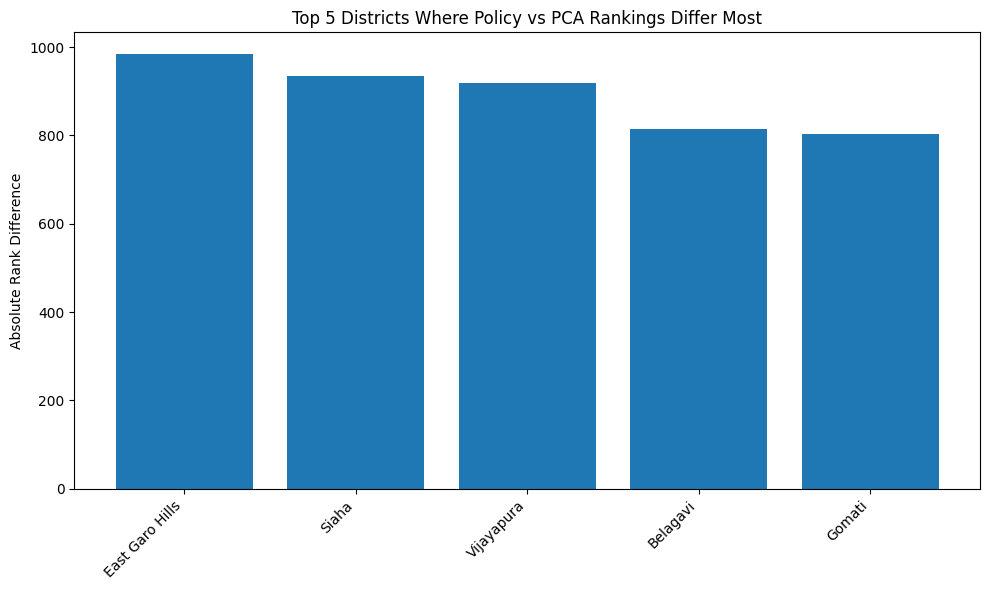

In [ ]:
# 5 districts with the largest absolute rank difference
rank_diff_df = master_df[['district_name', 'DSRI_Policy_Rank', 'DSRI_PCA_Rank']].copy()
rank_diff_df['Rank_Diff'] = (rank_diff_df['DSRI_Policy_Rank'] - rank_diff_df['DSRI_PCA_Rank']).abs()

top_diff5 = rank_diff_df.sort_values('Rank_Diff', ascending=False).head(5)

plt.figure(figsize=(10,6))
plt.bar(top_diff5['district_name'], top_diff5['Rank_Diff'])
plt.xticks(rotation=45, ha='right')
plt.ylabel('Absolute Rank Difference')
plt.title('Top 5 Districts Where Policy vs PCA Rankings Differ Most')
plt.tight_layout()
plt.show()

In [ ]:
summary_stats = master_df[[
    'E_Index', 'Edu_Index', 'L_Index', 'MSME_Index',
    'H_Index', 'V_Index', 'G_Index',
    'DSRI_Policy_Index', 'DSRI_PCA_Index'
]].describe()



In [ ]:
summary_stats.describe()

,E_Index,Edu_Index,L_Index,MSME_Index,H_Index,V_Index,G_Index,DSRI_Policy_Index,DSRI_PCA_Index
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,170.241711,170.651205,170.367798,170.339265,170.602858,170.515937,170.493609,170.464389,170.535452
std,481.139022,480.973629,481.088091,481.099628,480.993178,481.028243,481.037287,481.049063,481.020377
min,0.013434,0.082411,0.047339,0.030164,0.094118,0.070930,0.094271,0.055237,0.096612
25%,0.094984,0.603999,0.242580,0.190880,0.511664,0.441604,0.337054,0.370264,0.416474
50%,0.118522,0.735600,0.293800,0.209707,0.655086,0.514140,0.457999,0.440447,0.545496
75%,0.196299,0.800085,0.378130,0.334275,0.750158,0.580092,0.596480,0.515892,0.654625
max,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000,1361.000000


# ***Thematic Pillar Clusters (Environment / Human / Economy / Gov+Vul)***

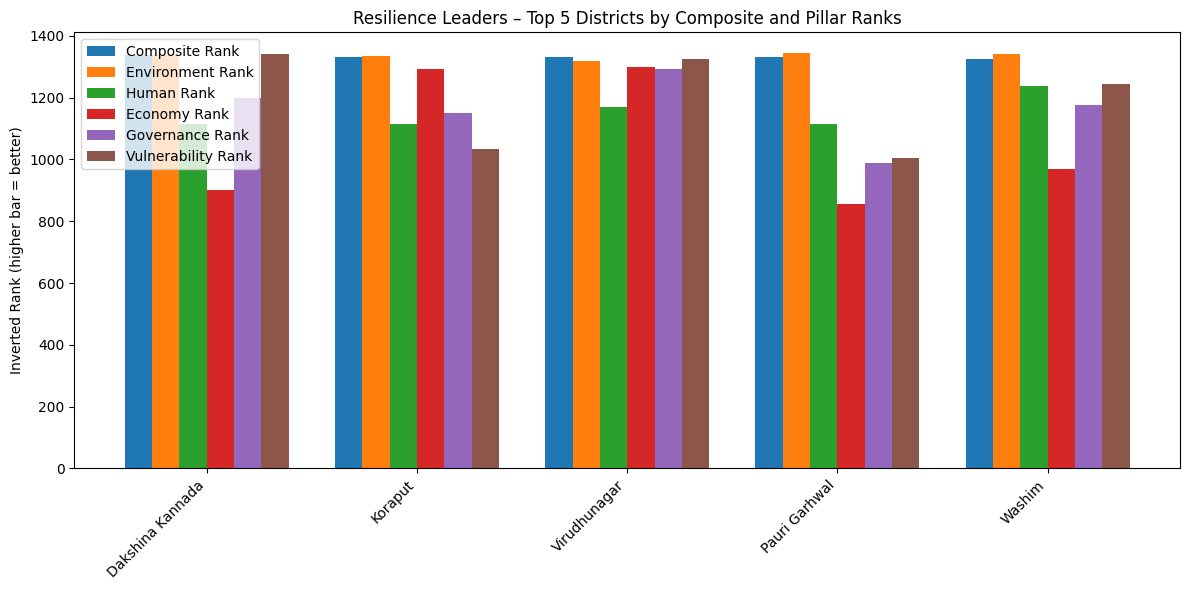

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select the normalized sub-indices for clustering
clustering_features = master_df[[
    'E_Index_norm', 'Edu_Index_norm', 'L_Index_norm',
    'MSME_Index_norm', 'H_Index_norm', 'V_Index_norm', 'G_Index_norm'
]].copy()

# Standardize the features (important for K-Means)
scaler = StandardScaler()
scaled_clustering_features = scaler.fit_transform(clustering_features)

# Perform K-Means clustering
# Choosing 3 clusters as implied by the previously errored cells (Leaders, Emerging, Hotspots)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init to suppress warning
master_df['Cluster'] = kmeans.fit_predict(scaled_clustering_features)

# Map cluster numbers to descriptive names
# Attempt to order clusters based on their average DSRI_PCA_Index for more meaningful names
cluster_means = master_df.groupby('Cluster')['DSRI_PCA_Index'].mean().sort_values(ascending=True)
sorted_clusters = cluster_means.index.tolist()

# Create a new mapping based on sorted means
new_cluster_mapping = {
    sorted_clusters[0]: 'Vulnerability Hotspots',
    sorted_clusters[1]: 'Emerging Opportunity Districts',
    sorted_clusters[2]: 'Resilience Leaders',
}

master_df['Cluster_Name'] = master_df['Cluster'].map(new_cluster_mapping)


# Calculate ranks for composite and pillar indices
master_df['Rank_Composite'] = master_df['DSRI_Policy_Rank'] # Using policy rank as composite
master_df['Rank_Env'] = master_df['E_Index_norm'].rank(method='dense', ascending=False)
master_df['Rank_Human'] = master_df['H_Index_norm'].rank(method='dense', ascending=False)
# Create a combined Economy Index for ranking
master_df['Economy_Index_norm'] = (master_df['L_Index_norm'] + master_df['MSME_Index_norm']) / 2
master_df['Rank_Economy'] = master_df['Economy_Index_norm'].rank(method='dense', ascending=False)
master_df['Rank_Gov'] = master_df['G_Index_norm'].rank(method='dense', ascending=False)
master_df['Rank_Vul'] = master_df['V_Index_norm'].rank(method='dense', ascending=False)


# Filter cluster: Resilience Leaders
leaders = master_df[master_df['Cluster_Name'] == 'Resilience Leaders'].copy()

# 🔹 ensure one row per district
leaders = leaders.drop_duplicates(subset='district_name')

# Top 5 by best composite rank (1 = best)
leaders_top5 = leaders.sort_values('Rank_Composite', ascending=True).head(5)

# Invert ranks for plotting
rank_cols = ['Rank_Composite', 'Rank_Env', 'Rank_Human', 'Rank_Economy', 'Rank_Gov', 'Rank_Vul']
max_rank = master_df[rank_cols].max().max()

for col in rank_cols:
    leaders_top5[col + '_plot'] = max_rank + 1 - leaders_top5[col]

x = np.arange(len(leaders_top5))
width = 0.13

plt.figure(figsize=(12,6))
plt.bar(x - 2.5*width, leaders_top5['Rank_Composite_plot'], width, label='Composite Rank')
plt.bar(x - 1.5*width, leaders_top5['Rank_Env_plot'],       width, label='Environment Rank')
plt.bar(x - 0.5*width, leaders_top5['Rank_Human_plot'],     width, label='Human Rank')
plt.bar(x + 0.5*width, leaders_top5['Rank_Economy_plot'],   width, label='Economy Rank')
plt.bar(x + 1.5*width, leaders_top5['Rank_Gov_plot'],       width, label='Governance Rank')
plt.bar(x + 2.5*width, leaders_top5['Rank_Vul_plot'],       width, label='Vulnerability Rank')

plt.xticks(x, leaders_top5['district_name'], rotation=45, ha='right')
plt.ylabel('Inverted Rank (higher bar = better)')
plt.title('Resilience Leaders – Top 5 Districts by Composite and Pillar Ranks')
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================
# TABLE – Resilience Leaders (Top 5)
# ==========================================

cols = [
    'district_name',
    'Cluster_Name',
    'Rank_Composite',
    'Rank_Env',
    'Rank_Human',
    'Rank_Economy',
    'Rank_Gov',
    'Rank_Vul'
]

leaders = master_df[master_df['Cluster_Name'] == 'Resilience Leaders'].copy()

# ensure one row per district
leaders = leaders.drop_duplicates(subset='district_name')

# sort by best composite rank and pick top 5
leaders_top5 = leaders[cols].sort_values('Rank_Composite', ascending=True).head(5)



In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select the normalized sub-indices for clustering
clustering_features = master_df[[
    'E_Index_norm', 'Edu_Index_norm', 'L_Index_norm',
    'MSME_Index_norm', 'H_Index_norm', 'V_Index_norm', 'G_Index_norm'
]].copy()

# Standardize the features (important for K-Means)
scaler = StandardScaler()
scaled_clustering_features = scaler.fit_transform(clustering_features)

# Perform K-Means clustering
# Choosing 3 clusters as implied by the previously errored cells (Leaders, Emerging, Hotspots)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init to suppress warning
master_df['Cluster'] = kmeans.fit_predict(scaled_clustering_features)

# Map cluster numbers to descriptive names
# Note: The actual mapping might need adjustment after seeing the cluster centroids/characteristics
# For now, using a placeholder mapping.
cluster_mapping = {
    0: 'Vulnerability Hotspots',
    1: 'Emerging Opportunity Districts',
    2: 'Resilience Leaders'
}

# Attempt to order clusters based on their average DSRI_PCA_Index for more meaningful names
cluster_means = master_df.groupby('Cluster')['DSRI_PCA_Index'].mean().sort_values(ascending=True)
sorted_clusters = cluster_means.index.tolist()

# Create a new mapping based on sorted means
new_cluster_mapping = {
    sorted_clusters[0]: 'Vulnerability Hotspots',
    sorted_clusters[1]: 'Emerging Opportunity Districts',
    sorted_clusters[2]: 'Resilience Leaders',
}

master_df['Cluster_Name'] = master_df['Cluster'].map(new_cluster_mapping)

# Display the head of master_df with the new Cluster_Name column
display(master_df[['district_name', 'DSRI_PCA_Index', 'Cluster', 'Cluster_Name']].head())

# Show the distribution of districts per cluster
display(master_df['Cluster_Name'].value_counts())

,district_name,DSRI_PCA_Index,Cluster,Cluster_Name
0,Adilabad,0.501079,1,Emerging Opportunity Districts
1,Agar Malwa,0.504853,1,Emerging Opportunity Districts
2,Agra,0.481217,2,Vulnerability Hotspots
3,Ahilyanagar,0.601929,1,Emerging Opportunity Districts
4,Ahmadabad,0.618732,1,Emerging Opportunity Districts


,count
Cluster_Name,
Emerging Opportunity Districts,1066
Vulnerability Hotspots,256
Resilience Leaders,39


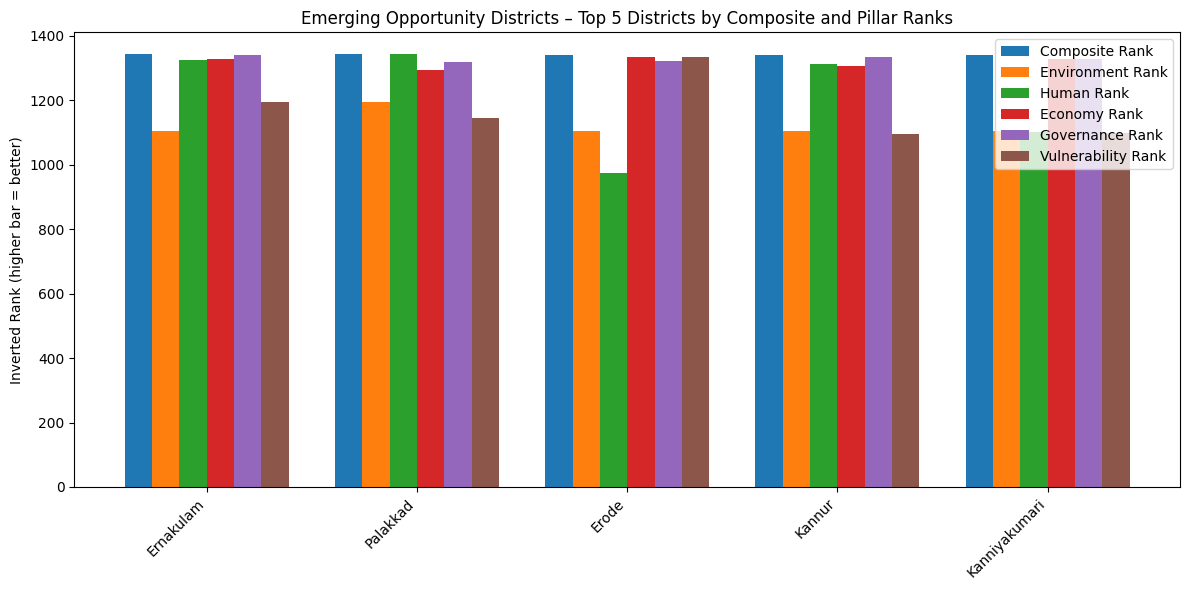

,district_name,Cluster_Name,Rank_Composite,Rank_Env,Rank_Human,Rank_Economy,Rank_Gov,Rank_Vul
361,Ernakulam,Emerging Opportunity Districts,1.0,240.0,19.0,17.0,5.0,150.0
918,Palakkad,Emerging Opportunity Districts,2.0,150.0,1.0,50.0,25.0,200.0
362,Erode,Emerging Opportunity Districts,3.0,240.0,369.0,11.0,22.0,10.0
589,Kannur,Emerging Opportunity Districts,4.0,240.0,33.0,37.0,11.0,250.0
588,Kanniyakumari,Emerging Opportunity Districts,5.0,240.0,244.0,16.0,17.0,245.0


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate ranks for composite and pillar indices
master_df['Rank_Composite'] = master_df['DSRI_Policy_Rank'] # Using policy rank as composite
master_df['Rank_Env'] = master_df['E_Index_norm'].rank(method='dense', ascending=False)
master_df['Rank_Human'] = master_df['Edu_Index_norm'].rank(method='dense', ascending=False)
# Create a combined Economy Index for ranking
master_df['Economy_Index_norm'] = (master_df['L_Index_norm'] + master_df['MSME_Index_norm']) / 2
master_df['Rank_Economy'] = master_df['Economy_Index_norm'].rank(method='dense', ascending=False)
master_df['Rank_Gov'] = master_df['G_Index_norm'].rank(method='dense', ascending=False)
master_df['Rank_Vul'] = master_df['V_Index_norm'].rank(method='dense', ascending=False)

# Filter cluster: Emerging Opportunity Districts
emerging = master_df[master_df['Cluster_Name'] == 'Emerging Opportunity Districts'].copy()

# │ ensure one row per district
emerging = emerging.drop_duplicates(subset='district_name')

# Top 5 by best composite rank
emerging_top5 = emerging.sort_values('Rank_Composite', ascending=True).head(5)

rank_cols = ['Rank_Composite', 'Rank_Env', 'Rank_Human', 'Rank_Economy', 'Rank_Gov', 'Rank_Vul']
max_rank = master_df[rank_cols].max().max()

for col in rank_cols:
    emerging_top5[col + '_plot'] = max_rank + 1 - emerging_top5[col]

x = np.arange(len(emerging_top5))
width = 0.13

plt.figure(figsize=(12,6))
plt.bar(x - 2.5*width, emerging_top5['Rank_Composite_plot'], width, label='Composite Rank')
plt.bar(x - 1.5*width, emerging_top5['Rank_Env_plot'],       width, label='Environment Rank')
plt.bar(x - 0.5*width, emerging_top5['Rank_Human_plot'],     width, label='Human Rank')
plt.bar(x + 0.5*width, emerging_top5['Rank_Economy_plot'],   width, label='Economy Rank')
plt.bar(x + 1.5*width, emerging_top5['Rank_Gov_plot'],       width, label='Governance Rank')
plt.bar(x + 2.5*width, emerging_top5['Rank_Vul_plot'],       width, label='Vulnerability Rank')

plt.xticks(x, emerging_top5['district_name'], rotation=45, ha='right')
plt.ylabel('Inverted Rank (higher bar = better)')
plt.title('Emerging Opportunity Districts – Top 5 Districts by Composite and Pillar Ranks')
plt.legend()
plt.tight_layout()
plt.show()


# ==========================================
# TABLE – Emerging Opportunity Districts (Top 5)
# ==========================================

cols = [
    'district_name',
    'Cluster_Name',
    'Rank_Composite',
    'Rank_Env',
    'Rank_Human',
    'Rank_Economy',
    'Rank_Gov',
    'Rank_Vul'
]

emerging = master_df[master_df['Cluster_Name'] == 'Emerging Opportunity Districts'].copy()

# ensure one row per district
emerging = emerging.drop_duplicates(subset='district_name')

# sort by best composite rank and pick top 5
emerging_top5 = emerging[cols].sort_values('Rank_Composite', ascending=True).head(5)

try:
    display(emerging_top5)
except NameError:
    print(emerging_top5.to_string(index=False))


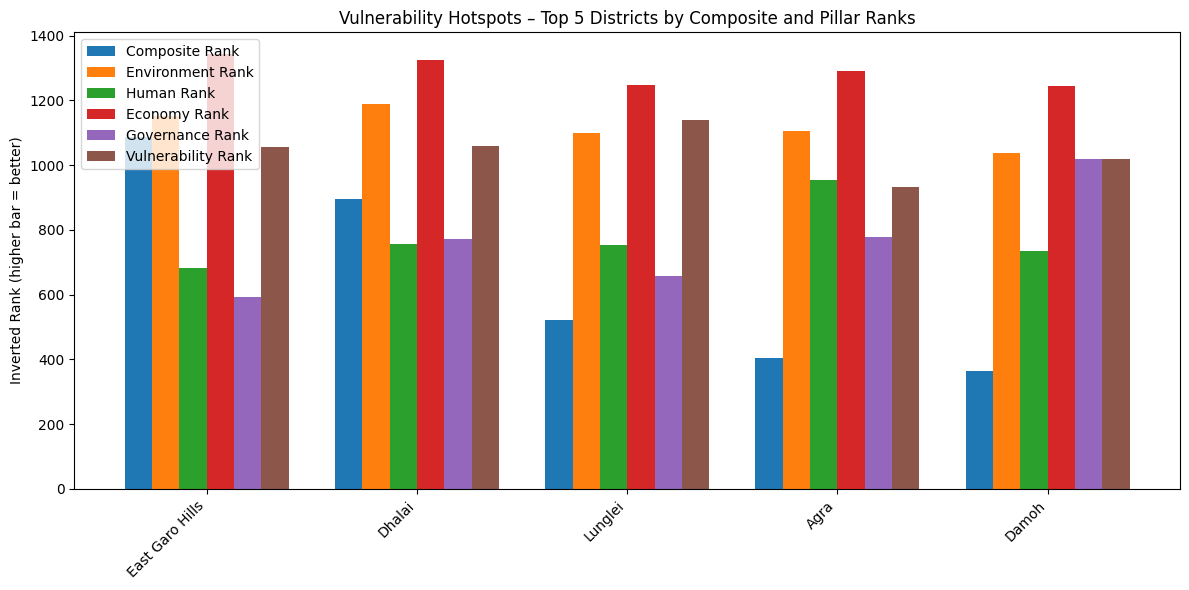

,district_name,Cluster_Name,Rank_Composite,Rank_Env,Rank_Human,Rank_Economy,Rank_Gov,Rank_Vul
349,East Garo Hills,Vulnerability Hotspots,259.0,193.0,664.0,2.0,752.0,290.0
313,Dhalai,Vulnerability Hotspots,449.0,155.0,590.0,20.0,572.0,287.0
741,Lunglei,Vulnerability Hotspots,825.0,247.0,593.0,97.0,689.0,206.0
2,Agra,Vulnerability Hotspots,942.0,240.0,390.0,55.0,568.0,412.0
291,Damoh,Vulnerability Hotspots,980.0,307.0,610.0,100.0,325.0,327.0


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Filter cluster: Vulnerability Hotspots
hotspots = master_df[master_df['Cluster_Name'] == 'Vulnerability Hotspots'].copy()

# 🔹 ensure one row per district
hotspots = hotspots.drop_duplicates(subset='district_name')

# Top 5 by best composite rank in this cluster
hotspots_top5 = hotspots.sort_values('Rank_Composite', ascending=True).head(5)

rank_cols = ['Rank_Composite', 'Rank_Env', 'Rank_Human', 'Rank_Economy', 'Rank_Gov', 'Rank_Vul']
max_rank = master_df[rank_cols].max().max()

for col in rank_cols:
    hotspots_top5[col + '_plot'] = max_rank + 1 - hotspots_top5[col]

x = np.arange(len(hotspots_top5))
width = 0.13

plt.figure(figsize=(12,6))
plt.bar(x - 2.5*width, hotspots_top5['Rank_Composite_plot'], width, label='Composite Rank')
plt.bar(x - 1.5*width, hotspots_top5['Rank_Env_plot'],       width, label='Environment Rank')
plt.bar(x - 0.5*width, hotspots_top5['Rank_Human_plot'],     width, label='Human Rank')
plt.bar(x + 0.5*width, hotspots_top5['Rank_Economy_plot'],   width, label='Economy Rank')
plt.bar(x + 1.5*width, hotspots_top5['Rank_Gov_plot'],       width, label='Governance Rank')
plt.bar(x + 2.5*width, hotspots_top5['Rank_Vul_plot'],       width, label='Vulnerability Rank')

plt.xticks(x, hotspots_top5['district_name'], rotation=45, ha='right')
plt.ylabel('Inverted Rank (higher bar = better)')
plt.title('Vulnerability Hotspots – Top 5 Districts by Composite and Pillar Ranks')
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# TABLE – Vulnerability Hotspots (Top 5)
# ==========================================

cols = [
    'district_name',
    'Cluster_Name',
    'Rank_Composite',
    'Rank_Env',
    'Rank_Human',
    'Rank_Economy',
    'Rank_Gov',
    'Rank_Vul'
]

hotspots = master_df[master_df['Cluster_Name'] == 'Vulnerability Hotspots'].copy()

# ensure one row per district
hotspots = hotspots.drop_duplicates(subset='district_name')

# sort by best composite rank and pick top 5
hotspots_top5 = hotspots[cols].sort_values('Rank_Composite', ascending=True).head(5)

try:
    display(hotspots_top5)
except NameError:
    print(hotspots_top5.to_string(index=False))



In [ ]:
# ================================================================
# TABLES: TOP 5 DISTRICTS PER NAMED CLUSTER (DEDUPED BY DISTRICT)
# ================================================================

# Make sure these exist already:
# - Cluster_Name
# - Rank_Composite, Rank_Env, Rank_Human, Rank_Economy, Rank_Gov, Rank_Vul

selected_cols = [
    'district_name',
    'Cluster_Name',
    'Rank_Composite',
    'Rank_Env',
    'Rank_Human',
    'Rank_Economy',
    'Rank_Gov',
    'Rank_Vul'
]

# Optional: set a logical order for clusters
cluster_order = ['Resilience Leaders', 'Emerging Opportunity Districts', 'Vulnerability Hotspots']

for cname in cluster_order:
    if cname not in master_df['Cluster_Name'].unique():
        continue  # skip if cluster not present

    print(f"\n================ {cname.upper()} ================\n")

    # filter cluster and ensure one row per district
    cluster_df = master_df[master_df['Cluster_Name'] == cname].copy()
    cluster_df = cluster_df.drop_duplicates(subset='district_name')

    # sort by best composite rank and take top 5
    top5 = (
        cluster_df[selected_cols]
        .sort_values('Rank_Composite', ascending=True)
        .head(5)
    )

    # if using Jupyter/Colab
    try:
        display(top5)
    except NameError:
        # fallback for plain Python
        print(top5.to_string(index=False))



================ RESILIENCE LEADERS ================



,district_name,Cluster_Name,Rank_Composite,Rank_Env,Rank_Human,Rank_Economy,Rank_Gov,Rank_Vul
288,Dakshina Kannada,Resilience Leaders,7.0,6.0,201.0,445.0,145.0,5.0
672,Koraput,Resilience Leaders,12.0,10.0,42.0,52.0,194.0,311.0
1314,Virudhunagar,Resilience Leaders,14.0,28.0,316.0,45.0,52.0,20.0
954,Pauri Garhwal,Resilience Leaders,15.0,1.0,369.0,488.0,356.0,341.0
1325,Washim,Resilience Leaders,20.0,4.0,436.0,375.0,168.0,100.0



================ EMERGING OPPORTUNITY DISTRICTS ================



,district_name,Cluster_Name,Rank_Composite,Rank_Env,Rank_Human,Rank_Economy,Rank_Gov,Rank_Vul
361,Ernakulam,Emerging Opportunity Districts,1.0,240.0,19.0,17.0,5.0,150.0
918,Palakkad,Emerging Opportunity Districts,2.0,150.0,1.0,50.0,25.0,200.0
362,Erode,Emerging Opportunity Districts,3.0,240.0,369.0,11.0,22.0,10.0
589,Kannur,Emerging Opportunity Districts,4.0,240.0,33.0,37.0,11.0,250.0
588,Kanniyakumari,Emerging Opportunity Districts,5.0,240.0,244.0,16.0,17.0,245.0



================ VULNERABILITY HOTSPOTS ================



,district_name,Cluster_Name,Rank_Composite,Rank_Env,Rank_Human,Rank_Economy,Rank_Gov,Rank_Vul
349,East Garo Hills,Vulnerability Hotspots,259.0,193.0,664.0,2.0,752.0,290.0
313,Dhalai,Vulnerability Hotspots,449.0,155.0,590.0,20.0,572.0,287.0
741,Lunglei,Vulnerability Hotspots,825.0,247.0,593.0,97.0,689.0,206.0
2,Agra,Vulnerability Hotspots,942.0,240.0,390.0,55.0,568.0,412.0
291,Damoh,Vulnerability Hotspots,980.0,307.0,610.0,100.0,325.0,327.0


In [ ]:
import pandas as pd
from google.colab import files

# Columns to include in export
export_cols = [
    'district_name',
    'DSRI_Policy_Index',
    'E_Index_norm',
    'Edu_Index_norm',
    'L_Index_norm',
    'MSME_Index_norm',
    'H_Index_norm',
    'V_Index_norm',
    'G_Index_norm'
]

# Create export dataframe
df_export = master_df[export_cols].drop_duplicates(subset='district_name')

# Save Excel file
file_name = "DSRI_Final_Scores.xlsx"
df_export.to_excel(file_name, index=False)

# Generate download link
files.download(file_name)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==============================
# 1) IMPORT MASTER SHEET
# ==============================

master_map_path = "/content/drive/MyDrive/Colab Notebooks/District_Masters.xlsx"   # <-- paste your path here

state_dist_df = pd.read_excel(master_map_path)




In [ ]:
state_dist_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5606 entries, 0 to 5605
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   State Name     5606 non-null   object
 1   District Name  5606 non-null   object
dtypes: object(2)
memory usage: 87.7+ KB


In [ ]:
# Keep only relevant columns (exact as your file)
state_dist_df = state_dist_df[['State Name', 'District Name']].copy()

# Clean
state_dist_df['State Name'] = state_dist_df['State Name'].astype(str).str.strip().str.title()
state_dist_df['District Name'] = state_dist_df['District Name'].astype(str).str.strip().str.title()

# Drop duplicates
state_dist_df = state_dist_df.drop_duplicates(subset=['State Name', 'District Name'])

print("✅ Mapping rows:", state_dist_df.shape)
state_dist_df.head()

✅ Mapping rows: (1265, 2)


,State Name,District Name
0,Andaman & Nicobar Islands,Nicobars
1,Andaman & Nicobar Islands,North And Middle Andaman
2,Andaman & Nicobar Islands,South Andaman
3,Andhra Pradesh,Anantapur
4,Andhra Pradesh,Chittoor


In [ ]:
# ==============================
# 2) MERGE STATE INTO master_df
# ==============================

# Clean district in master_df
master_df['district_name'] = master_df['district_name'].astype(str).str.strip().str.title()

# Merge on district name
master_df = master_df.merge(
    state_dist_df,
    left_on='district_name',
    right_on='District Name',
    how='left'
)

print("✅ Master df after merge:", master_df.shape)
print("❌ Missing State Name count:", master_df['State Name'].isna().sum())

# Show unmatched districts (if any)
unmatched = master_df[master_df['State Name'].isna()][['district_name']].drop_duplicates()
print("\nUnmatched districts (first 20):")
print(unmatched.head(20))


✅ Master df after merge: (1707, 30)
❌ Missing State Name count: 64

Unmatched districts (first 20):
                           district_name
23                       Ambedakar Nagar
28   Amethi(Chhatrapati Shahuji Maharaj)
34           Amroha(Jyotiba Phule Nagar)
39                            Ananthapur
58                           Ashok Nagar
117                          Balod Bazar
157                            Bardhaman
180                    Bengaluru (Rural)
181                    Bengaluru (Urban)
279                         Bulandshahar
294                        Chamarajnagar
326                         Chikballapur
333                              Chitoor
372              Dadra And Nagar Havelli
374            Dakshin Baster\nDantewada
376                       Dakshin Kannad
429                        District Name
454                       East Medinipur
456                          East Sikkim
457                       East Singhbhum


In [ ]:
# ===========================================================
# FUZZY MATCH FUNCTION (rapidfuzz preferred)
# ===========================================================

try:
    from rapidfuzz import process, fuzz
    USE_RAPIDFUZZ = True
except ImportError:
    import difflib
    USE_RAPIDFUZZ = False


def clean_name(x):
    """Standardize district names for matching."""
    if pd.isna(x):
        return ""
    x = str(x).strip().lower()
    x = x.replace("&", "and")
    x = x.replace(".", "")
    x = x.replace("-", " ")
    x = " ".join(x.split())
    return x


def fuzzy_match_one(query, choices, threshold=90):
    """
    Returns best match and score.
    If score below threshold, returns (None, score).
    """
    if query == "" or query is None:
        return None, 0

    if USE_RAPIDFUZZ:
        match = process.extractOne(query, choices, scorer=fuzz.WRatio)
        if match is None:
            return None, 0
        best_choice, score, _ = match
        if score >= threshold:
            return best_choice, score
        else:
            return None, score

    else:
        # difflib fallback
        best = difflib.get_close_matches(query, choices, n=1, cutoff=threshold/100)
        if len(best) == 0:
            return None, 0
        return best[0], int(threshold)


# ===========================================================
# 1) PREPARE DISTRICT LISTS
# ===========================================================

# Clean district names in both dfs
master_df['district_clean'] = master_df['district_name'].apply(clean_name)
state_dist_df['district_clean'] = state_dist_df['District Name'].apply(clean_name)

# Create lookup mapping district_clean -> state
district_to_state = dict(zip(state_dist_df['district_clean'], state_dist_df['State Name']))

# choices list for fuzzy matching
choices = state_dist_df['district_clean'].dropna().unique().tolist()

# ===========================================================
# 2) FIND MISSING STATE ROWS
# ===========================================================

missing_mask = master_df['State Name'].isna()
missing_df = master_df.loc[missing_mask, ['district_name', 'district_clean']].drop_duplicates()

print("✅ Missing districts count:", missing_df.shape[0])

# ===========================================================
# 3) FUZZY MATCH ONLY FOR MISSING DISTRICTS
# ===========================================================

results = []

THRESHOLD = 90  # adjust 85–92 based on quality you want

for _, row in missing_df.iterrows():
    query = row['district_clean']
    best_match, score = fuzzy_match_one(query, choices, threshold=THRESHOLD)

    if best_match is not None:
        matched_state = district_to_state.get(best_match)
        matched_district_original = state_dist_df.loc[
            state_dist_df['district_clean'] == best_match, 'District Name'
        ].iloc[0]

        results.append({
            'district_name_missing': row['district_name'],
            'matched_district': matched_district_original,
            'matched_state': matched_state,
            'match_score': score
        })
    else:
        results.append({
            'district_name_missing': row['district_name'],
            'matched_district': None,
            'matched_state': None,
            'match_score': score
        })

match_df = pd.DataFrame(results)

print("\n✅ Matches found:", match_df['matched_state'].notna().sum())
print("❌ Still unmatched:", match_df['matched_state'].isna().sum())

# Inspect uncertain matches (score < threshold)
print("\n⚠️ Low quality matches (below threshold):")
print(match_df[match_df['matched_state'].isna()].head(20))

✅ Missing districts count: 64

✅ Matches found: 37
❌ Still unmatched: 27

⚠️ Low quality matches (below threshold):
                  district_name_missing matched_district matched_state  \
1   Amethi(Chhatrapati Shahuji Maharaj)             None          None   
2           Amroha(Jyotiba Phule Nagar)             None          None   
8                     Bengaluru (Urban)             None          None   
11                         Chikballapur             None          None   
16                        District Name             None          None   
17                       East Medinipur             None          None   
18                          East Sikkim             None          None   
20                            Ferozepur             None          None   
25            Kasganj(Kanshi Ram Nagar)             None          None   
26                       Khandwa (E.N.)             None          None   
28                    Khargaone (W.N..)             None          None

In [ ]:
# ===========================================================
# 4) FILL MISSING STATE NAME IN master_df
# ===========================================================

# Create dictionary missing district -> matched state
fill_state_map = dict(zip(match_df['district_name_missing'], match_df['matched_state']))

# Fill State Name only where missing
master_df['State Name'] = master_df.apply(
    lambda r: fill_state_map.get(r['district_name'], r['State Name']) if pd.isna(r['State Name']) else r['State Name'],
    axis=1
)

# Optional: store matching diagnostics
match_score_map = dict(zip(match_df['district_name_missing'], match_df['match_score']))
master_df['state_match_score'] = master_df.apply(
    lambda r: match_score_map.get(r['district_name'], np.nan) if pd.isna(r['State Name']) else np.nan,
    axis=1
)

print("\n✅ Missing State Name after fuzzy fill:", master_df['State Name'].isna().sum())



✅ Missing State Name after fuzzy fill: 27


In [ ]:
match_df_sorted = match_df.sort_values('match_score', ascending=False)
match_df_sorted.to_excel("district_state_fuzzy_matches.xlsx", index=False)

print("✅ Exported fuzzy match audit file: district_state_fuzzy_matches.xlsx")

✅ Exported fuzzy match audit file: district_state_fuzzy_matches.xlsx


In [ ]:
# ==========================================================
# 3) CREATE STATE-WISE DATASET (AGGREGATION)
# ==========================================================

# ✅ indices available in master_df (district-level)
index_cols = [
    'DSRI_Policy_Index',
    'DSRI_PCA_Index',        # include if you created PCA index
    'E_Index_norm',
    'Edu_Index_norm',
    'L_Index_norm',
    'MSME_Index_norm',
    'H_Index_norm',
    'V_Index_norm',
    'G_Index_norm'
]

# Keep only valid rows with state information
state_work_df = master_df.dropna(subset=['State Name']).copy()

# Aggregate district values to State level
# (mean across districts; simple & standard)
state_df = (
    state_work_df
    .groupby('State Name')[index_cols]
    .mean()
    .reset_index()
)

print("✅ State-level aggregated dataset shape:", state_df.shape)
state_df.head()


✅ State-level aggregated dataset shape: (51, 10)


,State Name,DSRI_Policy_Index,DSRI_PCA_Index,E_Index_norm,Edu_Index_norm,L_Index_norm,MSME_Index_norm,H_Index_norm,V_Index_norm,G_Index_norm
0,Andaman & \nNicobar Island,0.409580,0.564506,0.259829,0.733983,0.177923,0.105869,0.608116,0.651787,0.449494
1,Andaman & Nicobar Islands,0.419601,0.581110,0.259829,0.781134,0.186254,0.100185,0.631184,0.588486,0.496697
2,Andaman And Nicobar,0.402742,0.576165,0.259829,0.762863,0.109527,0.097580,0.633557,0.618345,0.478152
3,Andhra Pradesh,0.468795,0.603112,0.259460,0.756791,0.386959,0.118315,0.648507,0.616582,0.552268
4,Arunachal Pradesh,0.395523,0.466964,0.274692,0.631912,0.333922,0.104099,0.547445,0.641692,0.223177


In [ ]:
# ==========================================================
# 4) STATE RANKING (Policy + PCA)
# ==========================================================

# Policy Rank
state_df['State_Rank_DSRI_Policy'] = state_df['DSRI_Policy_Index'].rank(
    method='dense',
    ascending=False
)

# PCA Rank (only if PCA exists)
if 'DSRI_PCA_Index' in state_df.columns:
    state_df['State_Rank_DSRI_PCA'] = state_df['DSRI_PCA_Index'].rank(
        method='dense',
        ascending=False
    )

# sort by policy rank
state_df = state_df.sort_values('State_Rank_DSRI_Policy')

print("\n✅ Top 10 states by DSRI_Policy:")
state_df[['State Name', 'DSRI_Policy_Index', 'State_Rank_DSRI_Policy']].head(10)



✅ Top 10 states by DSRI_Policy:


,State Name,DSRI_Policy_Index,State_Rank_DSRI_Policy
7,Chandigarh,0.588120,1.0
27,Kerala,0.562239,2.0
43,Tamilnadu,0.527355,3.0
42,Tamil Nadu,0.514743,4.0
12,Daman & Diu,0.500587,5.0
13,Daman And Diu,0.500587,5.0
18,Gujrat,0.489695,6.0
36,Nct Of Delhi,0.484555,7.0
17,Gujarat,0.483322,8.0
34,Mizoram,0.480101,9.0


In [ ]:
# ==========================================================
# 5) STATE CLUSTERING (USING 7 SUB-INDICES)
# ==========================================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = [
    'E_Index_norm',
    'Edu_Index_norm',
    'L_Index_norm',
    'MSME_Index_norm',
    'H_Index_norm',
    'V_Index_norm',
    'G_Index_norm'
]

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(state_df[cluster_features])

# KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
state_df['State_Cluster_raw'] = kmeans.fit_predict(X)

# Reorder clusters by average DSRI_Policy_Index (0 = best cluster)
cluster_order = (
    state_df.groupby('State_Cluster_raw')['DSRI_Policy_Index']
    .mean()
    .sort_values(ascending=False)
    .index
)

cluster_map = {old: new for new, old in enumerate(cluster_order)}
state_df['State_Cluster'] = state_df['State_Cluster_raw'].map(cluster_map)

# Name clusters
cluster_names = {
    0: "Resilience Leader States",
    1: "Emerging Opportunity States",
    2: "Vulnerability Hotspot States"
}
state_df['State_Cluster_Name'] = state_df['State_Cluster'].map(cluster_names)

print("\n✅ Cluster Summary (Average DSRI_Policy):")
print(
    state_df.groupby('State_Cluster_Name')['DSRI_Policy_Index']
    .mean()
    .sort_values(ascending=False)
    .round(3)
)



✅ Cluster Summary (Average DSRI_Policy):
State_Cluster_Name
Resilience Leader States        0.515
Emerging Opportunity States     0.452
Vulnerability Hotspot States    0.393
Name: DSRI_Policy_Index, dtype: float64


In [ ]:
# ==========================================================
# 6) TOP 5 STATES PER CLUSTER
# ==========================================================

display_cols = [
    'State Name',
    'DSRI_Policy_Index',
    'E_Index_norm',
    'Edu_Index_norm',
    'L_Index_norm',
    'MSME_Index_norm',
    'H_Index_norm',
    'V_Index_norm',
    'G_Index_norm',
    'State_Cluster_Name'
]

cluster_order_names = [
    "Resilience Leader States",
    "Emerging Opportunity States",
    "Vulnerability Hotspot States"
]

for cname in cluster_order_names:
    print(f"\n================ {cname.upper()} ================")

    top5 = (
        state_df[state_df['State_Cluster_Name'] == cname]
        .sort_values('DSRI_Policy_Index', ascending=False)
        .head(5)
    )

    try:
        display(top5[display_cols])
    except NameError:
        print(top5[display_cols].to_string(index=False))



================ RESILIENCE LEADER STATES ================


,State Name,DSRI_Policy_Index,E_Index_norm,Edu_Index_norm,L_Index_norm,MSME_Index_norm,H_Index_norm,V_Index_norm,G_Index_norm,State_Cluster_Name
7,Chandigarh,0.588120,0.259829,0.971020,0.378073,0.124869,0.798435,0.843468,0.982871,Resilience Leader States
27,Kerala,0.562239,0.266325,0.909017,0.420257,0.111011,0.901431,0.590483,0.832059,Resilience Leader States
43,Tamilnadu,0.527355,0.301508,0.819239,0.419337,0.137574,0.670841,0.702580,0.756592,Resilience Leader States
42,Tamil Nadu,0.514743,0.286929,0.762120,0.417397,0.149618,0.684048,0.680447,0.739462,Resilience Leader States
18,Gujrat,0.489695,0.251767,0.785134,0.361315,0.184343,0.657140,0.635409,0.687621,Resilience Leader States



================ EMERGING OPPORTUNITY STATES ================


,State Name,DSRI_Policy_Index,E_Index_norm,Edu_Index_norm,L_Index_norm,MSME_Index_norm,H_Index_norm,V_Index_norm,G_Index_norm,State_Cluster_Name
12,Daman & Diu,0.500587,0.259829,0.733983,0.378073,0.104725,0.886539,0.745060,0.449494,Emerging Opportunity States
13,Daman And Diu,0.500587,0.259829,0.733983,0.378073,0.104725,0.886539,0.745060,0.449494,Emerging Opportunity States
34,Mizoram,0.480101,0.283128,0.685972,0.580541,0.092270,0.633579,0.691269,0.310802,Emerging Opportunity States
39,Punjab,0.479589,0.259344,0.750567,0.395153,0.111908,0.673884,0.576616,0.661693,Emerging Opportunity States
14,Delhi,0.475202,0.259829,0.806973,0.378073,0.111622,0.624303,0.595781,0.621902,Emerging Opportunity States



================ VULNERABILITY HOTSPOT STATES ================


,State Name,DSRI_Policy_Index,E_Index_norm,Edu_Index_norm,L_Index_norm,MSME_Index_norm,H_Index_norm,V_Index_norm,G_Index_norm,State_Cluster_Name
26,Karnataka,0.462835,0.350314,0.704767,0.378026,0.108636,0.616888,0.626423,0.454130,Vulnerability Hotspot States
40,Rajasthan,0.424514,0.270970,0.708831,0.380315,0.117136,0.555625,0.510718,0.418034,Vulnerability Hotspot States
30,Madhya Pradesh,0.414209,0.261847,0.687400,0.383333,0.126963,0.509068,0.533255,0.396810,Vulnerability Hotspot States
25,Jharkhand,0.404945,0.275779,0.691929,0.366515,0.107699,0.572613,0.388447,0.371902,Vulnerability Hotspot States
46,Ut Of Jammu And Kashmir,0.398829,0.272192,0.708752,0.262160,0.106416,0.674738,0.340031,0.397901,Vulnerability Hotspot States


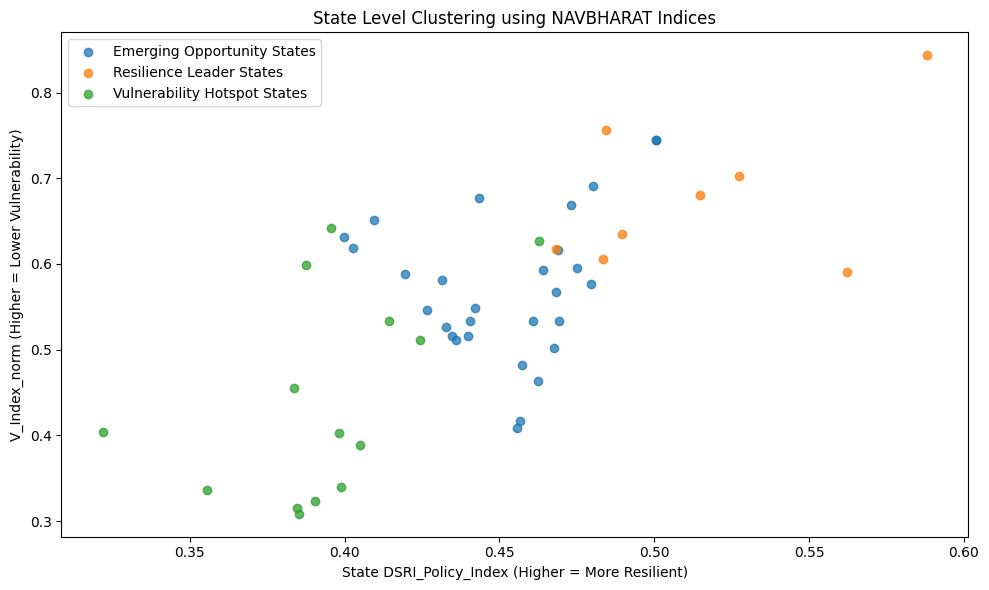

In [ ]:
# ==========================================================
# 7) OPTIONAL: STATE CLUSTER SCATTER PLOT
# ==========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for cname, sub in state_df.groupby('State_Cluster_Name'):
    plt.scatter(
        sub['DSRI_Policy_Index'],
        sub['V_Index_norm'],
        label=cname,
        alpha=0.75
    )

plt.xlabel("State DSRI_Policy_Index (Higher = More Resilient)")
plt.ylabel("V_Index_norm (Higher = Lower Vulnerability)")
plt.title("State Level Clustering using NAVBHARAT Indices")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:


# ---------------------------------------
# Helper: safe column existence checker
# ---------------------------------------
def ensure_cols(df, cols, df_name="df"):
    missing = [c for c in cols if c not in df.columns]
    if missing:
        raise ValueError(f"❌ Missing columns in {df_name}: {missing}")

# ---------------------------------------
# If you have duplicates per district/state
# keep only 1 record (best practice)
# ---------------------------------------
master_df_clean = master_df.drop_duplicates(subset=['district_name']).copy()

# ============================================================
# 1) DISTRICT FILE: District + all 7 Index Scores
# ============================================================
district_7index_cols = [
    'district_name',
    'E_Index_norm',
    'Edu_Index_norm',
    'L_Index_norm',
    'MSME_Index_norm',
    'H_Index_norm',
    'V_Index_norm',
    'G_Index_norm'
]
ensure_cols(master_df_clean, district_7index_cols, "master_df")

district_7index_df = master_df_clean[district_7index_cols].copy()
district_7index_file = "1_District_All_7_Indices.xlsx"
district_7index_df.to_excel(district_7index_file, index=False)


# ============================================================
# 2) DISTRICT FILE: District + Vulnerability + Composite Score
# ============================================================
district_vul_comp_cols = [
    'district_name',
    'V_Index_norm',
    'DSRI_Policy_Index'
]
ensure_cols(master_df_clean, district_vul_comp_cols, "master_df")

district_vul_comp_df = master_df_clean[district_vul_comp_cols].copy()
district_vul_comp_file = "2_District_Vulnerability_and_Composite.xlsx"
district_vul_comp_df.to_excel(district_vul_comp_file, index=False)


# ============================================================
# 3) DISTRICT FILE: District + Cluster Info
# ============================================================
district_cluster_cols = [
    'district_name',
    'Cluster_Name'
]
ensure_cols(master_df_clean, district_cluster_cols, "master_df")

district_cluster_df = master_df_clean[district_cluster_cols].copy()
district_cluster_file = "3_District_Clusters.xlsx"
district_cluster_df.to_excel(district_cluster_file, index=False)


# ============================================================
# 4) DISTRICT FILE: District + Cluster + the indices used for clustering
# (pillar basis indices or raw indices)
# ============================================================
district_cluster_basis_cols = [
    'district_name',
    'Cluster_Name',
    'E_Index_norm',
    'Edu_Index_norm',
    'L_Index_norm',
    'MSME_Index_norm',
    'H_Index_norm',
    'V_Index_norm',
    'G_Index_norm',
    'DSRI_Policy_Index'
]
ensure_cols(master_df_clean, district_cluster_basis_cols, "master_df")

district_cluster_basis_df = master_df_clean[district_cluster_basis_cols].copy()
district_cluster_basis_file = "4_District_Clusters_with_Indices.xlsx"
district_cluster_basis_df.to_excel(district_cluster_basis_file, index=False)


# ============================================================
# Ensure state_df exists (from your aggregation step)
# (If not, we create it quickly from master_df + State Name)
# ============================================================
if 'state_df' not in globals():
    # minimal state aggregation creation
    ensure_cols(master_df, ['State Name'], "master_df")
    state_work_df = master_df.dropna(subset=['State Name']).copy()

    state_index_cols = [
        'DSRI_Policy_Index',
        'E_Index_norm',
        'Edu_Index_norm',
        'L_Index_norm',
        'MSME_Index_norm',
        'H_Index_norm',
        'V_Index_norm',
        'G_Index_norm'
    ]
    ensure_cols(state_work_df, state_index_cols, "master_df")

    state_df = (
        state_work_df
        .groupby('State Name')[state_index_cols]
        .mean()
        .reset_index()
    )

# state_df should already have cluster columns after clustering:
# State_Cluster_Name, etc.
# We'll export even if cluster columns absent (handled below)


# ============================================================
# 5) STATE FILE: State + all 7 Index Scores
# ============================================================
state_7index_cols = [
    'State Name',
    'E_Index_norm',
    'Edu_Index_norm',
    'L_Index_norm',
    'MSME_Index_norm',
    'H_Index_norm',
    'V_Index_norm',
    'G_Index_norm'
]
ensure_cols(state_df, state_7index_cols, "state_df")

state_7index_df = state_df[state_7index_cols].copy()
state_7index_file = "5_State_All_7_Indices.xlsx"
state_7index_df.to_excel(state_7index_file, index=False)


# ============================================================
# 6) STATE FILE: State + Composite Score
# ============================================================
state_comp_cols = ['State Name', 'DSRI_Policy_Index']
ensure_cols(state_df, state_comp_cols, "state_df")

state_comp_df = state_df[state_comp_cols].copy()
state_comp_file = "6_State_Composite_Score.xlsx"
state_comp_df.to_excel(state_comp_file, index=False)


# ============================================================
# 7) STATE FILE: State + Cluster + indices used for clustering
# ============================================================
# If clusters not present, only export indices + composite
state_cluster_basis_cols = [
    'State Name',
    'DSRI_Policy_Index',
    'E_Index_norm',
    'Edu_Index_norm',
    'L_Index_norm',
    'MSME_Index_norm',
    'H_Index_norm',
    'V_Index_norm',
    'G_Index_norm'
]

cluster_state_cols_optional = []
if 'State_Cluster_Name' in state_df.columns:
    cluster_state_cols_optional.append('State_Cluster_Name')
if 'State_Cluster' in state_df.columns:
    cluster_state_cols_optional.append('State_Cluster')

final_state_cols = ['State Name'] + cluster_state_cols_optional + [
    'DSRI_Policy_Index',
    'E_Index_norm','Edu_Index_norm','L_Index_norm','MSME_Index_norm','H_Index_norm','V_Index_norm','G_Index_norm'
]

ensure_cols(state_df, ['State Name','DSRI_Policy_Index'], "state_df")
state_cluster_basis_df = state_df[final_state_cols].copy()

state_cluster_basis_file = "7_State_Clusters_with_Indices.xlsx"
state_cluster_basis_df.to_excel(state_cluster_basis_file, index=False)


print("✅ All Excel files generated successfully!")
print("Files created:")
for f in [
    district_7index_file,
    district_vul_comp_file,
    district_cluster_file,
    district_cluster_basis_file,
    state_7index_file,
    state_comp_file,
    state_cluster_basis_file
]:
    print(" -", f)


✅ All Excel files generated successfully!
Files created:
 - 1_District_All_7_Indices.xlsx
 - 2_District_Vulnerability_and_Composite.xlsx
 - 3_District_Clusters.xlsx
 - 4_District_Clusters_with_Indices.xlsx
 - 5_State_All_7_Indices.xlsx
 - 6_State_Composite_Score.xlsx
 - 7_State_Clusters_with_Indices.xlsx


In [ ]:
from google.colab import files

files_to_download = [
    "1_District_All_7_Indices.xlsx",
    "2_District_Vulnerability_and_Composite.xlsx",
    "3_District_Clusters.xlsx",
    "4_District_Clusters_with_Indices.xlsx",
    "5_State_All_7_Indices.xlsx",
    "6_State_Composite_Score.xlsx",
    "7_State_Clusters_with_Indices.xlsx"
]

for f in files_to_download:
    files.download(f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================================================
# DISTRICT CLUSTER FILES WITH ALL RANKINGS
# =========================================================

district_df = master_df.drop_duplicates(subset=['district_name']).copy()

# ---- Create pillar ranks (higher score => better rank 1)
district_df['Rank_Composite'] = district_df['DSRI_Policy_Index'].rank(method='dense', ascending=False)

district_df['Rank_Env']    = district_df['E_Index_norm'].rank(method='dense', ascending=False)
district_df['Rank_Edu']    = district_df['Edu_Index_norm'].rank(method='dense', ascending=False)
district_df['Rank_Live']   = district_df['L_Index_norm'].rank(method='dense', ascending=False)
district_df['Rank_MSME']   = district_df['MSME_Index_norm'].rank(method='dense', ascending=False)
district_df['Rank_Health'] = district_df['H_Index_norm'].rank(method='dense', ascending=False)
district_df['Rank_Vul']    = district_df['V_Index_norm'].rank(method='dense', ascending=False)
district_df['Rank_Gov']    = district_df['G_Index_norm'].rank(method='dense', ascending=False)

# ---- Within-cluster rank based on Composite score (best inside cluster = 1)
district_df['Rank_Within_Cluster'] = (
    district_df.groupby('Cluster_Name')['DSRI_Policy_Index']
    .rank(method='dense', ascending=False)
)

# =========================================================
# DISTRICT FILE 1: Cluster + all ranks only
# =========================================================
district_cluster_ranks_cols = [
    'district_name', 'Cluster_Name',
    'Rank_Composite', 'Rank_Env', 'Rank_Edu', 'Rank_Live',
    'Rank_MSME', 'Rank_Health', 'Rank_Vul', 'Rank_Gov'
]
district_cluster_ranks_file = "8_District_Clusters_AllRanks.xlsx"
district_df[district_cluster_ranks_cols].to_excel(district_cluster_ranks_file, index=False)

# =========================================================
# DISTRICT FILE 2: Cluster + within-cluster rank only
# =========================================================
district_cluster_within_cols = [
    'district_name', 'Cluster_Name', 'Rank_Within_Cluster'
]
district_cluster_within_file = "9_District_Clusters_WithinClusterRank.xlsx"
district_df[district_cluster_within_cols].to_excel(district_cluster_within_file, index=False)

# =========================================================
# DISTRICT FILE 3: Cluster + scores + all ranks + within-cluster rank
# =========================================================
district_cluster_full_cols = [
    'district_name', 'Cluster_Name',
    'DSRI_Policy_Index',
    'E_Index_norm', 'Edu_Index_norm', 'L_Index_norm', 'MSME_Index_norm',
    'H_Index_norm', 'V_Index_norm', 'G_Index_norm',
    'Rank_Composite', 'Rank_Env', 'Rank_Edu', 'Rank_Live',
    'Rank_MSME', 'Rank_Health', 'Rank_Vul', 'Rank_Gov',
    'Rank_Within_Cluster'
]
district_cluster_full_file = "10_District_Clusters_FullProfile.xlsx"
district_df[district_cluster_full_cols].to_excel(district_cluster_full_file, index=False)

print("✅ District cluster ranking files generated!")


✅ District cluster ranking files generated!


In [ ]:
# =========================================================
# STATE CLUSTER FILES WITH ALL RANKINGS
# =========================================================

state_df_clean = state_df.drop_duplicates(subset=['State Name']).copy()

# ---- State ranks
state_df_clean['Rank_Composite'] = state_df_clean['DSRI_Policy_Index'].rank(method='dense', ascending=False)

state_df_clean['Rank_Env']    = state_df_clean['E_Index_norm'].rank(method='dense', ascending=False)
state_df_clean['Rank_Edu']    = state_df_clean['Edu_Index_norm'].rank(method='dense', ascending=False)
state_df_clean['Rank_Live']   = state_df_clean['L_Index_norm'].rank(method='dense', ascending=False)
state_df_clean['Rank_MSME']   = state_df_clean['MSME_Index_norm'].rank(method='dense', ascending=False)
state_df_clean['Rank_Health'] = state_df_clean['H_Index_norm'].rank(method='dense', ascending=False)
state_df_clean['Rank_Vul']    = state_df_clean['V_Index_norm'].rank(method='dense', ascending=False)
state_df_clean['Rank_Gov']    = state_df_clean['G_Index_norm'].rank(method='dense', ascending=False)

# ---- Within-cluster rank
cluster_state_col = "State_Cluster_Name" if "State_Cluster_Name" in state_df_clean.columns else "State_Cluster"
state_df_clean['Rank_Within_Cluster'] = (
    state_df_clean.groupby(cluster_state_col)['DSRI_Policy_Index']
    .rank(method='dense', ascending=False)
)

# =========================================================
# STATE FILE 1: Cluster + all ranks only
# =========================================================
state_cluster_ranks_cols = [
    'State Name', cluster_state_col,
    'Rank_Composite', 'Rank_Env', 'Rank_Edu', 'Rank_Live',
    'Rank_MSME', 'Rank_Health', 'Rank_Vul', 'Rank_Gov'
]
state_cluster_ranks_file = "11_State_Clusters_AllRanks.xlsx"
state_df_clean[state_cluster_ranks_cols].to_excel(state_cluster_ranks_file, index=False)

# =========================================================
# STATE FILE 2: Cluster + within-cluster rank only
# =========================================================
state_cluster_within_cols = [
    'State Name', cluster_state_col, 'Rank_Within_Cluster'
]
state_cluster_within_file = "12_State_Clusters_WithinClusterRank.xlsx"
state_df_clean[state_cluster_within_cols].to_excel(state_cluster_within_file, index=False)

# =========================================================
# STATE FILE 3: Cluster + scores + all ranks + within cluster rank
# =========================================================
state_cluster_full_cols = [
    'State Name', cluster_state_col,
    'DSRI_Policy_Index',
    'E_Index_norm', 'Edu_Index_norm', 'L_Index_norm', 'MSME_Index_norm',
    'H_Index_norm', 'V_Index_norm', 'G_Index_norm',
    'Rank_Composite', 'Rank_Env', 'Rank_Edu', 'Rank_Live',
    'Rank_MSME', 'Rank_Health', 'Rank_Vul', 'Rank_Gov',
    'Rank_Within_Cluster'
]
state_cluster_full_file = "13_State_Clusters_FullProfile.xlsx"
state_df_clean[state_cluster_full_cols].to_excel(state_cluster_full_file, index=False)

print("✅ State cluster ranking files generated!")


✅ State cluster ranking files generated!


In [ ]:
from google.colab import files

files_to_download = [
    "8_District_Clusters_AllRanks.xlsx",
    "9_District_Clusters_WithinClusterRank.xlsx",
    "10_District_Clusters_FullProfile.xlsx",
    "11_State_Clusters_AllRanks.xlsx",
    "12_State_Clusters_WithinClusterRank.xlsx",
    "13_State_Clusters_FullProfile.xlsx"
]

for f in files_to_download:
    files.download(f)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

# ==============================
# 1) DISTRICT DSRI BENCHMARK FILE
# ==============================

district_benchmark_df = (
    master_df[['district_name', 'DSRI_Policy_Index']]
    .drop_duplicates(subset=['district_name'])
    .copy()
)

# Optional: Add district rank (1 = best)
district_benchmark_df['DSRI_District_Rank'] = district_benchmark_df['DSRI_Policy_Index'].rank(
    method='dense', ascending=False
)

# Sort best → worst
district_benchmark_df = district_benchmark_df.sort_values('DSRI_District_Rank')

district_file = "DSRI_Benchmark_Districts.xlsx"
district_benchmark_df.to_excel(district_file, index=False)


# ==============================
# 2) STATE DSRI BENCHMARK FILE
# ==============================

# If state_df exists already, use it
if 'state_df' in globals():
    state_benchmark_df = state_df[['State Name', 'DSRI_Policy_Index']].drop_duplicates(subset=['State Name']).copy()
else:
    # otherwise compute quickly from master_df
    state_benchmark_df = (
        master_df.dropna(subset=['State Name'])
        .groupby('State Name')['DSRI_Policy_Index']
        .mean()
        .reset_index()
    )

# Optional: Add state rank (1 = best)
state_benchmark_df['DSRI_State_Rank'] = state_benchmark_df['DSRI_Policy_Index'].rank(
    method='dense', ascending=False
)

state_benchmark_df = state_benchmark_df.sort_values('DSRI_State_Rank')

state_file = "DSRI_Benchmark_States.xlsx"
state_benchmark_df.to_excel(state_file, index=False)

print("✅ Benchmark files generated successfully!")
print(" -", district_file)
print(" -", state_file)


✅ Benchmark files generated successfully!
 - DSRI_Benchmark_Districts.xlsx
 - DSRI_Benchmark_States.xlsx


In [ ]:
from google.colab import files

files.download("DSRI_Benchmark_Districts.xlsx")
files.download("DSRI_Benchmark_States.xlsx")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# State × Cluster District Count Table

# 1) Keep only required columns and unique districts
df_sc = (
    master_df[['State Name', 'district_name', 'Cluster_Name']]
    .dropna(subset=['State Name', 'Cluster_Name'])
    .drop_duplicates(subset=['district_name'])
    .copy()
)

# 2) Pivot table: state rows, cluster columns, values = count of districts
state_cluster_table = pd.pivot_table(
    df_sc,
    index='State Name',
    columns='Cluster_Name',
    values='district_name',
    aggfunc='count',
    fill_value=0
).reset_index()

# 3) OPTIONAL: ensure clusters appear in consistent order
preferred_order = [
    'Resilience Leaders',
    'Emerging Opportunity Districts',
    'Vulnerability Hotspots'
]

# only keep available columns (in case naming differs)
cols_present = ['State Name'] + [c for c in preferred_order if c in state_cluster_table.columns]
state_cluster_table = state_cluster_table[cols_present]

# 4) Show preview
state_cluster_table


Cluster_Name,State Name,Resilience Leaders,Emerging Opportunity Districts,Vulnerability Hotspots
0,Andaman & \nNicobar Island,0,1,1
1,Andaman & Nicobar Islands,0,7,0
2,Andhra Pradesh,0,47,0
3,Arunachal Pradesh,1,15,17
4,Assam,0,42,3
5,Bihar,0,7,38
6,Chandigarh,0,1,0
7,Chhattisgarh,0,55,4
8,D & N Haveli,0,1,0
9,Dadra & Nagar Haveli,0,3,0


In [ ]:
master_df['Cluster_Name'] = master_df['Cluster_Name'].astype(str).str.strip()

print("✅ Unique cluster labels in your data:")
print(master_df['Cluster_Name'].value_counts())
print("\n✅ All unique names:")
print(master_df['Cluster_Name'].unique())

✅ Unique cluster labels in your data:
Cluster_Name
Emerging Opportunity Districts    1347
Vulnerability Hotspots             318
Resilience Leaders                  42
Name: count, dtype: int64

✅ All unique names:
['Emerging Opportunity Districts' 'Vulnerability Hotspots'
 'Resilience Leaders']


In [ ]:
def standardize_cluster(x):
    x = str(x).strip().lower()

    if "leader" in x:
        return "Resilience Leaders"
    elif "hotspot" in x or "vulnerab" in x:
        return "Vulnerability Hotspots"
    elif "emerging" in x or "opportun" in x:
        return "Emerging Opportunity Districts"
    else:
        return "Unknown"

# Apply
master_df['Cluster_Std'] = master_df['Cluster_Name'].apply(standardize_cluster)

print(master_df['Cluster_Std'].value_counts())


Cluster_Std
Emerging Opportunity Districts    1347
Vulnerability Hotspots             318
Resilience Leaders                  42
Name: count, dtype: int64


In [ ]:
print("✅ Overall district cluster distribution:")
print(master_df['Cluster_Std'].value_counts())

print("\n✅ Cluster distribution (percent):")
print((master_df['Cluster_Std'].value_counts(normalize=True) * 100).round(2))


✅ Overall district cluster distribution:
Cluster_Std
Emerging Opportunity Districts    1347
Vulnerability Hotspots             318
Resilience Leaders                  42
Name: count, dtype: int64

✅ Cluster distribution (percent):
Cluster_Std
Emerging Opportunity Districts    78.91
Vulnerability Hotspots            18.63
Resilience Leaders                 2.46
Name: proportion, dtype: float64


In [ ]:
def clean_state(s):
    s = str(s).strip().lower()
    s = s.replace("\n", " ")
    s = " ".join(s.split())

    # unify common variants
    mapping = {
        "gujrat": "gujarat",
        "nct of delhi": "delhi",
        "nct of delhi ": "delhi",
        "daman and diu": "daman & diu",
        "d & n haveli": "dadra & nagar haveli",
        "dadra & nagar haveli and daman & diu": "dadra & nagar haveli and daman & diu",
        "andaman and nicobar": "andaman & nicobar islands",
        "dn haveli and dd": "dadra & nagar haveli and daman & diu"
    }

    s = mapping.get(s, s)
    return s.title()

master_df['State_Clean'] = master_df['State Name'].apply(clean_state)

print("✅ Unique states before:", master_df['State Name'].nunique())
print("✅ Unique states after :", master_df['State_Clean'].nunique())


✅ Unique states before: 51
✅ Unique states after : 44


In [ ]:
df_sc = (
    master_df[['State_Clean', 'district_name', 'Cluster_Std']]
    .dropna(subset=['State_Clean', 'district_name', 'Cluster_Std'])
    .drop_duplicates(subset=['State_Clean', 'district_name'])
    .copy()
)

cluster_order = [
    "Resilience Leaders",
    "Emerging Opportunity Districts",
    "Vulnerability Hotspots"
]

state_cluster_counts = pd.pivot_table(
    df_sc,
    index="State_Clean",
    columns="Cluster_Std",
    values="district_name",
    aggfunc="count",
    fill_value=0
).reindex(columns=cluster_order, fill_value=0)

state_cluster_percent = (state_cluster_counts.div(state_cluster_counts.sum(axis=1), axis=0) * 100).round(2)
state_cluster_percent['Total_Districts'] = state_cluster_counts.sum(axis=1)

state_cluster_percent = state_cluster_percent.reset_index().rename(columns={"State_Clean": "State Name"})
cols = ["State Name", "Total_Districts"] + cluster_order
state_cluster_percent = state_cluster_percent[cols]

state_cluster_percent.head(15)


Cluster_Std,State Name,Total_Districts,Resilience Leaders,Emerging Opportunity Districts,Vulnerability Hotspots
0,Andaman & Nicobar Island,3,0.00,66.67,33.33
1,Andaman & Nicobar Islands,7,0.00,100.00,0.00
2,Andhra Pradesh,57,0.00,100.00,0.00
3,Arunachal Pradesh,33,3.03,45.45,51.52
4,Assam,45,0.00,93.33,6.67
5,Bihar,45,0.00,15.56,84.44
6,Chandigarh,1,0.00,100.00,0.00
7,Chhattisgarh,59,0.00,93.22,6.78
8,Dadra & Nagar Haveli,4,0.00,100.00,0.00
9,Dadra & Nagar Haveli And Daman & Diu,5,0.00,100.00,0.00


In [ ]:
df_sc[df_sc['State_Clean'] == "Gujarat"]['Cluster_Std'].value_counts()


,count
Cluster_Std,
Emerging Opportunity Districts,39


# ***State Contribution % within Each Cluster***

In [ ]:
def clean_state(s):
    s = str(s).strip().lower()
    s = s.replace("\n", " ")
    s = " ".join(s.split())

    mapping = {
        "gujrat": "gujarat",
        "nct of delhi": "delhi",
        "daman and diu": "daman & diu",
        "andaman and nicobar": "andaman & nicobar islands"
    }

    s = mapping.get(s, s)
    return s.title()

master_df['State_Clean'] = master_df['State Name'].apply(clean_state)

In [ ]:
df_base = (
    master_df[['State_Clean', 'district_name', 'Cluster_Std']]
    .dropna(subset=['State_Clean', 'district_name', 'Cluster_Std'])
    .drop_duplicates(subset=['State_Clean', 'district_name'])
    .copy()
)

print("✅ Total unique state-district rows:", df_base.shape[0])
print(df_base['Cluster_Std'].value_counts())


✅ Total unique state-district rows: 1252
Cluster_Std
Emerging Opportunity Districts    963
Vulnerability Hotspots            249
Resilience Leaders                 40
Name: count, dtype: int64


In [ ]:
def cluster_state_share(df, cluster_name, top_n=15):
    """
    Cluster = 100%
    Returns state-wise % contribution to that cluster.
    """
    sub = df[df['Cluster_Std'] == cluster_name].copy()

    # counts per state
    state_counts = sub.groupby('State_Clean')['district_name'].nunique().sort_values(ascending=False)

    total = state_counts.sum()
    state_pct = (state_counts / total * 100).round(2)

    out = pd.DataFrame({
        'State Name': state_counts.index,
        'Districts_in_Cluster': state_counts.values,
        'Share_of_Cluster_%': state_pct.values
    })

    # add total row for clarity
    total_row = pd.DataFrame({
        'State Name': ['TOTAL'],
        'Districts_in_Cluster': [total],
        'Share_of_Cluster_%': [100.00]
    })

    out = pd.concat([out, total_row], ignore_index=True)
    return out


In [ ]:
leaders_table = cluster_state_share(df_base, "Resilience Leaders")
emerging_table = cluster_state_share(df_base, "Emerging Opportunity Districts")
hotspots_table = cluster_state_share(df_base, "Vulnerability Hotspots")

print("✅ Leaders Table Preview:")
print(leaders_table.head(10))

print("\n✅ Emerging Table Preview:")
print(emerging_table.head(10))

print("\n✅ Hotspots Table Preview:")
print(hotspots_table.head(10))


✅ Leaders Table Preview:
          State Name  Districts_in_Cluster  Share_of_Cluster_%
0          Karnataka                    17                42.5
1         Tamil Nadu                     5                12.5
2          Tamilnadu                     3                 7.5
3        Maharashtra                     3                 7.5
4        Uttarakhand                     3                 7.5
5             Odisha                     2                 5.0
6             Sikkim                     2                 5.0
7  Arunachal Pradesh                     1                 2.5
8     Madhya Pradesh                     1                 2.5
9            Mizoram                     1                 2.5

✅ Emerging Table Preview:
       State Name  Districts_in_Cluster  Share_of_Cluster_%
0  Andhra Pradesh                    57                5.92
1    Chhattisgarh                    55                5.71
2       Rajasthan                    55                5.71
3       Karnata

In [ ]:
# -----------------------------
# (Optional but recommended) Clean State Name
# -----------------------------
def clean_state(s):
    s = str(s).strip().lower()
    s = s.replace("\n", " ")
    s = " ".join(s.split())

    mapping = {
        "gujrat": "gujarat",
        "nct of delhi": "delhi",
        "daman and diu": "daman & diu",
        "andaman and nicobar": "andaman & nicobar islands"
    }
    s = mapping.get(s, s)
    return s.title()

master_df['State_Clean'] = master_df['State Name'].apply(clean_state)

# -----------------------------
# Base dataframe (unique districts)
# -----------------------------
df_base = (
    master_df[['State_Clean', 'district_name', 'Cluster_Std']]
    .dropna(subset=['State_Clean', 'district_name', 'Cluster_Std'])
    .drop_duplicates(subset=['State_Clean', 'district_name'])
    .copy()
)

# -----------------------------
# 1) State × Cluster counts table
# -----------------------------
state_cluster_counts = pd.pivot_table(
    df_base,
    index='State_Clean',
    columns='Cluster_Std',
    values='district_name',
    aggfunc='nunique',
    fill_value=0
)

# Ensure consistent column order
cluster_order = [
    "Resilience Leaders",
    "Emerging Opportunity Districts",
    "Vulnerability Hotspots"
]
state_cluster_counts = state_cluster_counts.reindex(columns=cluster_order, fill_value=0)

# -----------------------------
# 2) Convert counts to contribution %
# Cluster total = 100%
# -----------------------------
cluster_totals = state_cluster_counts.sum(axis=0)  # total districts in each cluster
state_cluster_contrib_pct = (state_cluster_counts.div(cluster_totals, axis=1) * 100).round(2)

# Rename columns for clarity
state_cluster_contrib_pct = state_cluster_contrib_pct.rename(columns={
    "Resilience Leaders": "% Share in Leaders Cluster",
    "Emerging Opportunity Districts": "% Share in Emerging Cluster",
    "Vulnerability Hotspots": "% Share in Hotspots Cluster"
})

# Final table
final_table = state_cluster_contrib_pct.reset_index().rename(columns={"State_Clean": "State Name"})

final_table.head(15)


Cluster_Std,State Name,% Share in Leaders Cluster,% Share in Emerging Cluster,% Share in Hotspots Cluster
0,Andaman & Nicobar Island,0.0,0.21,0.40
1,Andaman & Nicobar Islands,0.0,0.73,0.00
2,Andhra Pradesh,0.0,5.92,0.00
3,Arunachal Pradesh,2.5,1.56,6.83
4,Assam,0.0,4.36,1.20
5,Bihar,0.0,0.73,15.26
6,Chandigarh,0.0,0.10,0.00
7,Chhattisgarh,0.0,5.71,1.61
8,D & N Haveli,0.0,0.10,0.00
9,Dadra & Nagar Haveli,0.0,0.31,0.00


# ***Top 10 Districts for each of the 7 Indices***


TOP 10 DISTRICTS — Environment Index (E_Index)


,Rank,District Name,Score (E_Index)
808,1,Pauri Garhwal,1.000000
388,2,Haveri,0.999941
1122,3,Vijayapura,0.738379
1138,4,Washim,0.705962
209,5,Chikkaballapura,0.688486
240,6,Dakshina Kannada,0.677152
697,7,Mysuru,0.637095
877,8,Ratlam,0.623674
169,9,Buldhana,0.618220
562,10,Koraput,0.613848


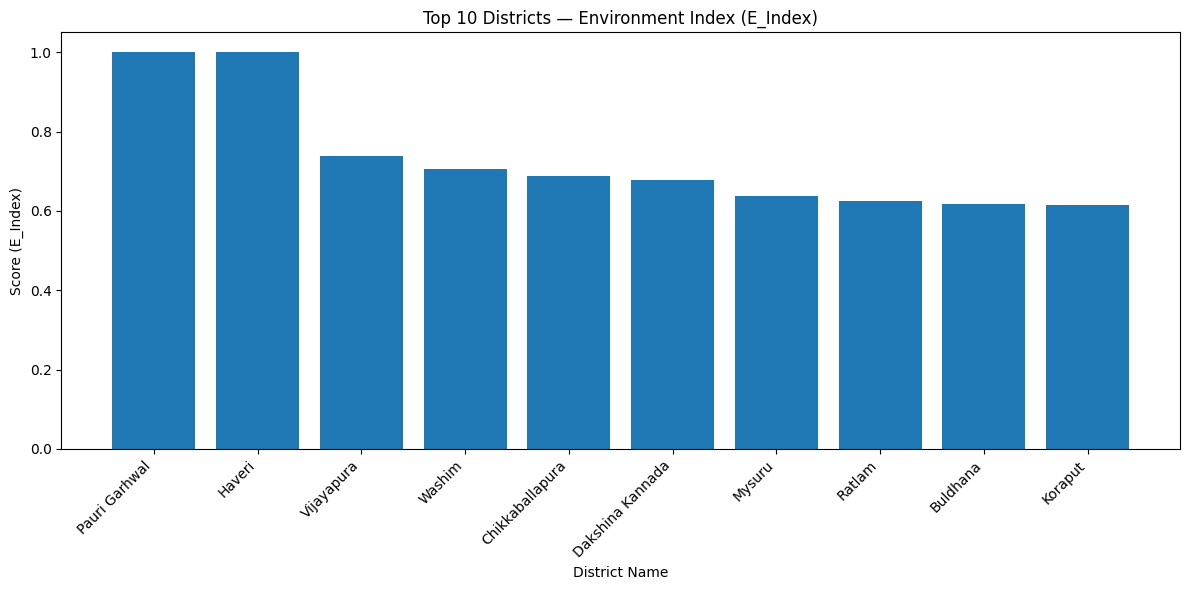

✅ Saved chart as: Top_10_Districts_Environment_Index_E_Index.png

TOP 10 DISTRICTS — Education Index (Edu_Index)


,Rank,District Name,Score (Edu_Index)
776,1,Palakkad,1.000000
1068,2,Thrissur,0.983942
187,3,Chandigarh,0.971020
504,4,Kasaragod,0.967374
1062,5,Thiruvananthapuram,0.956050
569,6,Kottayam,0.955698
1167,7,Yanam,0.954352
409,8,Jagatsinghpur,0.945147
275,9,Dhenkanal,0.944161
271,10,Dharmapuri,0.940133


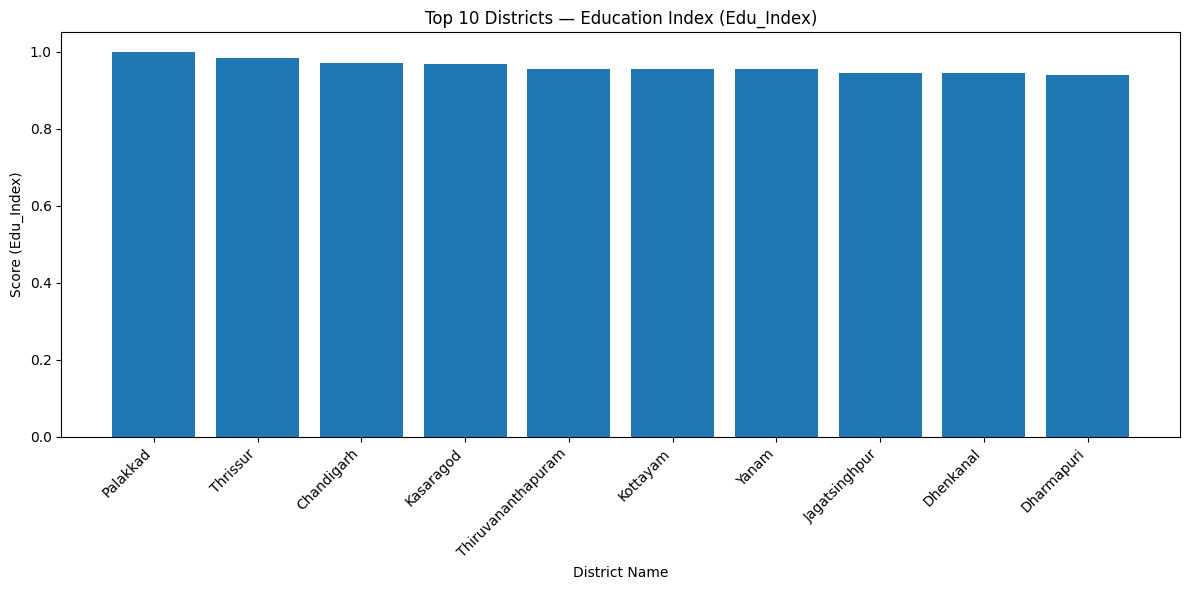

✅ Saved chart as: Top_10_Districts_Education_Index_Edu_Index.png

TOP 10 DISTRICTS — Livelihood Index (L_Index)


,Rank,District Name,Score (L_Index)
300,1,East Garo Hills,1.000000
553,2,Kolasib,0.888629
643,3,Mamit,0.865128
184,4,Champhai,0.863991
940,5,Serchhip,0.810042
488,6,Kanniyakumari,0.770505
965,7,Siaha,0.764185
313,8,Erode,0.717746
312,9,Ernakulam,0.691533
355,10,Gomati,0.661386


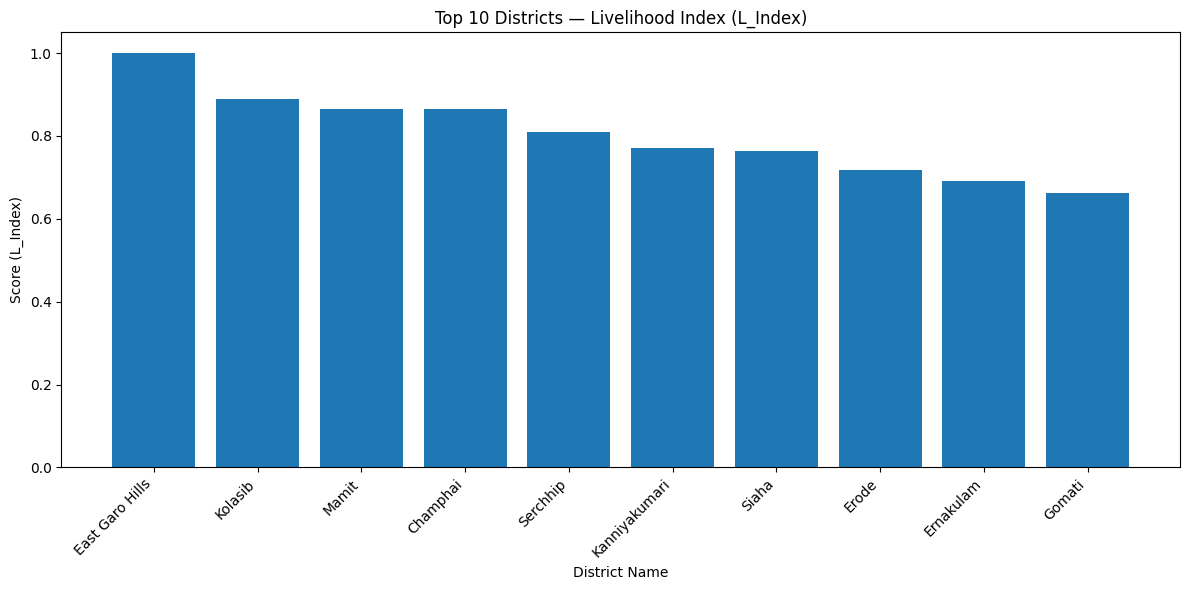

✅ Saved chart as: Top_10_Districts_Livelihood_Index_L_Index.png

TOP 10 DISTRICTS — MSME Strength Index (MSME_Index)


,Rank,District Name,Score (MSME_Index)
1041,1,Surat,1.000000
832,2,Pune,0.633614
4,3,Ahmadabad,0.628224
1056,4,Thane,0.609981
690,5,Mumbai Suburban,0.594958
195,6,Chennai,0.594769
413,7,Jaipur,0.593726
685,8,Mumbai,0.447941
124,9,Bengaluru (Urban),0.434436
224,10,Coimbatore,0.388459


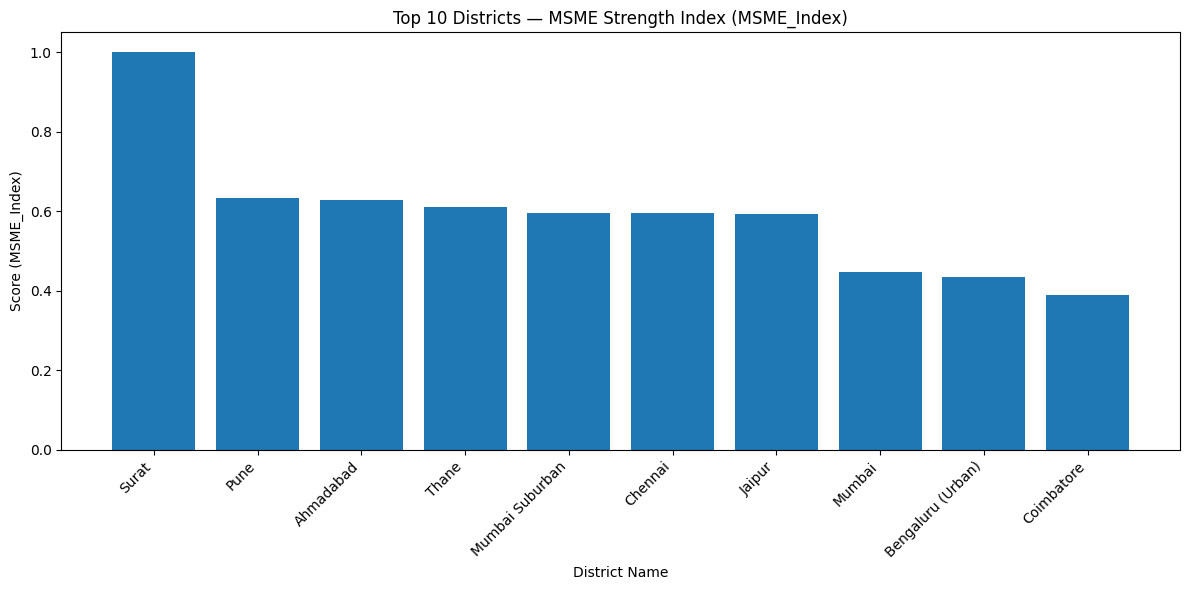

✅ Saved chart as: Top_10_Districts_MSME_Strength_Index_MSME_Index.png

TOP 10 DISTRICTS — Health Resilience Index (H_Index)


,Rank,District Name,Score (H_Index)
489,1,Kannur,1.000000
642,2,Mallapuram,0.986052
776,3,Palakkad,0.982800
505,4,Kasargod,0.980234
312,5,Ernakulam,0.978608
1068,6,Thrissur,0.966998
569,7,Kottayam,0.947918
878,8,Ratnagiri,0.946292
402,9,Idukki,0.941414
1139,10,Wayanad,0.937935


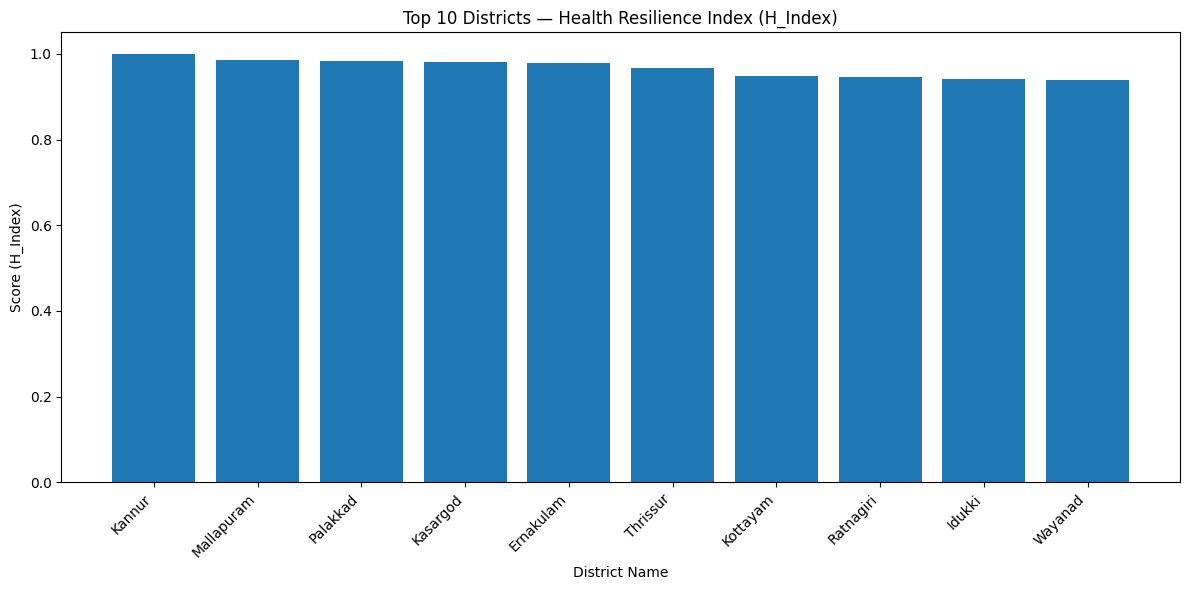

✅ Saved chart as: Top_10_Districts_Health_Resilience_Index_H_Index.png

TOP 10 DISTRICTS — Socio-economic Vulnerability Index (V_Index)


,Rank,District Name,Score (V_Index)
940,1,Serchhip,1.000000
547,2,Kodagu,0.984524
1059,3,The Nilgiris,0.978860
1046,4,Tamenglong,0.970411
240,5,Dakshina Kannada,0.967242
8,6,Aizawl,0.966560
712,7,Namakkal,0.955173
1077,8,Tiruppur,0.938945
1051,9,Tawang,0.932846
313,10,Erode,0.929657


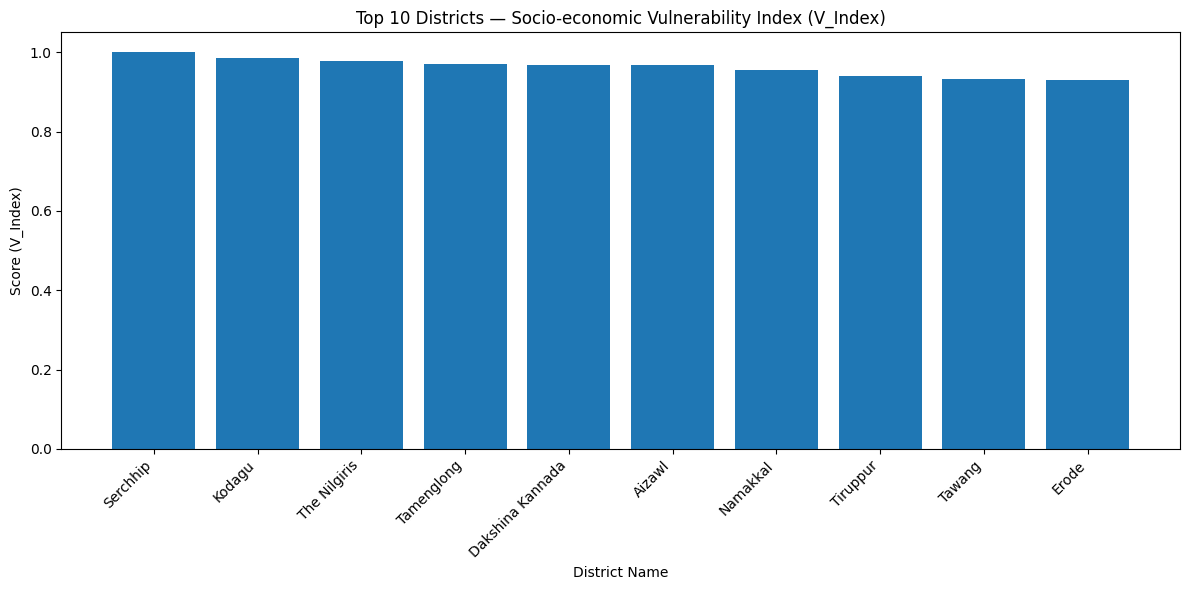

✅ Saved chart as: Top_10_Districts_Socio-economic_Vulnerability_Index_V_Index.png

TOP 10 DISTRICTS — Governance Quality Index (G_Index)


,Rank,District Name,Score (G_Index)
557,1,Kollam,1.000000
1062,2,Thiruvananthapuram,0.987030
187,3,Chandigarh,0.982871
1068,4,Thrissur,0.964491
312,5,Ernakulam,0.961610
1024,6,Sri Muktsar Sahib,0.960453
569,7,Kottayam,0.933669
106,8,Barnala,0.916944
810,9,Perambalur,0.908672
637,10,Malappuram,0.906965


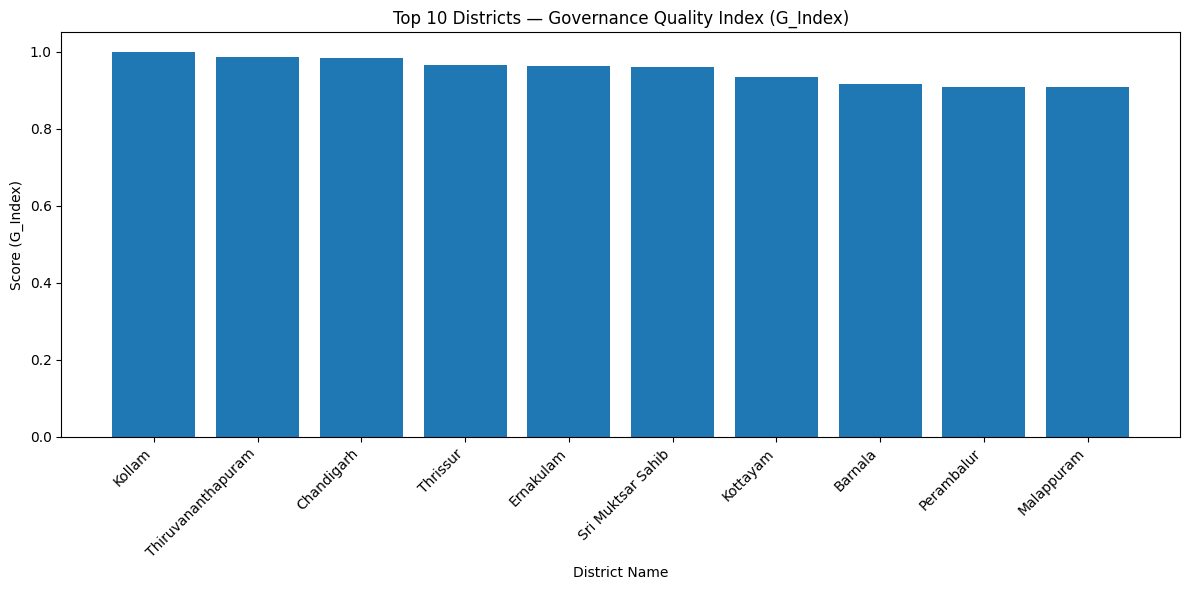

✅ Saved chart as: Top_10_Districts_Governance_Quality_Index_G_Index.png


In [ ]:


# ============================================================
# SETTINGS: 7 indices mapping
# ============================================================

indices_map = {
    "Environment Index (E_Index)": "E_Index_norm",
    "Education Index (Edu_Index)": "Edu_Index_norm",
    "Livelihood Index (L_Index)": "L_Index_norm",
    "MSME Strength Index (MSME_Index)": "MSME_Index_norm",
    "Health Resilience Index (H_Index)": "H_Index_norm",
    "Socio-economic Vulnerability Index (V_Index)": "V_Index_norm",
    "Governance Quality Index (G_Index)": "G_Index_norm"
}

TOP_N = 10

# ============================================================
# FUNCTION: Top 10 table + graph for one index
# ============================================================

def top10_table_and_graph(df, index_title, index_col, top_n=10):
    """
    Prints a table and plots Top N districts for a given index column.
    Also saves the plot as a PPT-ready PNG.
    """
    # Clean base data
    temp = df[['district_name', index_col]].copy()
    temp = temp.dropna(subset=['district_name', index_col])

    # If duplicates exist, take mean value
    temp = (
        temp.groupby('district_name', as_index=False)[index_col]
        .mean()
    )

    # Top 10
    top_df = temp.sort_values(index_col, ascending=False).head(top_n).copy()

    # Ranking
    top_df.insert(0, "Rank", range(1, len(top_df) + 1))
    top_df = top_df.rename(columns={
        "district_name": "District Name",
        index_col: f"Score ({index_title.split('(')[-1].replace(')', '')})"  # puts index name in parenthesis
    })

    # ---------------------------
    # TABLE OUTPUT
    # ---------------------------
    print("\n" + "="*90)
    print(f"TOP {top_n} DISTRICTS — {index_title}")
    print("="*90)

    try:
        display(top_df)
    except NameError:
        print(top_df.to_string(index=False))

    # ---------------------------
    # GRAPH OUTPUT
    # ---------------------------
    plot_df = top_df.copy()

    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["District Name"], plot_df.iloc[:, 2])  # score col
    plt.title(f"Top {top_n} Districts — {index_title}")
    plt.xlabel("District Name")
    plt.ylabel(f"Score ({index_title.split('(')[-1].replace(')', '')})")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Save chart
    safe_name = index_title.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
    file_name = f"Top_{top_n}_Districts_{safe_name}.png"
    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["District Name"], plot_df.iloc[:, 2])
    plt.title(f"Top {top_n} Districts — {index_title}")
    plt.xlabel("District Name")
    plt.ylabel(f"Score ({index_title.split('(')[-1].replace(')', '')})")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"✅ Saved chart as: {file_name}")


# ============================================================
# RUN FOR ALL 7 INDICES
# ============================================================

for idx_title, idx_col in indices_map.items():
    if idx_col not in master_df.columns:
        print(f"⚠️ Skipping '{idx_title}' — column '{idx_col}' not found in master_df.")
        continue

    top10_table_and_graph(master_df, idx_title, idx_col, top_n=TOP_N)


# ***Bottom 10 Districts for each of the 7 Indices***


BOTTOM 10 DISTRICTS — Environment Index (E_Index)


,Rank (Bottom),District Name,Score (E_Index)
136,1,Bhandara,0.214035
1135,2,Warangal Rural,0.213577
741,3,Nirmal,0.212497
329,4,Gadchiroli,0.208219
135,5,Bhagalpur,0.197296
172,6,Buxar,0.194451
731,7,Nayagarh,0.188961
706,8,Nagaur,0.187047
806,9,Patna,0.144746
461,10,Kachchh,0.000000


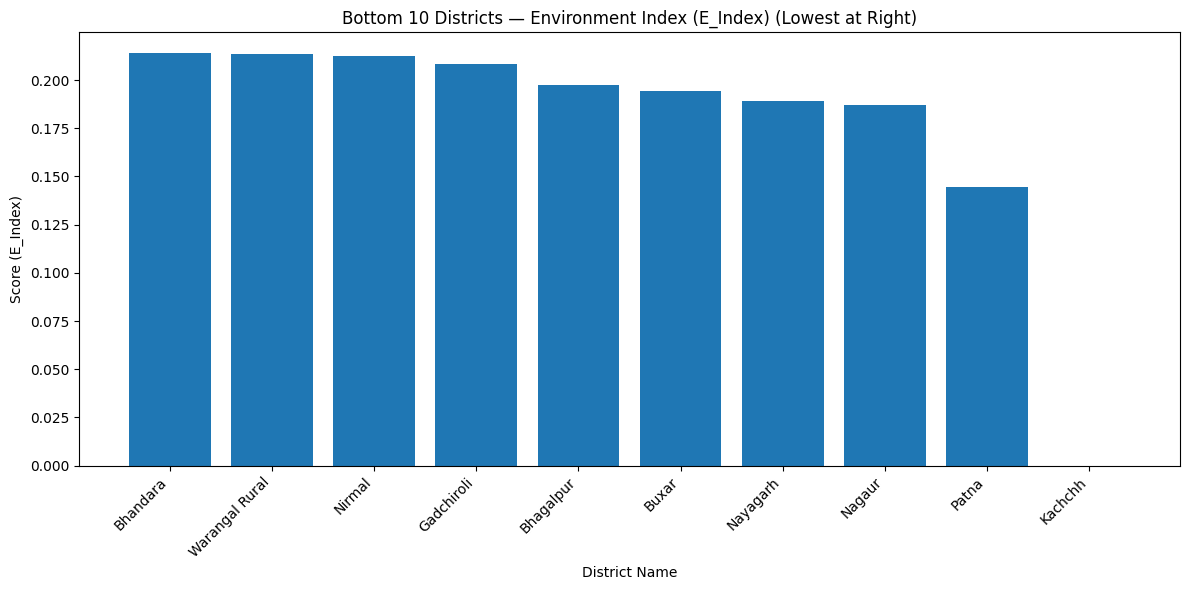

✅ Saved chart as: Bottom_10_Districts_Environment_Index_E_Index.png

BOTTOM 10 DISTRICTS — Education Index (Edu_Index)


,Rank (Bottom),District Name,Score (Edu_Index)
46,1,Araria,0.129317
57,2,Aurangabad (Bihar),0.126661
896,3,Saharsa,0.126059
619,4,Madhepura,0.125883
620,5,Madhubani,0.113888
926,6,Saran,0.100399
463,7,Kaimur (Bhabua),0.092242
983,8,Sitamarhi,0.073372
359,9,Gopalganj,0.016087
834,10,Purba Champaran,0.000000


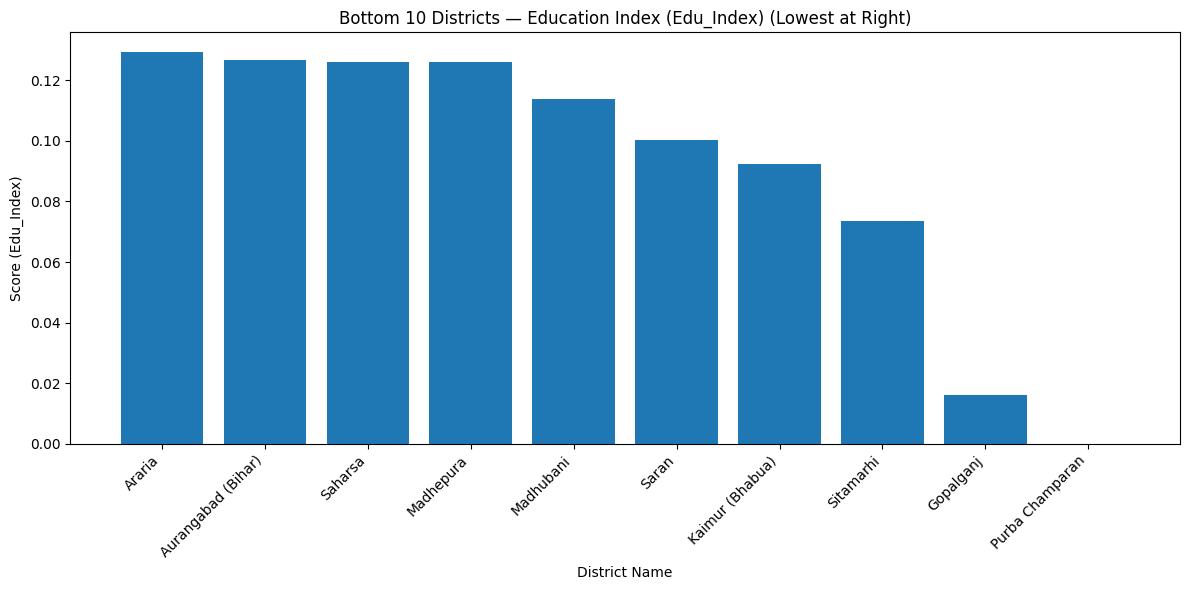

✅ Saved chart as: Bottom_10_Districts_Education_Index_Edu_Index.png

BOTTOM 10 DISTRICTS — Livelihood Index (L_Index)


,Rank (Bottom),District Name,Score (L_Index)
756,1,North Garo Hills,0.080184
820,2,Poonch,0.074318
611,3,Lower Siang,0.073724
1093,4,Udhampur,0.070725
715,5,Namsai,0.070399
404,6,Imphal West,0.064019
999,7,South Andaman,0.044490
348,8,Ghaziabad,0.044120
868,9,Ramban,0.030560
1102,10,Upper Siang,0.023739


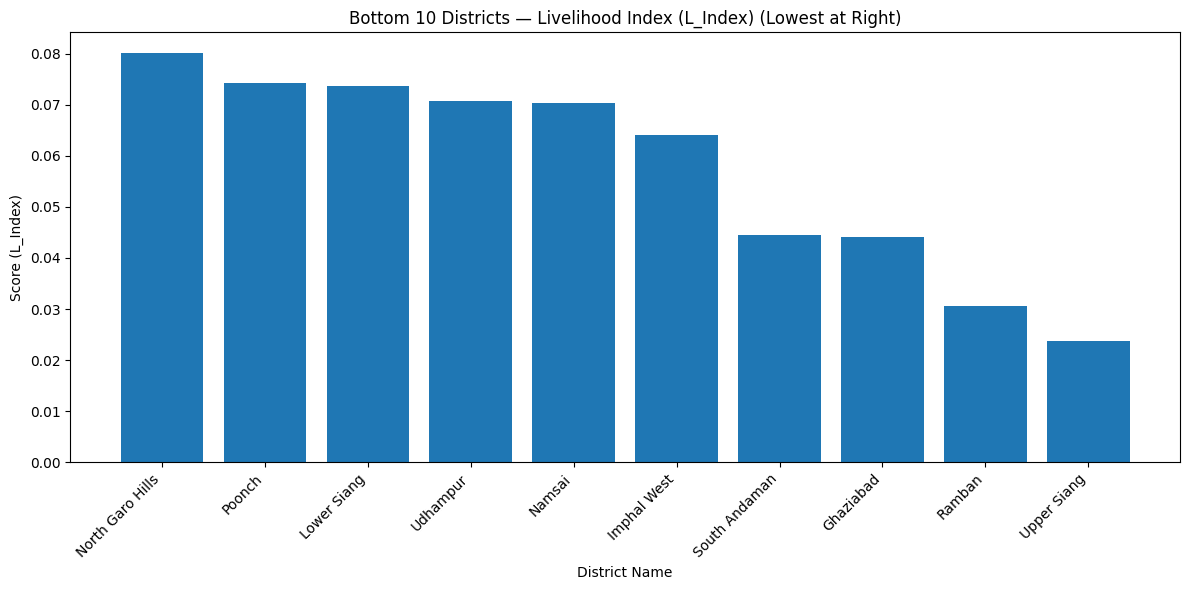

✅ Saved chart as: Bottom_10_Districts_Livelihood_Index_L_Index.png

BOTTOM 10 DISTRICTS — MSME Strength Index (MSME_Index)


,Rank (Bottom),District Name,Score (MSME_Index)
303,1,East Kameng,0.061029
1103,2,Upper Subansiri,0.059709
676,3,Mon,0.054939
86,4,Bandipora,0.054472
584,5,Kurung Kumey,0.053026
605,6,Lohit,0.052691
540,7,Kiphrie,0.049302
553,8,Kolasib,0.044315
1102,9,Upper Siang,0.040688
1171,10,Zunheboto,0.000000


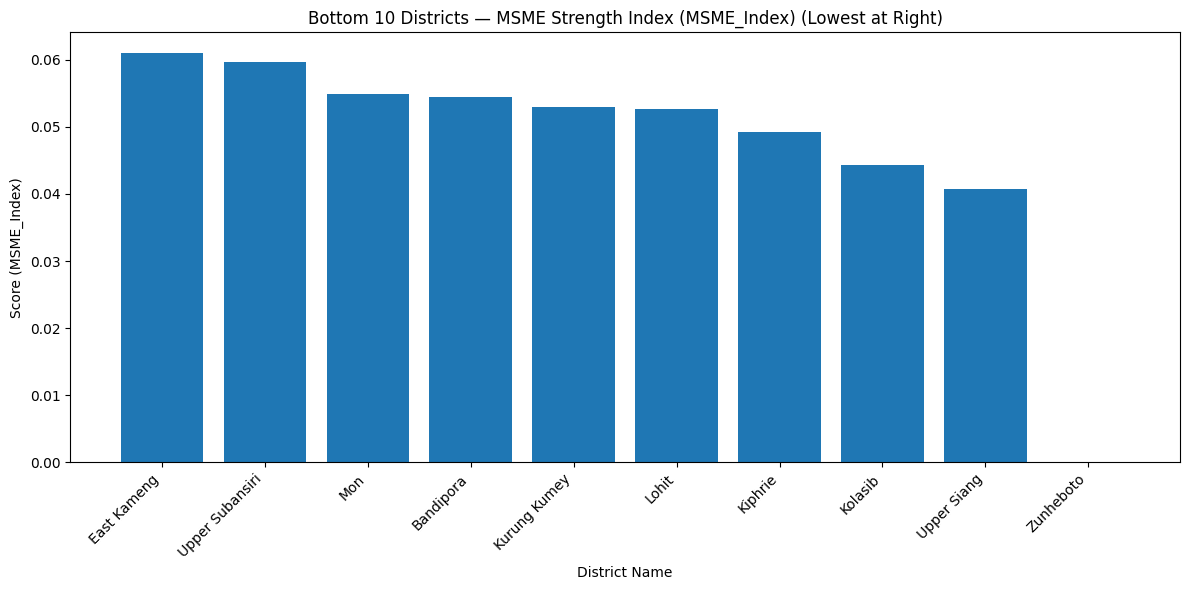

✅ Saved chart as: Bottom_10_Districts_MSME_Strength_Index_MSME_Index.png

BOTTOM 10 DISTRICTS — Health Resilience Index (H_Index)


,Rank (Bottom),District Name,Score (H_Index)
510,1,Katni,0.252414
978,2,Singrauli,0.226376
279,3,Dibang Valley,0.221956
1145,4,West Garo Hills,0.219644
378,5,Hanumangarh,0.159000
48,6,Ariyalur,0.107908
41,7,Anjaw,0.091352
499,8,Kargil,0.061606
582,9,Kurug Kumey,0.032316
303,10,East Kameng,0.000000


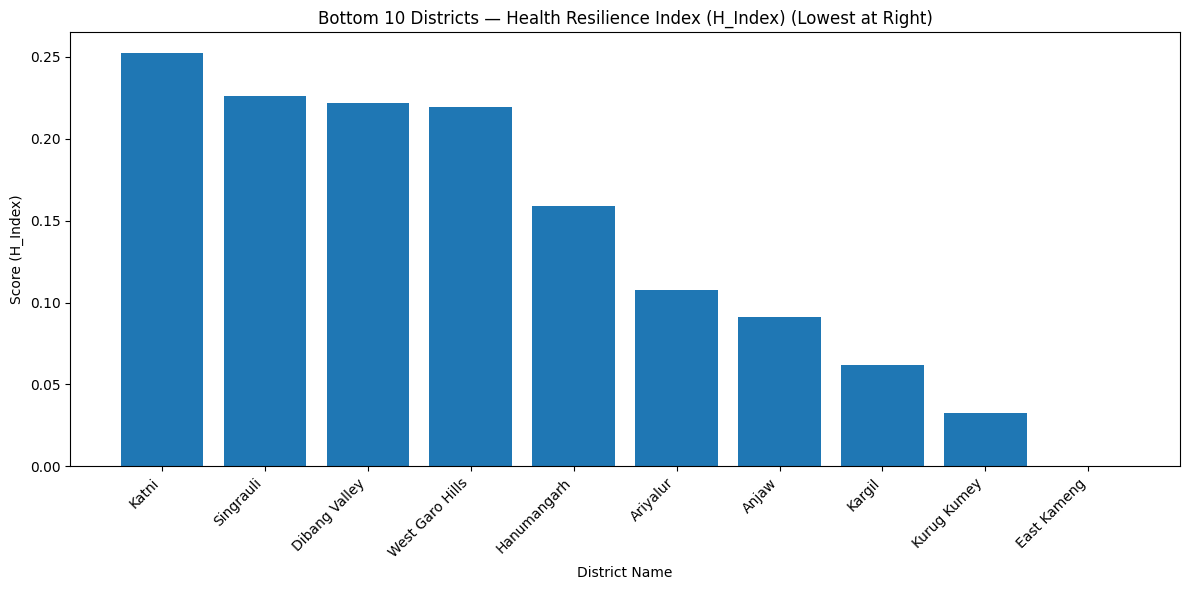

✅ Saved chart as: Bottom_10_Districts_Health_Resilience_Index_H_Index.png

BOTTOM 10 DISTRICTS — Socio-economic Vulnerability Index (V_Index)


,Rank (Bottom),District Name,Score (V_Index)
831,1,Punch,0.074154
260,2,Deoria,0.065599
576,3,Kulgam,0.060788
586,4,Kushinagar,0.054510
830,5,Pulwama,0.044257
37,6,Anantnag,0.022391
359,7,Gopalganj,0.022216
988,8,Siwan,0.008918
926,9,Saran,0.007724
580,10,Kupwara,0.000000


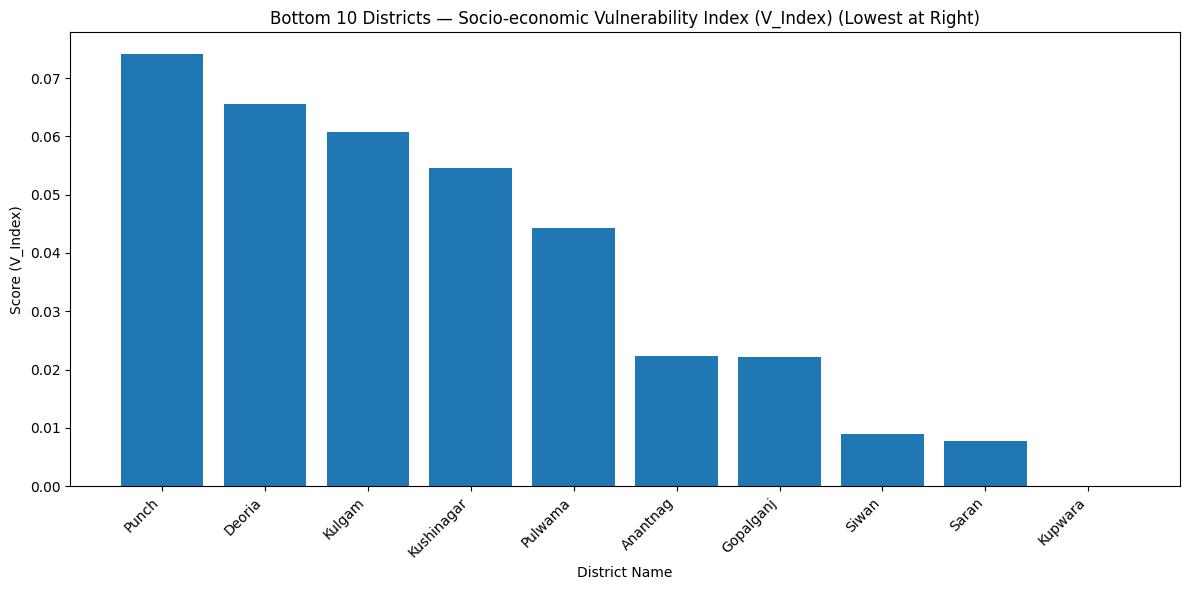

✅ Saved chart as: Bottom_10_Districts_Socio-economic_Vulnerability_Index_V_Index.png

BOTTOM 10 DISTRICTS — Governance Quality Index (G_Index)


,Rank (Bottom),District Name,Score (G_Index)
1147,1,West Jaintia Hills,0.043900
1151,2,West Khasi Hills,0.043634
46,3,Araria,0.036922
57,4,Aurangabad (Bihar),0.035011
773,5,Pakke Kessang,0.034041
756,6,North Garo Hills,0.030589
1019,7,South West Khasi Hills,0.029195
1018,8,South West Garo Hills,0.024449
607,9,Longding,0.018366
475,10,Kamle,0.000000


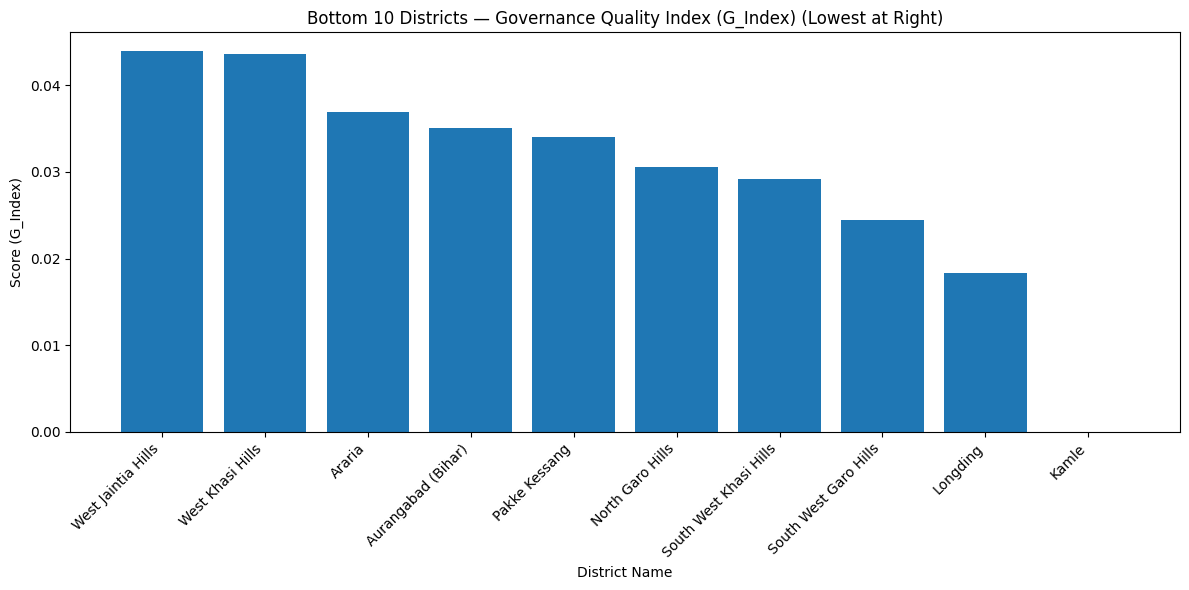

✅ Saved chart as: Bottom_10_Districts_Governance_Quality_Index_G_Index.png


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS: 7 indices mapping
# ============================================================

indices_map = {
    "Environment Index (E_Index)": "E_Index_norm",
    "Education Index (Edu_Index)": "Edu_Index_norm",
    "Livelihood Index (L_Index)": "L_Index_norm",
    "MSME Strength Index (MSME_Index)": "MSME_Index_norm",
    "Health Resilience Index (H_Index)": "H_Index_norm",
    "Socio-economic Vulnerability Index (V_Index)": "V_Index_norm",
    "Governance Quality Index (G_Index)": "G_Index_norm"
}

BOTTOM_N = 10

# ============================================================
# FUNCTION: Bottom 10 table + graph for one index
# ============================================================

def bottom10_table_and_graph(df, index_title, index_col, bottom_n=10):
    """
    Prints a table and plots Bottom N districts for a given index column.
    Graph order: highest among bottom N -> lowest, so lowest appears RIGHTMOST.
    Also saves the plot as a PPT-ready PNG.
    """

    # Clean base data
    temp = df[['district_name', index_col]].copy()
    temp = temp.dropna(subset=['district_name', index_col])

    # If duplicates exist, take mean value
    temp = temp.groupby('district_name', as_index=False)[index_col].mean()

    # Get bottom N (lowest)
    bottom_df = temp.sort_values(index_col, ascending=True).head(bottom_n).copy()

    # ✅ Re-sort for plotting (so lowest is rightmost)
    bottom_df = bottom_df.sort_values(index_col, ascending=False).copy()

    # Ranking inside bottom N
    bottom_df.insert(0, "Rank (Bottom)", range(1, len(bottom_df) + 1))

    # Rename columns
    short_index_name = index_title.split('(')[-1].replace(')', '')  # E_Index etc.
    bottom_df = bottom_df.rename(columns={
        "district_name": "District Name",
        index_col: f"Score ({short_index_name})"
    })

    # ---------------------------
    # TABLE OUTPUT
    # ---------------------------
    print("\n" + "="*100)
    print(f"BOTTOM {bottom_n} DISTRICTS — {index_title}")
    print("="*100)

    try:
        display(bottom_df)
    except NameError:
        print(bottom_df.to_string(index=False))

    # ---------------------------
    # GRAPH OUTPUT
    # ---------------------------
    plt.figure(figsize=(12, 6))
    plt.bar(bottom_df["District Name"], bottom_df[f"Score ({short_index_name})"])
    plt.title(f"Bottom {bottom_n} Districts — {index_title} (Lowest at Right)")
    plt.xlabel("District Name")
    plt.ylabel(f"Score ({short_index_name})")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    # Save chart (PPT-ready)
    safe_name = index_title.replace(" ", "_").replace("(", "").replace(")", "").replace("/", "_")
    file_name = f"Bottom_{bottom_n}_Districts_{safe_name}.png"

    plt.figure(figsize=(12, 6))
    plt.bar(bottom_df["District Name"], bottom_df[f"Score ({short_index_name})"])
    plt.title(f"Bottom {bottom_n} Districts — {index_title} (Lowest at Right)")
    plt.xlabel("District Name")
    plt.ylabel(f"Score ({short_index_name})")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(file_name, dpi=300, bbox_inches="tight")
    plt.close()

    print(f"✅ Saved chart as: {file_name}")


# ============================================================
# RUN FOR ALL 7 INDICES
# ============================================================

for idx_title, idx_col in indices_map.items():
    if idx_col not in master_df.columns:
        print(f"⚠️ Skipping '{idx_title}' — column '{idx_col}' not found in master_df.")
        continue

    bottom10_table_and_graph(master_df, idx_title, idx_col, bottom_n=BOTTOM_N)


In [ ]:
# =====================================================
# 1) STATE NAME CLEANING (fix duplicates)
# =====================================================
def clean_state(s):
    s = str(s).strip().lower()
    s = s.replace("\n", " ")
    s = " ".join(s.split())

    # standardize common variants
    mapping = {
        # Gujarat
        "gujrat": "gujarat",

        # Delhi
        "nct of delhi": "delhi",
        "nct delhi": "delhi",

        # Andaman & Nicobar (your requested correction)
        "andaman & nicobar island": "andaman & nicobar islands",
        "andaman & nicobar islands": "andaman & nicobar islands",
        "andaman and nicobar": "andaman & nicobar islands",
        "andaman and nicobar islands": "andaman & nicobar islands",

        # Dadra & Nagar Haveli/Daman & Diu variants (optional but useful)
        "d & n haveli": "dadra & nagar haveli",
        "dadra & nagar haveli": "dadra & nagar haveli",
        "daman and diu": "daman & diu",
        "daman & diu": "daman & diu",
        "dn haveli and dd": "dadra & nagar haveli and daman & diu",
        "dadra & nagar haveli and daman & diu": "dadra & nagar haveli and daman & diu"
    }

    s = mapping.get(s, s)
    return s.title()

master_df['State_Clean'] = master_df['State Name'].apply(clean_state)

print("✅ Unique States before cleaning:", master_df['State Name'].nunique())
print("✅ Unique States after cleaning :", master_df['State_Clean'].nunique())




✅ Unique States before cleaning: 51
✅ Unique States after cleaning : 43


In [ ]:
# =====================================================
# 2) STATE-WISE COUNT OF DISTRICTS IN EACH CLUSTER
# =====================================================

# Use standardized cluster column (prefer Cluster_Std)
cluster_col = 'Cluster_Std' if 'Cluster_Std' in master_df.columns else 'Cluster_Name'

# Base df (unique district per state)
df_sc = (
    master_df[['State_Clean', 'district_name', cluster_col]]
    .dropna(subset=['State_Clean', 'district_name', cluster_col])
    .drop_duplicates(subset=['State_Clean', 'district_name'])
    .copy()
)

cluster_order = [
    "Resilience Leaders",
    "Emerging Opportunity Districts",
    "Vulnerability Hotspots"
]

# Pivot counts
state_cluster_counts = pd.pivot_table(
    df_sc,
    index='State_Clean',
    columns=cluster_col,
    values='district_name',
    aggfunc='nunique',
    fill_value=0
)

# Ensure all clusters exist
state_cluster_counts = state_cluster_counts.reindex(columns=cluster_order, fill_value=0)

# Add totals
state_cluster_counts["Total Districts"] = state_cluster_counts.sum(axis=1)

# Final table
state_cluster_counts_table = (
    state_cluster_counts
    .reset_index()
    .rename(columns={"State_Clean": "State Name"})
    .sort_values("Total Districts", ascending=False)
)

print("\n✅ STATE-WISE COUNT OF DISTRICTS IN EACH CLUSTER")
try:
    display(state_cluster_counts_table)
except NameError:
    print(state_cluster_counts_table.to_string(index=False))





✅ STATE-WISE COUNT OF DISTRICTS IN EACH CLUSTER


Cluster_Std,State Name,Resilience Leaders,Emerging Opportunity Districts,Vulnerability Hotspots,Total Districts
40,Uttar Pradesh,0,36,73,109
18,Karnataka,17,51,1,69
22,Madhya Pradesh,1,36,28,65
32,Rajasthan,1,55,3,59
6,Chhattisgarh,0,55,4,59
1,Andhra Pradesh,0,57,0,57
23,Maharashtra,3,49,1,53
36,Telangana,0,44,7,51
34,Tamil Nadu,5,42,0,47
42,West Bengal,1,45,1,47


<Figure size 1400x700 with 0 Axes>

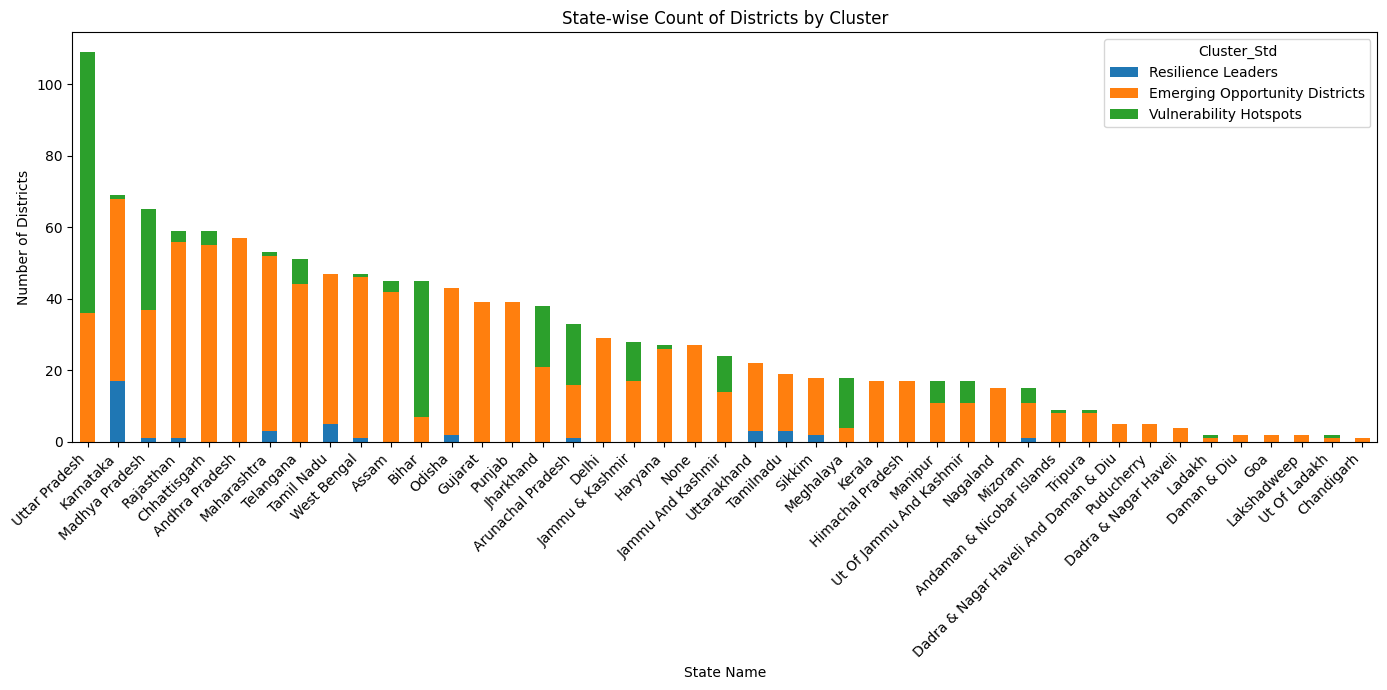

In [ ]:
# =====================================================
# 3) OPTIONAL: STACKED BAR GRAPH (PPT-friendly)
# =====================================================
plot_df = state_cluster_counts_table.set_index("State Name")[cluster_order]

plt.figure(figsize=(14, 7))
plot_df.plot(kind="bar", stacked=True, figsize=(14, 7))

plt.title("State-wise Count of Districts by Cluster")
plt.xlabel("State Name")
plt.ylabel("Number of Districts")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# =====================================================
# 1) Clean State Names (includes Andaman correction)
# =====================================================
def clean_state(s):
    s = str(s).strip().lower()
    s = s.replace("\n", " ")
    s = " ".join(s.split())

    mapping = {
        "gujrat": "gujarat",
        "nct of delhi": "delhi",

        # ✅ Andaman & Nicobar merge
        "andaman & nicobar island": "andaman & nicobar islands",
        "andaman & nicobar islands": "andaman & nicobar islands",
        "andaman and nicobar": "andaman & nicobar islands",
        "andaman and nicobar islands": "andaman & nicobar islands",

        # optional
        "daman and diu": "daman & diu",
        "d & n haveli": "dadra & nagar haveli",
        "dn haveli and dd": "dadra & nagar haveli and daman & diu"
    }

    s = mapping.get(s, s)
    return s.title()

master_df['State_Clean'] = master_df['State Name'].apply(clean_state)

# Cluster column
cluster_col = "Cluster_Std" if "Cluster_Std" in master_df.columns else "Cluster_Name"

# Base df (unique districts)
df_sc = (
    master_df[['State_Clean', 'district_name', cluster_col]]
    .dropna(subset=['State_Clean', 'district_name', cluster_col])
    .drop_duplicates(subset=['State_Clean', 'district_name'])
    .copy()
)

# Cluster order
cluster_order = [
    "Resilience Leaders",
    "Emerging Opportunity Districts",
    "Vulnerability Hotspots"
]

# =====================================================
# 2) Function to create cluster table in your format
# =====================================================
def make_cluster_table(df, cluster_name):
    sub = df[df[cluster_col] == cluster_name].copy()

    # State-wise count within cluster
    state_counts = (
        sub.groupby('State_Clean')['district_name']
        .nunique()
        .sort_values(ascending=False)
    )

    cluster_total = state_counts.sum()

    out = pd.DataFrame({
        "States": state_counts.index,
        "Percentage of Districts in Cluster (%)": (state_counts / cluster_total * 100).round(2),
        "Total Districts in Cluster": cluster_total
    })

    return out

# =====================================================
# 3) Create 3 tables
# =====================================================
leaders_tbl = make_cluster_table(df_sc, "Resilience Leaders")
emerging_tbl = make_cluster_table(df_sc, "Emerging Opportunity Districts")
hotspots_tbl = make_cluster_table(df_sc, "Vulnerability Hotspots")

# =====================================================
# 4) Display Tables
# =====================================================
print("\n✅ RESILIENCE LEADERS — Cluster Table")
try:
    display(leaders_tbl)
except NameError:
    print(leaders_tbl.to_string(index=False))

print("\n✅ EMERGING OPPORTUNITY DISTRICTS — Cluster Table")
try:
    display(emerging_tbl)
except NameError:
    print(emerging_tbl.to_string(index=False))

print("\n✅ VULNERABILITY HOTSPOTS — Cluster Table")
try:
    display(hotspots_tbl)
except NameError:
    print(hotspots_tbl.to_string(index=False))





✅ RESILIENCE LEADERS — Cluster Table


,States,Percentage of Districts in Cluster (%),Total Districts in Cluster
State_Clean,,,
Karnataka,Karnataka,42.5,40
Tamil Nadu,Tamil Nadu,12.5,40
Tamilnadu,Tamilnadu,7.5,40
Maharashtra,Maharashtra,7.5,40
Uttarakhand,Uttarakhand,7.5,40
Odisha,Odisha,5.0,40
Sikkim,Sikkim,5.0,40
Arunachal Pradesh,Arunachal Pradesh,2.5,40
Madhya Pradesh,Madhya Pradesh,2.5,40



✅ EMERGING OPPORTUNITY DISTRICTS — Cluster Table


,States,Percentage of Districts in Cluster (%),Total Districts in Cluster
State_Clean,,,
Andhra Pradesh,Andhra Pradesh,5.93,962
Chhattisgarh,Chhattisgarh,5.72,962
Rajasthan,Rajasthan,5.72,962
Karnataka,Karnataka,5.30,962
Maharashtra,Maharashtra,5.09,962
West Bengal,West Bengal,4.68,962
Telangana,Telangana,4.57,962
Tamil Nadu,Tamil Nadu,4.37,962
Assam,Assam,4.37,962



✅ VULNERABILITY HOTSPOTS — Cluster Table


,States,Percentage of Districts in Cluster (%),Total Districts in Cluster
State_Clean,,,
Uttar Pradesh,Uttar Pradesh,29.32,249
Bihar,Bihar,15.26,249
Madhya Pradesh,Madhya Pradesh,11.24,249
Arunachal Pradesh,Arunachal Pradesh,6.83,249
Jharkhand,Jharkhand,6.83,249
Meghalaya,Meghalaya,5.62,249
Jammu & Kashmir,Jammu & Kashmir,4.42,249
Jammu And Kashmir,Jammu And Kashmir,4.02,249
Telangana,Telangana,2.81,249


In [ ]:
# --- Clean state names (same as before) ---
def clean_state(s):
    s = str(s).strip().lower().replace("\n", " ")
    s = " ".join(s.split())

    mapping = {
        "andaman & nicobar island": "andaman & nicobar islands",
        "andaman & nicobar islands": "andaman & nicobar islands",
        "andaman and nicobar": "andaman & nicobar islands",
        "andaman and nicobar islands": "andaman & nicobar islands",
        "gujrat": "gujarat",
        "nct of delhi": "delhi",
    }
    return mapping.get(s, s).title()

master_df["State_Clean"] = master_df["State Name"].apply(clean_state)

cluster_col = "Cluster_Std" if "Cluster_Std" in master_df.columns else "Cluster_Name"

# ✅ use (State + District) as unique district identifier
cluster_district_counts_correct = (
    master_df[["State_Clean", "district_name", cluster_col]]
    .dropna(subset=["State_Clean", "district_name", cluster_col])
    .drop_duplicates(subset=["State_Clean", "district_name"])   # ✅ correct uniqueness
    .groupby(cluster_col)["district_name"]
    .nunique()
    .reset_index(name="Total Districts")
    .sort_values("Total Districts", ascending=False)
)

print("✅ Correct cluster-wise district totals (State+District unique):")
try:
    display(cluster_district_counts_correct)
except NameError:
    print(cluster_district_counts_correct.to_string(index=False))

✅ Correct cluster-wise district totals (State+District unique):


,Cluster_Std,Total Districts
0,Emerging Opportunity Districts,906
2,Vulnerability Hotspots,229
1,Resilience Leaders,37


In [ ]:
import os
from google.colab import files

final_files = [
    # ✅ Benchmark files (corrected)
    "DSRI_Benchmark_Districts.xlsx",
    "DSRI_Benchmark_States.xlsx",

    # ✅ District cluster files
    "8_District_Clusters_AllRanks.xlsx",
    "9_District_Clusters_WithinClusterRank.xlsx",
    "10_District_Clusters_FullProfile.xlsx",

    # ✅ State cluster files
    "11_State_Clusters_AllRanks.xlsx",
    "12_State_Clusters_WithinClusterRank.xlsx",
    "13_State_Clusters_FullProfile.xlsx",

    # ✅ State-wise cluster distribution (corrected)
    "Statewise_District_Cluster_Counts.xlsx",
    "Statewise_Cluster_Percentage_Distribution_FINAL.xlsx",

    # ✅ Cluster-wise state contribution tables (corrected)
    "Clusterwise_State_Share_3Tables.xlsx",
    "State_Cluster_Contribution_Percent_Table.xlsx",
    "Clusterwise_State_Contribution_Share.xlsx",
    "Clusterwise_State_Contribution_Percent.xlsx",

    # ✅ Extra corrected exports (keep if generated)
    "Statewise_Cluster_Distribution.xlsx",
    "Statewise_Cluster_Percentage_Distribution_FIXED.xlsx"
]

# --- Download ---
missing = []
for f in final_files:
    if os.path.exists(f):
        files.download(f)
    else:
        missing.append(f)

print("\n✅ Download attempt completed.")
if missing:
    print("⚠️ These files were NOT found in your current runtime folder (not generated yet):")
    for m in missing:
        print(" -", m)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download attempt completed.
⚠️ These files were NOT found in your current runtime folder (not generated yet):
 - Statewise_District_Cluster_Counts.xlsx
 - Statewise_Cluster_Percentage_Distribution_FINAL.xlsx
 - Clusterwise_State_Share_3Tables.xlsx
 - State_Cluster_Contribution_Percent_Table.xlsx
 - Clusterwise_State_Contribution_Share.xlsx
 - Clusterwise_State_Contribution_Percent.xlsx
 - Statewise_Cluster_Distribution.xlsx
 - Statewise_Cluster_Percentage_Distribution_FIXED.xlsx


In [ ]:
import pandas as pd

# =====================================================
# 1) Clean State Names (CORRECTED)
# =====================================================
def clean_state(s):
    s = str(s).strip().lower()
    s = s.replace("\n", " ")
    s = " ".join(s.split())

    mapping = {
        "gujrat": "gujarat",
        "nct of delhi": "delhi",

        # ✅ Andaman merge
        "andaman & nicobar island": "andaman & nicobar islands",
        "andaman & nicobar islands": "andaman & nicobar islands",
        "andaman and nicobar": "andaman & nicobar islands",
        "andaman and nicobar islands": "andaman & nicobar islands",

        # helpful merges
        "daman and diu": "daman & diu",
        "d & n haveli": "dadra & nagar haveli",
        "dn haveli and dd": "dadra & nagar haveli and daman & diu",
        "dadra & nagar haveli and daman & diu": "dadra & nagar haveli and daman & diu"
    }

    s = mapping.get(s, s)
    return s.title()

master_df["State_Clean"] = master_df["State Name"].apply(clean_state)

# cluster column
cluster_col = "Cluster_Std" if "Cluster_Std" in master_df.columns else "Cluster_Name"

# base df: unique district per state
df_sc = (
    master_df[["State_Clean", "district_name", cluster_col]]
    .dropna(subset=["State_Clean", "district_name", cluster_col])
    .drop_duplicates(subset=["State_Clean", "district_name"])
    .copy()
)

cluster_order = [
    "Resilience Leaders",
    "Emerging Opportunity Districts",
    "Vulnerability Hotspots"
]

# =====================================================
# 2) State-wise cluster COUNTS
# =====================================================
state_cluster_counts = pd.pivot_table(
    df_sc,
    index="State_Clean",
    columns=cluster_col,
    values="district_name",
    aggfunc="nunique",
    fill_value=0
).reindex(columns=cluster_order, fill_value=0)

state_cluster_counts["Total Districts"] = state_cluster_counts.sum(axis=1)

state_cluster_counts_table = (
    state_cluster_counts.reset_index()
    .rename(columns={"State_Clean": "State Name"})
    .sort_values("Total Districts", ascending=False)
)

state_cluster_counts_table.to_excel("Statewise_District_Cluster_Counts.xlsx", index=False)

# =====================================================
# 3) State-wise cluster PERCENTAGES (state total = 100%)
# =====================================================
state_cluster_percent = (
    state_cluster_counts[cluster_order]
    .div(state_cluster_counts[cluster_order].sum(axis=1), axis=0) * 100
).round(2)

state_cluster_percent["Total Districts"] = state_cluster_counts["Total Districts"]

state_cluster_percent_table = (
    state_cluster_percent.reset_index()
    .rename(columns={"State_Clean": "State Name"})
)
state_cluster_percent_table = state_cluster_percent_table[["State Name", "Total Districts"] + cluster_order]

state_cluster_percent_table.to_excel("Statewise_Cluster_Percentage_Distribution_FINAL.xlsx", index=False)

# =====================================================
# 4) Cluster-wise state contribution tables (3 cluster tables)
# =====================================================
def make_cluster_table(df, cluster_name):
    sub = df[df[cluster_col] == cluster_name].copy()

    state_counts = (
        sub.groupby("State_Clean")["district_name"]
        .nunique()
        .sort_values(ascending=False)
    )

    cluster_total = state_counts.sum()

    out = pd.DataFrame({
        "States": state_counts.index,
        "Percentage of Districts in Cluster (%)": (state_counts / cluster_total * 100).round(2),
        "Total Districts in Cluster": cluster_total
    })
    return out

leaders_tbl  = make_cluster_table(df_sc, "Resilience Leaders")
emerging_tbl = make_cluster_table(df_sc, "Emerging Opportunity Districts")
hotspots_tbl = make_cluster_table(df_sc, "Vulnerability Hotspots")

with pd.ExcelWriter("Clusterwise_State_Share_3Tables.xlsx", engine="openpyxl") as writer:
    leaders_tbl.to_excel(writer, sheet_name="Leaders", index=False)
    emerging_tbl.to_excel(writer, sheet_name="Emerging", index=False)
    hotspots_tbl.to_excel(writer, sheet_name="Hotspots", index=False)

# =====================================================
# 5) Cluster-wise contribution % pivot (state rows, cluster columns)
# Cluster total = 100%
# =====================================================
cluster_totals = state_cluster_counts[cluster_order].sum(axis=0)

state_cluster_contrib_pct = (
    state_cluster_counts[cluster_order]
    .div(cluster_totals, axis=1) * 100
).round(2)

state_cluster_contrib_pct_table = (
    state_cluster_contrib_pct.reset_index()
    .rename(columns={"State_Clean": "State Name"})
)

state_cluster_contrib_pct_table.to_excel("State_Cluster_Contribution_Percent_Table.xlsx", index=False)

# =====================================================
# 6) Clusterwise_State_Contribution_Share.xlsx (long format)
# =====================================================
state_cluster_long = (
    df_sc.groupby([cluster_col, "State_Clean"])["district_name"]
    .nunique()
    .reset_index(name="District_Count")
)

state_cluster_long["Cluster_Total"] = state_cluster_long.groupby(cluster_col)["District_Count"].transform("sum")
state_cluster_long["State_Share_in_Cluster_%"] = (
    state_cluster_long["District_Count"] / state_cluster_long["Cluster_Total"] * 100
).round(2)

state_cluster_long = state_cluster_long.sort_values(
    [cluster_col, "State_Share_in_Cluster_%"], ascending=[True, False]
)

state_cluster_long.to_excel("Clusterwise_State_Contribution_Share.xlsx", index=False)

# =====================================================
# 7) Clusterwise_State_Contribution_Percent.xlsx (long + pivot)
# =====================================================
pivot_clusterwise = state_cluster_long.pivot_table(
    index="State_Clean",
    columns=cluster_col,
    values="State_Share_in_Cluster_%",
    fill_value=0
).reindex(columns=cluster_order, fill_value=0).reset_index().rename(columns={"State_Clean": "State Name"})

with pd.ExcelWriter("Clusterwise_State_Contribution_Percent.xlsx", engine="openpyxl") as writer:
    state_cluster_long.to_excel(writer, sheet_name="Long_Format", index=False)
    pivot_clusterwise.to_excel(writer, sheet_name="Pivot_Format", index=False)

# =====================================================
# 8) Statewise_Cluster_Distribution.xlsx (counts + percent, 2 sheets)
# =====================================================
with pd.ExcelWriter("Statewise_Cluster_Distribution.xlsx", engine="openpyxl") as writer:
    state_cluster_counts_table.to_excel(writer, sheet_name="Cluster_Counts", index=False)
    state_cluster_percent_table.to_excel(writer, sheet_name="Cluster_Share_Percent", index=False)

# =====================================================
# 9) Backup copy file (optional)
# =====================================================
state_cluster_percent_table.to_excel("Statewise_Cluster_Percentage_Distribution_FIXED.xlsx", index=False)

print("✅ Corrected files created successfully (no download yet).")


✅ Corrected files created successfully (no download yet).


In [ ]:
from google.colab import files
import os

files_to_download = [
    "Statewise_District_Cluster_Counts.xlsx",
    "Statewise_Cluster_Percentage_Distribution_FINAL.xlsx",
    "Clusterwise_State_Share_3Tables.xlsx",
    "State_Cluster_Contribution_Percent_Table.xlsx",
    "Clusterwise_State_Contribution_Share.xlsx",
    "Clusterwise_State_Contribution_Percent.xlsx",
    "Statewise_Cluster_Distribution.xlsx",
    "Statewise_Cluster_Percentage_Distribution_FIXED.xlsx"
]

missing = []
for f in files_to_download:
    if os.path.exists(f):
        files.download(f)
    else:
        missing.append(f)

print("\n✅ Download attempt completed.")
if missing:
    print("⚠️ These files are missing (not created yet):")
    for m in missing:
        print(" -", m)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download attempt completed.
